# 2026-06-08 FA 요인분석 - 매칭비발생

같은 기상셀·월·시간대의 매칭 비발생 대조군을 만들고, 산불 시점이 평상시보다 얼마나 위험 방향으로 이탈했는지를 FA 입력으로 준비한다.


# 데이터 준비

`jsw/강원_EDA/README.md`의 결합 방식을 따르되, 날씨 변수는 매칭 비발생 평균 대비 `위험방향_delta`로 변환한다.


## 0. 환경 설정

In [1]:
from pathlib import Path
import gc
import math
import time
import warnings

import geopandas as gpd
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from shapely import wkt
from shapely.strtree import STRtree

warnings.filterwarnings("ignore")

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print

    def Markdown(text):
        return text


font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False
    }
)

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
print("현재 matplotlib font.family:", plt.rcParams["font.family"])
print("현재 matplotlib font.sans-serif:", plt.rcParams["font.sans-serif"][:3])

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents, Path("D:/farm-system-public-02")]:
    if (candidate / "data").exists() and (candidate / "jsw").exists():
        ROOT = candidate
        break

WEATHER_DIR = ROOT / "data" / "강원도_날씨데이터"
FIRE_DIR = ROOT / "data" / "강원도_데이터"
SPATIAL_DIR = FIRE_DIR / "강원도_공간데이터"
FIRE_SPATIAL_DIR = FIRE_DIR / "산불_공간데이터"

TYPE_ORDER = ["영동 해안형", "영서 내륙형", "고지·산간형"]
ADDR_ORDER = ["임야번지(산)", "일반번지"]
CAUSE_ORDER = ["입산활동 발화 후보", "기타 인간활동 발화 후보"]
RANDOM_STATE = 20260608

print("ROOT:", ROOT)
print("matplotlib font:", plt.rcParams["font.family"])


현재 matplotlib font.family: ['Malgun Gothic']
현재 matplotlib font.sans-serif: ['Malgun Gothic']
ROOT: d:\farm-system-public-02
matplotlib font: ['Malgun Gothic']


## 1. 공통 함수

In [2]:
def read_gpkg(path, columns=None):
    """pyogrio가 가능하면 사용하고, 아니면 geopandas 기본 엔진으로 읽는다."""
    try:
        return gpd.read_file(path, engine="pyogrio", columns=columns)
    except Exception:
        return gpd.read_file(path, columns=columns)


def valid_summary(df, columns):
    rows = []
    for col in columns:
        exists = col in df.columns
        rows.append({
            "변수": col,
            "전체행": len(df),
            "유효표본수": int(df[col].notna().sum()) if exists else 0,
            "결측수": int(df[col].isna().sum()) if exists else len(df),
            "결측률_pct": round(float(df[col].isna().mean() * 100), 2) if exists else 100.0,
        })
    return pd.DataFrame(rows)


def build_spatial_index(geoms):
    geom_arr = np.asarray(pd.Series(geoms).dropna().values, dtype=object)
    return geom_arr, STRtree(geom_arr)


def nearest_distance_from_index(points_gdf, geom_arr, tree, label):
    if len(geom_arr) == 0:
        return [np.nan] * len(points_gdf)
    out = []
    for pt in np.asarray(points_gdf.geometry.values, dtype=object):
        nearest = tree.nearest(pt)
        geom = geom_arr[int(nearest)] if isinstance(nearest, (int, np.integer)) else nearest
        out.append(pt.distance(geom))
    print(f"- {label} 최단거리 완료")
    return out


def add_rolling_weather(hourly):
    """현재 발생시각은 제외하고 직전 24/48/72시간 rolling 기상값을 만든다."""
    hourly = hourly.sort_values(["기상셀ID", "일시"]).reset_index(drop=True)
    shifted = hourly.groupby("기상셀ID", sort=False)[["풍속_m_s", "습도_pct", "강수량_mm"]].shift(1)
    grouped = shifted.groupby(hourly["기상셀ID"], sort=False)
    for window in [24, 48, 72]:
        hourly[f"직전{window}h_평균풍속"] = (
            grouped["풍속_m_s"].rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_최소습도"] = (
            grouped["습도_pct"].rolling(window, min_periods=1).min().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_강수량합"] = (
            grouped["강수량_mm"].rolling(window, min_periods=1).sum().reset_index(level=0, drop=True)
        )
    return hourly


## 2. 산불 기본정보, 기상셀, 기후지형유형, 지형 결합

In [3]:
t0 = time.time()

fire = pd.read_csv(FIRE_DIR / "강원도_산불발생.csv", encoding="utf-8-sig")
grid = gpd.read_file(WEATHER_DIR / "강원도날씨_격자.geojson").to_crs("EPSG:4326")
climate_type = pd.read_csv(WEATHER_DIR / "강원도날씨_기후지형유형_셀분류.csv", encoding="utf-8-sig")
topo = pd.read_csv(FIRE_SPATIAL_DIR / "강원도_산불_지형특성계산.csv", encoding="utf-8-sig")

fire["발생일시"] = pd.to_datetime(
    dict(year=fire["연도"], month=fire["월"], day=fire["일"]),
    errors="coerce",
) + pd.to_timedelta(fire["시간"].fillna(0).astype(int), unit="h")
fire["날짜"] = fire["발생일시"].dt.floor("D")
fire["월_key"] = fire["발생일시"].dt.month
fire["시간_key"] = fire["발생일시"].dt.hour
fire["산불위험계절"] = np.where(
    fire["월_key"].isin([11, 12, 1, 2, 3, 4, 5]),
    "산불위험계절(11~5월)",
    "기타계절",
)
fire["addr_type"] = np.where(
    fire["발생지역번지"].fillna("").astype(str).str.strip().str.startswith("산"),
    "임야번지(산)",
    "일반번지",
)
fire["발생시간대구분"] = pd.cut(
    fire["시간_key"],
    bins=[-0.1, 5, 9, 13, 17, 23],
    labels=["야간(0~5시)", "아침(6~9시)", "한낮(10~13시)", "오후(14~17시)", "저녁(18~23시)"],
)

fire_gdf = gpd.GeoDataFrame(
    fire,
    geometry=gpd.points_from_xy(fire["경도"], fire["위도"]),
    crs="EPSG:4326",
)
fire_cells = gpd.sjoin(
    fire_gdf,
    grid[["기상셀ID", "기후권역", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"])

unmatched_ids = fire_cells.loc[fire_cells["기상셀ID"].isna(), "fire_id"].tolist()
fire_cells = fire_cells[fire_cells["기상셀ID"].notna()].drop(columns=["geometry"]).copy()
fire_cells = fire_cells.merge(climate_type[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left")

fire_core = fire_cells.merge(topo.drop(columns=["위도", "경도"]), on="fire_id", how="left")
fire_core.loc[fire_core["TWI(지형다습지수)"] > 1e8, "TWI(지형다습지수)"] = np.nan
fire_core["사면방향_deg"] = (
    np.degrees(np.arctan2(fire_core["사면방향_sin"], fire_core["사면방향_cos"])) + 360
) % 360

for col in ["기후지형유형", "addr_type"]:
    if col == "기후지형유형":
        fire_core[col] = pd.Categorical(fire_core[col], categories=TYPE_ORDER, ordered=True)
    else:
        fire_core[col] = pd.Categorical(fire_core[col], categories=ADDR_ORDER, ordered=True)

print(f"산불 원자료: {len(fire):,}건")
print(f"기상셀 매칭 후: {len(fire_core):,}건")
print(f"미매칭 제외 fire_id: {unmatched_ids}")

del topo, fire_gdf, fire_cells
gc.collect()


산불 원자료: 3,405건
기상셀 매칭 후: 3,401건
미매칭 제외 fire_id: ['F_006690', 'F_009678', 'F_010665', 'F_010893']


20

## 3. 토지피복과 접근성 최단거리 결합

In [4]:
land = read_gpkg(
    SPATIAL_DIR / "강원도_토지피복도_세분류_병합_1m.gpkg",
    columns=["L1_NAME", "L2_NAME"],
)
land["L1_NAME"] = land["L1_NAME"].fillna("미분류")
land["L2_NAME"] = land["L2_NAME"].fillna("미분류")

fire_points = gpd.GeoDataFrame(
    fire_core,
    geometry=gpd.points_from_xy(fire_core["경도"], fire_core["위도"]),
    crs="EPSG:4326",
).to_crs(land.crs)

fire_lc = gpd.sjoin(
    fire_points,
    land[["L1_NAME", "L2_NAME", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"])
fire_lc = fire_lc.drop_duplicates(subset="fire_id").reset_index(drop=True)
fire_lc["L1_NAME"] = fire_lc["L1_NAME"].fillna("미분류")
fire_lc["L2_NAME"] = fire_lc["L2_NAME"].fillna("미분류")

road = read_gpkg(SPATIAL_DIR / "강원도_병합_도로.gpkg", columns=[]).to_crs(land.crs)
trail_df = pd.read_csv(SPATIAL_DIR / "강원도_등산로.csv", encoding="utf-8-sig")
trail = gpd.GeoDataFrame(trail_df, geometry=trail_df["공간좌표"].apply(wkt.loads), crs="EPSG:4326").to_crs(land.crs)
imdo_df = pd.read_csv(SPATIAL_DIR / "강원도_임도망도.csv", encoding="utf-8-sig")
imdo = gpd.GeoDataFrame(imdo_df, geometry=imdo_df["공간좌표"].apply(wkt.loads), crs="EPSG:4326").to_crs(land.crs)

target_indices = {
    "도로": build_spatial_index(road.geometry),
    "임도": build_spatial_index(imdo.geometry),
    "등산로": build_spatial_index(trail.geometry),
    "산림지역": build_spatial_index(land.loc[land["L1_NAME"].eq("산림지역"), "geometry"]),
    "시가화건조지역": build_spatial_index(land.loc[land["L1_NAME"].eq("시가화건조지역"), "geometry"]),
    "농업지역": build_spatial_index(land.loc[land["L1_NAME"].eq("농업지역"), "geometry"]),
}

distance_specs = [
    ("도로", "도로_최단거리_m"),
    ("임도", "임도_최단거리_m"),
    ("등산로", "등산로_최단거리_m"),
    ("산림지역", "산림_최단거리_m"),
    ("시가화건조지역", "시가화_최단거리_m"),
    ("농업지역", "농업_최단거리_m"),
]
for label, col in distance_specs:
    geom_arr, tree = target_indices[label]
    fire_lc[col] = nearest_distance_from_index(fire_lc, geom_arr, tree, label)
    fire_lc[f"log1p_{col}"] = np.log1p(fire_lc[col])

fire_lc["생활권프록시"] = np.where(
    (fire_lc["도로_최단거리_m"] <= 30)
    | (fire_lc["시가화_최단거리_m"] <= 100)
    | (fire_lc["농업_최단거리_m"] <= 100),
    "도로/시가화/농업 인접",
    "비인접",
)
fire_lc["원인프록시_500m"] = np.where(
    (fire_lc["등산로_최단거리_m"] <= 500) | (fire_lc["임도_최단거리_m"] <= 500),
    "입산활동 발화 후보",
    "기타 인간활동 발화 후보",
)
fire_lc["원인프록시_500m"] = pd.Categorical(fire_lc["원인프록시_500m"], categories=CAUSE_ORDER, ordered=True)
fire_lc["기후지형_번지유형"] = (
    fire_lc["기후지형유형"].astype(str) + " / " + fire_lc["addr_type"].astype(str)
)

del fire_core, fire_points, road
gc.collect()

print("토지피복/접근성 결합 완료")


- 도로 최단거리 완료
- 임도 최단거리 완료
- 등산로 최단거리 완료
- 산림지역 최단거리 완료
- 시가화건조지역 최단거리 완료
- 농업지역 최단거리 완료
토지피복/접근성 결합 완료


## 4. 발생시각·선행 날씨 결합

In [5]:
daily = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_일단위.csv", encoding="utf-8-sig")
hourly = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_시간단위.csv", encoding="utf-8-sig")

daily["날짜"] = pd.to_datetime(daily["날짜"])
hourly["일시"] = pd.to_datetime(hourly["일시"])
hourly["날짜"] = hourly["일시"].dt.floor("D")
hourly["월_key"] = hourly["일시"].dt.month.astype("int8")
hourly["시간_key"] = hourly["일시"].dt.hour.astype("int8")
hourly = add_rolling_weather(hourly)

hourly_day = (
    hourly.groupby(["기상셀ID", "날짜"], as_index=False)
    .agg(
        최소습도_pct=("습도_pct", "min"),
        강수량합_mm=("강수량_mm", "sum"),
    )
)

hourly_features = hourly[
    [
        "기상셀ID", "일시", "날짜", "월_key", "시간_key",
        "풍속_m_s", "강수량_mm", "습도_pct",
        "직전24h_평균풍속", "직전24h_최소습도", "직전24h_강수량합",
        "직전48h_평균풍속", "직전48h_최소습도", "직전48h_강수량합",
        "직전72h_평균풍속", "직전72h_최소습도", "직전72h_강수량합",
    ]
].copy()
hourly_features = hourly_features.rename(
    columns={
        "풍속_m_s": "시점_풍속_m_s",
        "강수량_mm": "시점_강수량_mm",
        "습도_pct": "시점_습도_pct",
    }
)

daily_features = daily.rename(columns={"최대순간풍속_m_s": "당일_최대순간풍속_m_s"})
hourly_features = hourly_features.merge(
    daily_features[["기상셀ID", "날짜", "당일_최대순간풍속_m_s"]],
    on=["기상셀ID", "날짜"],
    how="left",
)

for lag in [1, 2, 3]:
    lag_df = hourly_day.copy()
    lag_df["날짜"] = lag_df["날짜"] + pd.Timedelta(days=lag)
    lag_df = lag_df.rename(
        columns={
            "최소습도_pct": f"D-{lag}_최소습도_pct",
            "강수량합_mm": f"D-{lag}_강수량합_mm",
        }
    )
    hourly_features = hourly_features.merge(lag_df, on=["기상셀ID", "날짜"], how="left")

float_cols = hourly_features.select_dtypes(include=["float64"]).columns
hourly_features[float_cols] = hourly_features[float_cols].astype("float32")

fire_lc = fire_lc.merge(
    hourly_features.rename(columns={"일시": "발생일시"}),
    on=["기상셀ID", "발생일시"],
    how="left",
    suffixes=("", "_weather"),
)

del daily, hourly, hourly_day, daily_features
gc.collect()

print(f"날씨 결합 완료: {time.time() - t0:.1f}초")
display(
    valid_summary(
        fire_lc,
        [
            "시점_습도_pct", "시점_풍속_m_s", "시점_강수량_mm",
            "직전24h_최소습도", "직전48h_최소습도", "직전72h_최소습도",
            "직전24h_평균풍속", "직전48h_평균풍속", "직전72h_평균풍속",
            "D-1_최소습도_pct", "D-2_최소습도_pct", "D-3_최소습도_pct",
            "고도(m)", "경사도(도)", "TPI(지형위치지수)", "TWI(지형다습지수)",
            "도로_최단거리_m", "임도_최단거리_m", "등산로_최단거리_m",
        ],
    )
)


날씨 결합 완료: 36.5초


,변수,전체행,유효표본수,결측수,결측률_pct
0,시점_습도_pct,3401,3401,0,0.00
1,시점_풍속_m_s,3401,3401,0,0.00
2,시점_강수량_mm,3401,3401,0,0.00
3,직전24h_최소습도,3401,3401,0,0.00
4,직전48h_최소습도,3401,3401,0,0.00
5,직전72h_최소습도,3401,3401,0,0.00
6,직전24h_평균풍속,3401,3401,0,0.00
7,직전48h_평균풍속,3401,3401,0,0.00
8,직전72h_평균풍속,3401,3401,0,0.00
9,D-1_최소습도_pct,3401,3399,2,0.06


## 5. 매칭 비발생 대조군 생성 및 품질 진단

같은 `기상셀ID`, 같은 `월_key`, 같은 `시간_key`의 비발생 시점을 산불 1건당 최대 5개 추출한다.
산불 발생시각 자체와 발생시각 전후 72시간은 대조군 후보에서 제외한다.


In [6]:
MATCH_N_PER_FIRE = 5
CONTROL_EXCLUDE_WINDOW_HOURS = 72
MATCH_GROUP_COLS = ["기상셀ID", "월_key", "시간_key"]


def make_matched_controls(
    fire_df,
    hourly_feature_df,
    n_per_fire=5,
    exclude_window_hours=72,
    random_state=RANDOM_STATE,
):
    required_fire_cols = ["fire_id", "기상셀ID", "발생일시", "월_key", "시간_key"]
    required_hourly_cols = ["기상셀ID", "일시", "월_key", "시간_key"]
    missing_fire = [col for col in required_fire_cols if col not in fire_df.columns]
    missing_hourly = [col for col in required_hourly_cols if col not in hourly_feature_df.columns]
    if missing_fire:
        raise KeyError(f"fire_df 누락 컬럼: {missing_fire}")
    if missing_hourly:
        raise KeyError(f"hourly_feature_df 누락 컬럼: {missing_hourly}")

    fire_key_frame = fire_df[["기상셀ID", "발생일시"]].rename(columns={"발생일시": "일시"})
    fire_keys = pd.MultiIndex.from_frame(fire_key_frame)

    candidates = hourly_feature_df.copy().reset_index(drop=True)
    candidates["일시"] = pd.to_datetime(candidates["일시"])
    hourly_keys = pd.MultiIndex.from_frame(candidates[["기상셀ID", "일시"]])
    candidates = candidates.loc[~hourly_keys.isin(fire_keys)].reset_index(drop=True)

    group_indices = candidates.groupby(MATCH_GROUP_COLS, sort=False).indices
    rng = np.random.default_rng(random_state)
    exclude_delta = pd.Timedelta(hours=exclude_window_hours)

    parts = []
    match_rows = []

    for _, row in fire_df.iterrows():
        key = tuple(row[col] for col in MATCH_GROUP_COLS)
        idxs = group_indices.get(key)
        raw_candidate_count = 0 if idxs is None else len(idxs)
        selected_count = 0

        if idxs is not None and raw_candidate_count > 0:
            candidate_part = candidates.iloc[idxs].copy()
            if exclude_window_hours is not None and exclude_window_hours > 0:
                time_diff = (candidate_part["일시"] - row["발생일시"]).abs()
                candidate_part = candidate_part.loc[time_diff > exclude_delta].copy()

            available_after_window = len(candidate_part)
            if available_after_window > 0:
                take_size = min(n_per_fire, available_after_window)
                take_pos = rng.choice(candidate_part.index.to_numpy(), size=take_size, replace=False)
                part = candidates.loc[take_pos].copy()
                part["fire_id"] = row["fire_id"]
                part["source_fire_time"] = row["발생일시"]
                part["source_weather_cell_id"] = row["기상셀ID"]
                part["control_rank"] = np.arange(1, len(part) + 1)
                part["control_time_diff_hours"] = (
                    (part["일시"] - row["발생일시"]).abs() / pd.Timedelta(hours=1)
                ).astype("float32")
                parts.append(part)
                selected_count = len(part)
        else:
            available_after_window = 0

        match_rows.append(
            {
                "fire_id": row["fire_id"],
                "기상셀ID": row["기상셀ID"],
                "발생일시": row["발생일시"],
                "월_key": row["월_key"],
                "시간_key": row["시간_key"],
                "raw_candidate_count": raw_candidate_count,
                "available_after_window_count": available_after_window,
                "selected_control_count": selected_count,
            }
        )

    matched = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    match_status = pd.DataFrame(match_rows)
    return matched, match_status


matched_controls, match_status = make_matched_controls(
    fire_lc,
    hourly_features,
    n_per_fire=MATCH_N_PER_FIRE,
    exclude_window_hours=CONTROL_EXCLUDE_WINDOW_HOURS,
    random_state=RANDOM_STATE,
)

if len(matched_controls) > 0:
    matched_keys = pd.MultiIndex.from_frame(matched_controls[["기상셀ID", "일시"]])
    matched_controls["일시"] = pd.to_datetime(matched_controls["일시"])
else:
    matched_keys = pd.MultiIndex.from_arrays([[], []], names=["기상셀ID", "일시"])

fire_keys_check = pd.MultiIndex.from_frame(
    fire_lc[["기상셀ID", "발생일시"]].rename(columns={"발생일시": "일시"})
)
matched_overlap = bool(matched_keys.isin(fire_keys_check).any()) if len(matched_controls) else False

match_status = match_status.merge(
    fire_lc[
        [
            "fire_id", "기후권역", "기후지형유형", "addr_type",
            "기후지형_번지유형", "산불위험계절", "L1_NAME", "L2_NAME",
        ]
    ],
    on="fire_id",
    how="left",
)
match_status["match_status"] = np.select(
    [
        match_status["selected_control_count"].eq(0),
        match_status["selected_control_count"].lt(MATCH_N_PER_FIRE),
    ],
    ["매칭없음", "목표미만"],
    default="목표충족",
)

matching_quality_summary = pd.DataFrame(
    {
        "항목": [
            "기상셀 매칭 산불",
            "매칭 비발생 행 수",
            "목표 매칭 수",
            "전후 제외 시간",
            "매칭 산불 수",
            "매칭 없음 산불 수",
            "목표 미만 산불 수",
            "산불 1건당 평균 선택 매칭 수",
            "산불 발생시점과 대조군 중복 여부",
        ],
        "값": [
            len(fire_lc),
            len(matched_controls),
            MATCH_N_PER_FIRE,
            f"±{CONTROL_EXCLUDE_WINDOW_HOURS}h",
            int(match_status["selected_control_count"].gt(0).sum()),
            int(match_status["selected_control_count"].eq(0).sum()),
            int(match_status["selected_control_count"].between(1, MATCH_N_PER_FIRE - 1).sum()),
            round(float(match_status["selected_control_count"].mean()), 3),
            matched_overlap,
        ],
    }
)

match_count_distribution = (
    match_status["selected_control_count"]
    .value_counts()
    .sort_index()
    .rename_axis("selected_control_count")
    .reset_index(name="fire_count")
)

match_quality_by_climate_addr = (
    match_status
    .groupby("기후지형_번지유형", observed=False)
    .agg(
        산불수=("fire_id", "count"),
        평균선택매칭수=("selected_control_count", "mean"),
        매칭없음수=("selected_control_count", lambda s: int((s == 0).sum())),
        목표미만수=("selected_control_count", lambda s: int(((s > 0) & (s < MATCH_N_PER_FIRE)).sum())),
    )
    .reset_index()
)

display(Markdown("### 매칭 비발생 대조군 품질 요약"))
display(matching_quality_summary)
display(Markdown("### 산불 1건당 선택 매칭 수 분포"))
display(match_count_distribution)
display(Markdown("### 기후지형_번지유형별 매칭 품질"))
display(match_quality_by_climate_addr)

print("생성 객체:")
print("- matched_controls: 같은 기상셀·월·시간대 매칭 비발생 시점")
print("- match_status: 산불 1건별 매칭 가능/선택 수")
print("- matching_quality_summary: 매칭 품질 요약")


### 매칭 비발생 대조군 품질 요약

,항목,값
0,기상셀 매칭 산불,3401
1,매칭 비발생 행 수,17005
2,목표 매칭 수,5
3,전후 제외 시간,±72h
4,매칭 산불 수,3401
5,매칭 없음 산불 수,0
6,목표 미만 산불 수,0
7,산불 1건당 평균 선택 매칭 수,5.0
8,산불 발생시점과 대조군 중복 여부,False


### 산불 1건당 선택 매칭 수 분포

,selected_control_count,fire_count
0,5,3401


### 기후지형_번지유형별 매칭 품질

,기후지형_번지유형,산불수,평균선택매칭수,매칭없음수,목표미만수
0,고지·산간형 / 일반번지,413,5.0,0,0
1,고지·산간형 / 임야번지(산),209,5.0,0,0
2,영동 해안형 / 일반번지,975,5.0,0,0
3,영동 해안형 / 임야번지(산),246,5.0,0,0
4,영서 내륙형 / 일반번지,1228,5.0,0,0
5,영서 내륙형 / 임야번지(산),330,5.0,0,0


생성 객체:
- matched_controls: 같은 기상셀·월·시간대 매칭 비발생 시점
- match_status: 산불 1건별 매칭 가능/선택 수
- matching_quality_summary: 매칭 품질 요약


## 6. 위험방향 delta 및 FA 입력 데이터셋 구성

기상 변수는 매칭 비발생 평균 대비 위험방향 delta로 변환한다.
습도·강수는 낮을수록 위험하므로 `대조군 평균 - 산불값`, 풍속은 높을수록 위험하므로 `산불값 - 대조군 평균`으로 계산한다.


In [7]:
META_COLS = [
    "fire_id", "발생일시", "기상셀ID", "기후권역", "기후지형유형",
    "addr_type", "기후지형_번지유형", "월_key", "시간_key", "산불위험계절",
    "발생시간대구분", "L1_NAME", "L2_NAME",
    "생활권프록시", "원인프록시_500m",
]

TOPO_FEATURE_COLS = [
    "고도(m)", "경사도(도)", "사면방향_sin", "사면방향_cos",
    "TPI(지형위치지수)", "TWI(지형다습지수)",
]

ACCESS_FEATURE_COLS = [
    "log1p_도로_최단거리_m", "log1p_임도_최단거리_m", "log1p_등산로_최단거리_m",
    "log1p_산림_최단거리_m", "log1p_시가화_최단거리_m", "log1p_농업_최단거리_m",
]

MATCHED_WEATHER_SPECS = [
    ("시점_습도_pct", "발생시각_습도_위험방향_delta", False, "습도"),
    ("직전24h_최소습도", "직전24h_최소습도_위험방향_delta", False, "습도"),
    ("직전48h_최소습도", "직전48h_최소습도_위험방향_delta", False, "습도"),
    ("직전72h_최소습도", "직전72h_최소습도_위험방향_delta", False, "습도"),
    ("D-1_최소습도_pct", "D-1_최소습도_위험방향_delta", False, "습도"),
    ("D-2_최소습도_pct", "D-2_최소습도_위험방향_delta", False, "습도"),
    ("D-3_최소습도_pct", "D-3_최소습도_위험방향_delta", False, "습도"),
    ("시점_풍속_m_s", "발생시각_풍속_위험방향_delta", True, "풍속"),
    ("직전24h_평균풍속", "직전24h_평균풍속_위험방향_delta", True, "풍속"),
    ("직전48h_평균풍속", "직전48h_평균풍속_위험방향_delta", True, "풍속"),
    ("직전72h_평균풍속", "직전72h_평균풍속_위험방향_delta", True, "풍속"),
    ("당일_최대순간풍속_m_s", "발생일_최대순간풍속_위험방향_delta", True, "풍속"),
    ("시점_강수량_mm", "발생시각_강수량_위험방향_delta", False, "강수"),
    ("직전24h_강수량합", "직전24h_강수량합_위험방향_delta", False, "강수"),
    ("직전48h_강수량합", "직전48h_강수량합_위험방향_delta", False, "강수"),
    ("직전72h_강수량합", "직전72h_강수량합_위험방향_delta", False, "강수"),
    ("D-1_강수량합_mm", "D-1_강수량합_위험방향_delta", False, "강수"),
    ("D-2_강수량합_mm", "D-2_강수량합_위험방향_delta", False, "강수"),
    ("D-3_강수량합_mm", "D-3_강수량합_위험방향_delta", False, "강수"),
]

MATCHED_WEATHER_DELTA_REDUCED_COLS = [
    "발생시각_습도_위험방향_delta",
    "직전24h_최소습도_위험방향_delta",
    "D-1_최소습도_위험방향_delta",
    "D-3_최소습도_위험방향_delta",
    "발생시각_풍속_위험방향_delta",
    "직전24h_평균풍속_위험방향_delta",
    "발생일_최대순간풍속_위험방향_delta",
    "직전24h_강수량합_위험방향_delta",
    "직전72h_강수량합_위험방향_delta",
    "D-1_강수량합_위험방향_delta",
]

TOPO_REDUCED_COLS = [
    "고도(m)", "경사도(도)", "TPI(지형위치지수)", "TWI(지형다습지수)",
]

ACCESS_REDUCED_COLS = [
    "log1p_도로_최단거리_m", "log1p_임도_최단거리_m",
    "log1p_산림_최단거리_m", "log1p_시가화_최단거리_m",
]


def wilcoxon_p_value(series):
    values = pd.to_numeric(series, errors="coerce").dropna()
    values = values.loc[values != 0]
    if len(values) < 2:
        return np.nan
    try:
        return float(stats.wilcoxon(values, alternative="greater").pvalue)
    except ValueError:
        return np.nan


available_meta_cols = [col for col in META_COLS if col in fire_lc.columns]
base_cols = available_meta_cols + [
    col for col in TOPO_FEATURE_COLS + ACCESS_FEATURE_COLS if col in fire_lc.columns
]
fa_source = fire_lc[base_cols].copy()

matched_delta_feature_cols = []
matched_control_mean_cols = []
matched_delta_spec_rows = []

for source_col, delta_col, higher_is_risk, feature_family in MATCHED_WEATHER_SPECS:
    if source_col not in fire_lc.columns or source_col not in matched_controls.columns:
        matched_delta_spec_rows.append(
            {
                "source_col": source_col,
                "delta_col": delta_col,
                "feature_family": feature_family,
                "higher_is_risk": higher_is_risk,
                "available": False,
            }
        )
        continue

    control_mean_col = f"{source_col}_매칭비발생평균"
    control_mean = matched_controls.groupby("fire_id")[source_col].mean()
    fire_value = pd.to_numeric(fire_lc[source_col], errors="coerce")
    control_value = fire_lc["fire_id"].map(control_mean)

    fa_source[control_mean_col] = control_value
    if higher_is_risk:
        fa_source[delta_col] = fire_value - control_value
    else:
        fa_source[delta_col] = control_value - fire_value

    matched_delta_feature_cols.append(delta_col)
    matched_control_mean_cols.append(control_mean_col)
    matched_delta_spec_rows.append(
        {
            "source_col": source_col,
            "delta_col": delta_col,
            "feature_family": feature_family,
            "higher_is_risk": higher_is_risk,
            "available": True,
        }
    )

matched_delta_specs_df = pd.DataFrame(matched_delta_spec_rows)

numeric_candidate_cols = (
    matched_control_mean_cols
    + matched_delta_feature_cols
    + [col for col in TOPO_FEATURE_COLS + ACCESS_FEATURE_COLS if col in fa_source.columns]
)
for col in numeric_candidate_cols:
    fa_source[col] = pd.to_numeric(fa_source[col], errors="coerce")

delta_summary_rows = []
for delta_col in matched_delta_feature_cols:
    values = pd.to_numeric(fa_source[delta_col], errors="coerce")
    delta_summary_rows.append(
        {
            "변수": delta_col,
            "유효표본수": int(values.notna().sum()),
            "평균": values.mean(),
            "중앙값": values.median(),
            "표준편차": values.std(),
            "p25": values.quantile(0.25),
            "p75": values.quantile(0.75),
            "최솟값": values.min(),
            "최댓값": values.max(),
            "위험방향_delta_양수비율_pct": values.gt(0).mean() * 100,
            "Wilcoxon_greater_p": wilcoxon_p_value(values),
        }
    )

delta_feature_summary = (
    pd.DataFrame(delta_summary_rows)
    .merge(
        matched_delta_specs_df[["delta_col", "source_col", "feature_family"]],
        left_on="변수",
        right_on="delta_col",
        how="left",
    )
    .drop(columns=["delta_col"])
)

available_topo_cols = [col for col in TOPO_FEATURE_COLS if col in fa_source.columns]
available_access_cols = [col for col in ACCESS_FEATURE_COLS if col in fa_source.columns]
available_weather_reduced_cols = [
    col for col in MATCHED_WEATHER_DELTA_REDUCED_COLS if col in fa_source.columns
]
missing_weather_reduced_cols = [
    col for col in MATCHED_WEATHER_DELTA_REDUCED_COLS if col not in fa_source.columns
]
available_topo_reduced_cols = [col for col in TOPO_REDUCED_COLS if col in fa_source.columns]
available_access_reduced_cols = [col for col in ACCESS_REDUCED_COLS if col in fa_source.columns]

MATCHED_WEATHER_FULL_FEATURE_COLS = matched_delta_feature_cols
MATCHED_WEATHER_REDUCED_FEATURE_COLS = available_weather_reduced_cols
MATCHED_MIXED_FULL_FEATURE_COLS = matched_delta_feature_cols + available_topo_cols + available_access_cols
MATCHED_MIXED_REDUCED_FEATURE_COLS = (
    available_weather_reduced_cols + available_topo_reduced_cols + available_access_reduced_cols
)

fa_weather_full_X_raw = fa_source[MATCHED_WEATHER_FULL_FEATURE_COLS].copy()
fa_weather_full_X_complete = fa_weather_full_X_raw.dropna(axis=0, how="any").copy()
fa_weather_full_meta_complete = fa_source.loc[fa_weather_full_X_complete.index, available_meta_cols].copy()

fa_weather_reduced_X_raw = fa_source[MATCHED_WEATHER_REDUCED_FEATURE_COLS].copy()
fa_weather_reduced_X_complete = fa_weather_reduced_X_raw.dropna(axis=0, how="any").copy()
fa_weather_reduced_meta_complete = fa_source.loc[fa_weather_reduced_X_complete.index, available_meta_cols].copy()

fa_mixed_full_X_raw = fa_source[MATCHED_MIXED_FULL_FEATURE_COLS].copy()
fa_mixed_full_X_complete = fa_mixed_full_X_raw.dropna(axis=0, how="any").copy()
fa_mixed_full_meta_complete = fa_source.loc[fa_mixed_full_X_complete.index, available_meta_cols].copy()

fa_mixed_reduced_X_raw = fa_source[MATCHED_MIXED_REDUCED_FEATURE_COLS].copy()
fa_mixed_reduced_X_complete = fa_mixed_reduced_X_raw.dropna(axis=0, how="any").copy()
fa_mixed_reduced_meta_complete = fa_source.loc[fa_mixed_reduced_X_complete.index, available_meta_cols].copy()

# 이후 FA의 기본 입력은 "기상 delta 대표 변수셋"으로 둔다.
fa_X_raw = fa_weather_reduced_X_raw.copy()
fa_X_complete = fa_weather_reduced_X_complete.copy()
fa_meta_complete = fa_weather_reduced_meta_complete.copy()
FA_DEFAULT_INPUT_NAME = "weather_reduced_delta"

fa_input_summary = pd.DataFrame(
    [
        {
            "입력셋": "weather_full_delta",
            "설명": "전체 기상 위험방향 delta",
            "변수수": len(MATCHED_WEATHER_FULL_FEATURE_COLS),
            "완전케이스": len(fa_weather_full_X_complete),
        },
        {
            "입력셋": "weather_reduced_delta",
            "설명": "대표 기상 위험방향 delta",
            "변수수": len(MATCHED_WEATHER_REDUCED_FEATURE_COLS),
            "완전케이스": len(fa_weather_reduced_X_complete),
        },
        {
            "입력셋": "mixed_full_delta_topo_access",
            "설명": "전체 기상 delta + 전체 지형/접근성",
            "변수수": len(MATCHED_MIXED_FULL_FEATURE_COLS),
            "완전케이스": len(fa_mixed_full_X_complete),
        },
        {
            "입력셋": "mixed_reduced_delta_topo_access",
            "설명": "대표 기상 delta + 대표 지형/접근성",
            "변수수": len(MATCHED_MIXED_REDUCED_FEATURE_COLS),
            "완전케이스": len(fa_mixed_reduced_X_complete),
        },
    ]
)

display(Markdown("### 위험방향 delta 변수 요약"))
display(delta_feature_summary.sort_values(["feature_family", "변수"]).round(4))
display(Markdown("### FA 입력셋 요약"))
display(fa_input_summary)
display(Markdown("### 기본 FA 입력 변수 결측 요약"))
display(valid_summary(fa_source, MATCHED_WEATHER_REDUCED_FEATURE_COLS).sort_values("결측률_pct", ascending=False))

if missing_weather_reduced_cols:
    print("대표 기상 delta 후보 중 누락 변수:", missing_weather_reduced_cols)

print("생성 객체:")
print("- fa_source: 메타 컬럼 + 매칭 비발생 평균 + 위험방향 delta + 지형/접근성")
print("- delta_feature_summary: 위험방향 delta 분포 및 양수비율/Wilcoxon 검정")
print("- fa_weather_full_X_complete: 전체 기상 delta FA 후보")
print("- fa_weather_reduced_X_complete: 대표 기상 delta FA 후보")
print("- fa_mixed_full_X_complete: 전체 기상 delta + 지형/접근성 FA 후보")
print("- fa_mixed_reduced_X_complete: 대표 기상 delta + 지형/접근성 FA 후보")
print("- fa_X_complete: 기본 FA 입력(weather_reduced_delta)")


### 위험방향 delta 변수 요약

,변수,유효표본수,평균,중앙값,표준편차,p25,p75,최솟값,최댓값,위험방향_delta_양수비율_pct,Wilcoxon_greater_p,source_col,feature_family
16,D-1_강수량합_위험방향_delta,3399,1.1716,0.2780,4.0034,0.0000,1.6620,-96.246002,26.458000,73.9488,0.0000,D-1_강수량합_mm,강수
17,D-2_강수량합_위험방향_delta,3399,1.1611,0.2440,3.7119,0.0000,1.7320,-78.627998,42.383999,71.7142,0.0000,D-2_강수량합_mm,강수
18,D-3_강수량합_위험방향_delta,3395,1.1429,0.2820,4.3634,0.0000,1.9420,-63.015999,44.453999,74.0370,0.0000,D-3_강수량합_mm,강수
12,발생시각_강수량_위험방향_delta,3401,0.0613,0.0000,0.2614,0.0000,0.0080,-4.740000,4.812000,32.4022,0.0000,시점_강수량_mm,강수
13,직전24h_강수량합_위험방향_delta,3401,1.2937,0.3400,6.0488,0.0000,2.0780,-252.503998,41.716000,74.0959,0.0000,직전24h_강수량합,강수
14,직전48h_강수량합_위험방향_delta,3401,2.4867,1.2540,7.3859,0.1060,3.9000,-247.738007,44.290001,82.3581,0.0000,직전48h_강수량합,강수
15,직전72h_강수량합_위험방향_delta,3401,3.4594,2.0560,9.0646,0.2820,5.7840,-251.761993,49.004002,83.5931,0.0000,직전72h_강수량합,강수
4,D-1_최소습도_위험방향_delta,3399,8.6574,9.7320,14.8810,0.4420,18.4670,-65.211998,58.698002,75.9188,0.0000,D-1_최소습도_pct,습도
5,D-2_최소습도_위험방향_delta,3399,4.3415,5.7020,15.5774,-3.2290,14.3370,-64.286003,68.613998,68.2740,0.0000,D-2_최소습도_pct,습도
6,D-3_최소습도_위험방향_delta,3395,5.4219,8.2480,17.0191,-2.3610,16.8840,-63.571999,50.891998,70.7145,0.0000,D-3_최소습도_pct,습도


### FA 입력셋 요약

,입력셋,설명,변수수,완전케이스
0,weather_full_delta,전체 기상 위험방향 delta,19,3395
1,weather_reduced_delta,대표 기상 위험방향 delta,10,3395
2,mixed_full_delta_topo_access,전체 기상 delta + 전체 지형/접근성,31,2670
3,mixed_reduced_delta_topo_access,대표 기상 delta + 대표 지형/접근성,18,2670


### 기본 FA 입력 변수 결측 요약

,변수,전체행,유효표본수,결측수,결측률_pct
3,D-3_최소습도_위험방향_delta,3401,3395,6,0.18
2,D-1_최소습도_위험방향_delta,3401,3399,2,0.06
9,D-1_강수량합_위험방향_delta,3401,3399,2,0.06
0,발생시각_습도_위험방향_delta,3401,3401,0,0.00
1,직전24h_최소습도_위험방향_delta,3401,3401,0,0.00
4,발생시각_풍속_위험방향_delta,3401,3401,0,0.00
5,직전24h_평균풍속_위험방향_delta,3401,3401,0,0.00
6,발생일_최대순간풍속_위험방향_delta,3401,3401,0,0.00
7,직전24h_강수량합_위험방향_delta,3401,3401,0,0.00
8,직전72h_강수량합_위험방향_delta,3401,3401,0,0.00


생성 객체:
- fa_source: 메타 컬럼 + 매칭 비발생 평균 + 위험방향 delta + 지형/접근성
- delta_feature_summary: 위험방향 delta 분포 및 양수비율/Wilcoxon 검정
- fa_weather_full_X_complete: 전체 기상 delta FA 후보
- fa_weather_reduced_X_complete: 대표 기상 delta FA 후보
- fa_mixed_full_X_complete: 전체 기상 delta + 지형/접근성 FA 후보
- fa_mixed_reduced_X_complete: 대표 기상 delta + 지형/접근성 FA 후보
- fa_X_complete: 기본 FA 입력(weather_reduced_delta)


# FA

여기서부터 `fa_X_complete`를 기준으로 매칭 비발생 기반 요인분석을 진행한다.
기본 입력은 `FA_DEFAULT_INPUT_NAME = "weather_reduced_delta"`이다.


## 7. FA 입력 선택 및 요인분석적합성 점검

기본 입력셋은 대표 기상 위험방향 delta인 `weather_reduced_delta`이다.
이 단계에서는 상수 변수 제거, 상관행렬, KMO, Bartlett 구형성 검정을 확인한다.


In [10]:
from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

FA_INPUT_CANDIDATES = {
    "weather_full_delta": {
        "X_raw": fa_weather_full_X_raw,
        "X_complete": fa_weather_full_X_complete,
        "meta_complete": fa_weather_full_meta_complete,
        "feature_cols": MATCHED_WEATHER_FULL_FEATURE_COLS,
        "description": "전체 기상 위험방향 delta",
    },
    "weather_reduced_delta": {
        "X_raw": fa_weather_reduced_X_raw,
        "X_complete": fa_weather_reduced_X_complete,
        "meta_complete": fa_weather_reduced_meta_complete,
        "feature_cols": MATCHED_WEATHER_REDUCED_FEATURE_COLS,
        "description": "대표 기상 위험방향 delta",
    },
    "mixed_full_delta_topo_access": {
        "X_raw": fa_mixed_full_X_raw,
        "X_complete": fa_mixed_full_X_complete,
        "meta_complete": fa_mixed_full_meta_complete,
        "feature_cols": MATCHED_MIXED_FULL_FEATURE_COLS,
        "description": "전체 기상 delta + 전체 지형/접근성",
    },
    "mixed_reduced_delta_topo_access": {
        "X_raw": fa_mixed_reduced_X_raw,
        "X_complete": fa_mixed_reduced_X_complete,
        "meta_complete": fa_mixed_reduced_meta_complete,
        "feature_cols": MATCHED_MIXED_REDUCED_FEATURE_COLS,
        "description": "대표 기상 delta + 대표 지형/접근성",
    },
}

try:
    FA_INPUT_NAME
except NameError:
    FA_INPUT_NAME = FA_DEFAULT_INPUT_NAME

if FA_INPUT_NAME not in FA_INPUT_CANDIDATES:
    raise KeyError(f"FA_INPUT_NAME={FA_INPUT_NAME!r} 은 후보에 없습니다: {list(FA_INPUT_CANDIDATES)}")

fa_input_config = FA_INPUT_CANDIDATES[FA_INPUT_NAME]
fa_fit_raw = fa_input_config["X_raw"].copy()
fa_fit_X = fa_input_config["X_complete"].copy()
fa_fit_meta = fa_input_config["meta_complete"].copy()
fa_fit_X = fa_fit_X.apply(pd.to_numeric, errors="coerce")
fa_fit_X = fa_fit_X.dropna(axis=0, how="any").copy()

constant_cols = fa_fit_X.columns[fa_fit_X.nunique(dropna=True) <= 1].tolist()
if constant_cols:
    fa_fit_X = fa_fit_X.drop(columns=constant_cols)

all_nan_cols = fa_fit_raw.columns[fa_fit_raw.notna().sum().eq(0)].tolist()
fa_fit_meta = fa_fit_meta.loc[fa_fit_X.index].copy()

fa_input_check_summary = pd.DataFrame(
    {
        "항목": [
            "선택 입력셋",
            "입력셋 설명",
            "원자료 행 수",
            "완전케이스 행 수",
            "원 후보 변수 수",
            "상수/단일값 제거 변수 수",
            "최종 FA 적합성 점검 변수 수",
            "전부 결측 변수 수",
        ],
        "값": [
            FA_INPUT_NAME,
            fa_input_config["description"],
            len(fa_fit_raw),
            len(fa_fit_X),
            len(fa_input_config["feature_cols"]),
            len(constant_cols),
            fa_fit_X.shape[1],
            len(all_nan_cols),
        ],
    }
)

display(Markdown("### 선택한 FA 입력셋"))
display(fa_input_check_summary)

if constant_cols:
    print("상수/단일값 제거 변수:", constant_cols)
if all_nan_cols:
    print("전부 결측 변수:", all_nan_cols)

if fa_fit_X.shape[0] < 50:
    raise ValueError(f"FA 적합성 점검 표본 수가 너무 적습니다: n={fa_fit_X.shape[0]}")
if fa_fit_X.shape[1] < 3:
    raise ValueError(f"FA 적합성 점검 변수 수가 너무 적습니다: p={fa_fit_X.shape[1]}")

display(Markdown("### 최종 FA 적합성 점검 입력 결측 요약"))
display(valid_summary(fa_fit_raw, fa_input_config["feature_cols"]).sort_values("결측률_pct", ascending=False))


### 선택한 FA 입력셋

,항목,값
0,선택 입력셋,weather_reduced_delta
1,입력셋 설명,대표 기상 위험방향 delta
2,원자료 행 수,3401
3,완전케이스 행 수,3395
4,원 후보 변수 수,10
5,상수/단일값 제거 변수 수,0
6,최종 FA 적합성 점검 변수 수,10
7,전부 결측 변수 수,0


### 최종 FA 적합성 점검 입력 결측 요약

,변수,전체행,유효표본수,결측수,결측률_pct
3,D-3_최소습도_위험방향_delta,3401,3395,6,0.18
2,D-1_최소습도_위험방향_delta,3401,3399,2,0.06
9,D-1_강수량합_위험방향_delta,3401,3399,2,0.06
0,발생시각_습도_위험방향_delta,3401,3401,0,0.00
1,직전24h_최소습도_위험방향_delta,3401,3401,0,0.00
4,발생시각_풍속_위험방향_delta,3401,3401,0,0.00
5,직전24h_평균풍속_위험방향_delta,3401,3401,0,0.00
6,발생일_최대순간풍속_위험방향_delta,3401,3401,0,0.00
7,직전24h_강수량합_위험방향_delta,3401,3401,0,0.00
8,직전72h_강수량합_위험방향_delta,3401,3401,0,0.00


### 7-1. 상관행렬 확인

요인분석 전에 변수 간 상관구조와 과도한 중복 측정 변수를 확인한다.


### 절대상관 상위 변수쌍

,변수1,변수2,상관계수,절대상관
0,직전24h_최소습도_위험방향_delta,D-1_최소습도_위험방향_delta,0.8019,0.8019
1,직전24h_강수량합_위험방향_delta,D-1_강수량합_위험방향_delta,0.7870,0.7870
2,직전72h_강수량합_위험방향_delta,D-1_강수량합_위험방향_delta,0.7585,0.7585
3,직전24h_강수량합_위험방향_delta,직전72h_강수량합_위험방향_delta,0.7477,0.7477
4,발생시각_풍속_위험방향_delta,발생일_최대순간풍속_위험방향_delta,0.6815,0.6815
5,직전24h_평균풍속_위험방향_delta,발생일_최대순간풍속_위험방향_delta,0.6040,0.6040
6,발생시각_풍속_위험방향_delta,직전24h_평균풍속_위험방향_delta,0.5896,0.5896
7,발생시각_습도_위험방향_delta,직전24h_최소습도_위험방향_delta,0.4774,0.4774
8,발생시각_습도_위험방향_delta,직전24h_평균풍속_위험방향_delta,0.4444,0.4444
9,D-1_최소습도_위험방향_delta,D-3_최소습도_위험방향_delta,0.4184,0.4184


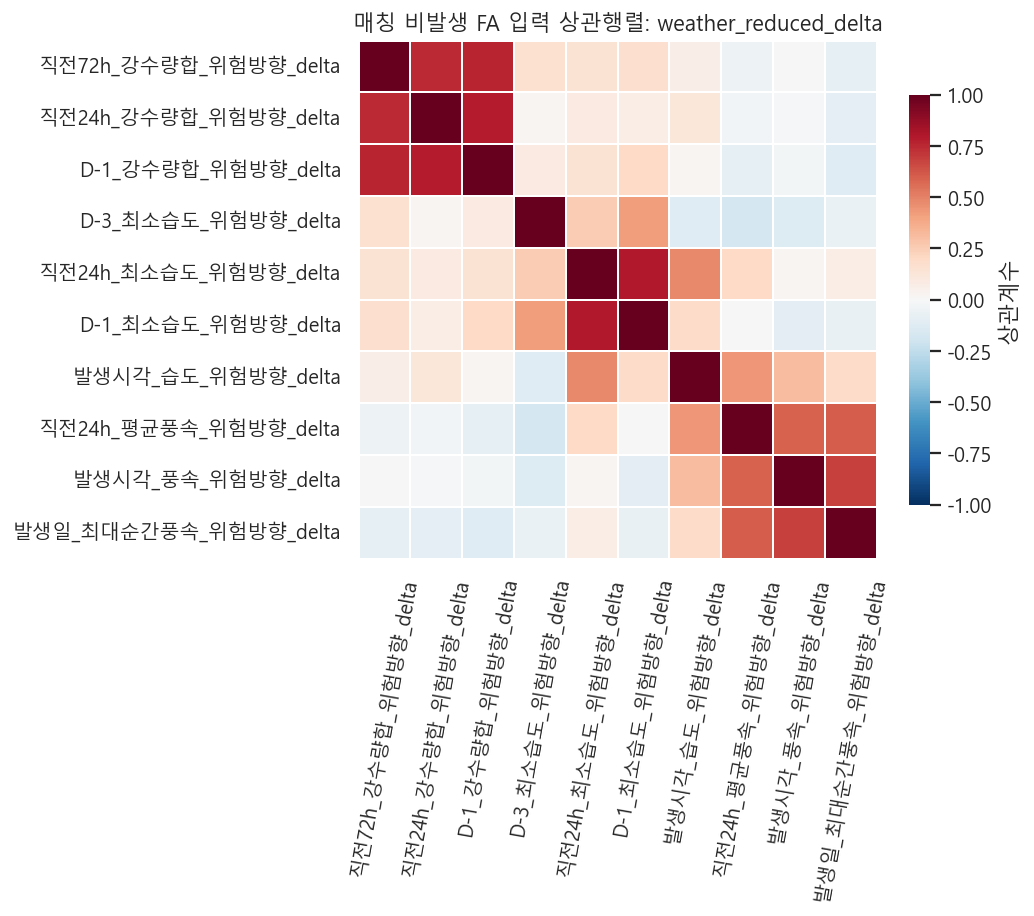

In [11]:
fa_corr = fa_fit_X.corr()

corr_pairs = []
for i, col_i in enumerate(fa_corr.columns):
    for j, col_j in enumerate(fa_corr.columns):
        if j <= i:
            continue
        corr_value = fa_corr.loc[col_i, col_j]
        corr_pairs.append(
            {
                "변수1": col_i,
                "변수2": col_j,
                "상관계수": corr_value,
                "절대상관": abs(corr_value),
            }
        )

fa_high_corr_pairs = (
    pd.DataFrame(corr_pairs)
    .sort_values("절대상관", ascending=False)
    .reset_index(drop=True)
)

if fa_corr.shape[0] >= 3:
    corr_distance = (1 - fa_corr.abs()).fillna(1.0)
    corr_distance_array = corr_distance.to_numpy(copy=True)
    np.fill_diagonal(corr_distance_array, 0.0)
    corr_linkage = linkage(squareform(corr_distance_array, checks=False), method="average")
    corr_order = leaves_list(corr_linkage)
    fa_corr_ordered = fa_corr.iloc[corr_order, corr_order]
else:
    fa_corr_ordered = fa_corr.copy()

display(Markdown("### 절대상관 상위 변수쌍"))
display(fa_high_corr_pairs.head(30).round(4))

fig_width = max(8, 0.55 * fa_corr_ordered.shape[1])
fig_height = max(7, 0.50 * fa_corr_ordered.shape[0])
fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=130)
sns.heatmap(
    fa_corr_ordered,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.75, "label": "상관계수"},
    ax=ax,
)
ax.set_title(f"매칭 비발생 FA 입력 상관행렬: {FA_INPUT_NAME}")
ax.tick_params(axis="x", labelrotation=80)
ax.tick_params(axis="y", labelrotation=0)
plt.tight_layout()
plt.show()


### 7-2. KMO 및 Bartlett 구형성 검정

KMO는 변수들이 공통요인으로 설명될 수 있는지, Bartlett 검정은 상관행렬이 단위행렬이 아닌지 확인한다.


In [13]:
def interpret_kmo(value):
    if pd.isna(value):
        return "계산불가"
    if value >= 0.90:
        return "매우 우수"
    if value >= 0.80:
        return "우수"
    if value >= 0.70:
        return "보통 이상"
    if value >= 0.60:
        return "허용"
    if value >= 0.50:
        return "낮지만 검토 가능"
    return "부적합 검토"


kmo_per_variable, kmo_total = calculate_kmo(fa_fit_X)
kmo_table = (
    pd.DataFrame(
        {
            "변수": fa_fit_X.columns,
            "KMO": kmo_per_variable,
        }
    )
    .assign(판정=lambda df: df["KMO"].map(interpret_kmo))
    .sort_values("KMO")
    .reset_index(drop=True)
)

bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(fa_fit_X)
bartlett_result = pd.DataFrame(
    {
        "검정": ["Bartlett 구형성 검정"],
        "chi_square": [bartlett_chi2],
        "p_value": [bartlett_p],
        "판정": [
            "요인분석 가능" if bartlett_p < 0.05 else "요인분석 부적합 검토"
        ],
    }
)

fa_suitability_summary = pd.DataFrame(
    {
        "항목": [
            "선택 입력셋",
            "표본 수",
            "변수 수",
            "KMO 전체",
            "KMO 판정",
            "KMO 0.50 미만 변수 수",
            "KMO 0.60 미만 변수 수",
            "Bartlett chi-square",
            "Bartlett p-value",
        ],
        "값": [
            FA_INPUT_NAME,
            fa_fit_X.shape[0],
            fa_fit_X.shape[1],
            round(float(kmo_total), 4),
            interpret_kmo(kmo_total),
            int(kmo_table["KMO"].lt(0.50).sum()),
            int(kmo_table["KMO"].lt(0.60).sum()),
            round(float(bartlett_chi2), 4),
            f"{bartlett_p:.6g}",
        ],
    }
)

display(Markdown("### FA 적합성 점검 요약"))
display(fa_suitability_summary)
display(Markdown("### 변수별 KMO"))
display(kmo_table.round(4))
display(Markdown("### Bartlett 구형성 검정"))
display(bartlett_result)

print("생성 객체:")
print("- FA_INPUT_NAME: 현재 선택 입력셋 이름")
print("- fa_fit_X: 상수/결측 제거 후 FA 적합성 점검 입력")
print("- fa_fit_meta: fa_fit_X와 같은 index의 메타데이터")
print("- fa_corr: 상관행렬")
print("- fa_high_corr_pairs: 절대상관 상위 변수쌍")
print("- kmo_table, kmo_total: 변수별/전체 KMO")
print("- bartlett_result: Bartlett 구형성 검정 결과")
print("- fa_suitability_summary: FA 적합성 점검 요약")


### FA 적합성 점검 요약

,항목,값
0,선택 입력셋,weather_reduced_delta
1,표본 수,3395
2,변수 수,10
3,KMO 전체,0.6646
4,KMO 판정,허용
5,KMO 0.50 미만 변수 수,0
6,KMO 0.60 미만 변수 수,3
7,Bartlett chi-square,18103.683
8,Bartlett p-value,0


### 변수별 KMO

,변수,KMO,판정
0,직전24h_최소습도_위험방향_delta,0.5349,낮지만 검토 가능
1,D-1_최소습도_위험방향_delta,0.5393,낮지만 검토 가능
2,발생시각_습도_위험방향_delta,0.5725,낮지만 검토 가능
3,발생일_최대순간풍속_위험방향_delta,0.6513,허용
4,D-3_최소습도_위험방향_delta,0.6736,허용
5,발생시각_풍속_위험방향_delta,0.6942,허용
6,직전24h_강수량합_위험방향_delta,0.7229,보통 이상
7,D-1_강수량합_위험방향_delta,0.7236,보통 이상
8,직전72h_강수량합_위험방향_delta,0.7861,보통 이상
9,직전24h_평균풍속_위험방향_delta,0.7865,보통 이상


### Bartlett 구형성 검정

,검정,chi_square,p_value,판정
0,Bartlett 구형성 검정,18103.682994,0.0,요인분석 가능


생성 객체:
- FA_INPUT_NAME: 현재 선택 입력셋 이름
- fa_fit_X: 상수/결측 제거 후 FA 적합성 점검 입력
- fa_fit_meta: fa_fit_X와 같은 index의 메타데이터
- fa_corr: 상관행렬
- fa_high_corr_pairs: 절대상관 상위 변수쌍
- kmo_table, kmo_total: 변수별/전체 KMO
- bartlett_result: Bartlett 구형성 검정 결과
- fa_suitability_summary: FA 적합성 점검 요약


### 7번 실행 결과 해석: 매칭 비발생 FA 적합성 점검

이번 단계는 `weather_reduced_delta` 입력셋이 매칭 비발생 기반 FA에 들어갈 수 있는지 확인한 것이다.
비발생은 같은 `기상셀ID`, 같은 월, 같은 시간대의 다른 시점이며, 산불 발생시각 전후 `±72h`는 대조군 후보에서 제외했다.

#### 매칭 비발생 대조군 품질
매칭 품질은 매우 안정적이다.
기상셀에 매칭된 산불은 `3,401건`이고, 매칭 비발생 대조군은 총 `17,005행`이다.
산불 1건당 목표 매칭 수는 `5개`였으며, 모든 산불이 목표 매칭 수를 충족했다.
매칭 없음 산불과 목표 미만 산불은 모두 `0건`이고, 산불 발생시점과 대조군의 중복도 `False`로 확인되었다.
기후지형_번지유형별로도 6개 그룹 모두 평균 선택 매칭 수가 `5.0`이므로, 특정 공간 유형에서만 대조군이 부족한 문제는 없다.

| 항목 | 값 |
| --- | ---: |
| 기상셀 매칭 산불 | `3,401` |
| 매칭 비발생 행 수 | `17,005` |
| 목표 매칭 수 | `5` |
| 매칭 산불 수 | `3,401` |
| 매칭 없음 산불 수 | `0` |
| 목표 미만 산불 수 | `0` |
| 산불 1건당 평균 선택 매칭 수 | `5.0` |
| 산불 발생시점과 대조군 중복 여부 | `False` |

#### 위험방향 delta 분포 해석
위험방향 delta는 값이 클수록 같은 장소·월·시간대의 평상시보다 산불 위험 방향으로 이탈했다는 뜻이다.
습도와 강수량은 `매칭 비발생 평균 - 산불값`, 풍속은 `산불값 - 매칭 비발생 평균`으로 계산했다.

습도 delta는 전반적으로 양수 쪽으로 이동했다.
`직전24h_최소습도_위험방향_delta`는 평균 `+8.9759`, 중앙값 `+9.4000`, 양수비율 `79.7118%`이고, `D-1_최소습도_위험방향_delta`도 평균 `+8.6574`, 중앙값 `+9.7320`, 양수비율 `75.9188%`이다.
즉 산불 발생 시점은 같은 장소·계절·시간대의 평상시보다 직전 24시간 및 전일 최소습도가 낮은 경우가 많다.
`발생시각_습도_위험방향_delta`도 평균 `+7.4051`, 중앙값 `+7.9960`, 양수비율 `67.1567%`로 발생 순간의 상대적 저습 경향을 보인다.

강수 delta도 양수 쪽으로 뚜렷하게 이동한다.
`직전72h_강수량합_위험방향_delta`는 평균 `+3.4594`, 중앙값 `+2.0560`, 양수비율 `83.5931%`이고, `직전24h_강수량합_위험방향_delta`는 평균 `+1.2937`, 중앙값 `+0.3400`, 양수비율 `74.0959%`이다.
다만 최솟값이 `-250mm` 안팎까지 내려가는 사례가 있어 강수 delta는 극단 강수 사건의 영향을 받는 비대칭 분포이다.
따라서 FA에서는 강수부족 축으로 해석하되, 이후 요인점수 생성 단계에서 극단값 민감도를 반드시 확인해야 한다.

풍속 delta는 습도·강수보다 약하다.
`발생시각_풍속_위험방향_delta`는 평균 `+0.0989`, 중앙값이 거의 `0`, 양수비율 `49.9265%`로 발생 순간 풍속 자체는 평상시 대비 강한 방향으로 크게 분리되지 않는다.
반면 `발생일_최대순간풍속_위험방향_delta`는 평균 `+0.6753`, 중앙값 `+0.2640`, 양수비율 `53.5137%`이고, `직전24h_평균풍속_위험방향_delta`는 평균 `+0.1770`, 중앙값 `+0.0339`, 양수비율 `51.9847%`이다.
즉 풍속은 모든 산불에서 보편적으로 높아지는 축이라기보다, 일부 강풍 사례를 설명하는 트리거 축으로 보는 것이 적절하다.

#### FA 입력셋 및 결측
FA 기본 입력은 대표 기상 delta 10개 변수인 `weather_reduced_delta`로 설정했다.
원자료는 `3,401행`, 완전케이스는 `3,395행`이며, 상수/단일값 제거 변수와 전부 결측 변수는 없다.
결측은 `D-3_최소습도_위험방향_delta` 6건(`0.18%`), `D-1_최소습도_위험방향_delta` 2건(`0.06%`), `D-1_강수량합_위험방향_delta` 2건(`0.06%`)으로 매우 작다.
따라서 결측 때문에 표본 구조가 왜곡될 가능성은 낮다.

| 입력셋 | 설명 | 변수수 | 완전케이스 |
| --- | --- | ---: | ---: |
| `weather_full_delta` | 전체 기상 위험방향 delta | `19` | `3,395` |
| `weather_reduced_delta` | 대표 기상 위험방향 delta | `10` | `3,395` |
| `mixed_full_delta_topo_access` | 전체 기상 delta + 전체 지형/접근성 | `31` | `2,670` |
| `mixed_reduced_delta_topo_access` | 대표 기상 delta + 대표 지형/접근성 | `18` | `2,670` |

#### 상관행렬 및 플롯 해석
상관행렬 플롯에서는 세 개의 기상 블록이 분명하게 보인다.

첫째, 강수부족 delta 블록이 가장 안정적이다.
`직전24h_강수량합`, `직전72h_강수량합`, `D-1_강수량합` delta가 서로 `0.7477~0.7870` 수준의 높은 양의 상관을 보인다.
이는 최근 24~72시간 및 전일 강수부족이 하나의 공통 축으로 묶일 가능성이 높다는 뜻이다.

둘째, 풍속 delta 블록도 명확하다.
`발생시각_풍속`, `직전24h_평균풍속`, `발생일_최대순간풍속` delta가 `0.5896~0.6815`의 양의 상관을 보인다.
발생 순간 풍속과 당일 최대순간풍속, 직전 24시간 평균풍속이 함께 움직이므로 상대강풍 요인으로 추출될 가능성이 높다.

셋째, 습도 delta 블록은 두 부분으로 나뉜다.
`직전24h_최소습도`와 `D-1_최소습도` delta는 `0.8019`로 매우 강하게 묶인다.
반면 `D-3_최소습도`는 `D-1_최소습도`와 `0.4184`, `직전24h_최소습도`와 `0.2552` 수준이라 장기 선행습도라기보다 별도 잔여 성격을 가질 수 있다.
`발생시각_습도`는 `직전24h_최소습도`와 `0.4774`로 연결되지만, 동시에 `직전24h_평균풍속`과도 `0.4444`, `발생시각_풍속`과 `0.3109`의 양의 상관을 보여 발생 순간의 저습-강풍 복합 조건을 일부 반영한다.

블록 간 상관은 대체로 약하다.
특히 강수부족 블록과 풍속 블록의 상관은 대부분 `|r| < 0.12` 수준이다.
따라서 매칭 비발생 기준의 기상 이탈 구조는 `강수부족`, `상대강풍`, `상대건조`가 비교적 분리된 구조로 나타난다.

| 변수1 | 변수2 | 상관계수 |
| --- | --- | ---: |
| `직전24h_최소습도_delta` | `D-1_최소습도_delta` | `0.8019` |
| `직전24h_강수량합_delta` | `D-1_강수량합_delta` | `0.7870` |
| `직전72h_강수량합_delta` | `D-1_강수량합_delta` | `0.7585` |
| `직전24h_강수량합_delta` | `직전72h_강수량합_delta` | `0.7477` |
| `발생시각_풍속_delta` | `발생일_최대순간풍속_delta` | `0.6815` |
| `직전24h_평균풍속_delta` | `발생일_최대순간풍속_delta` | `0.6040` |
| `발생시각_풍속_delta` | `직전24h_평균풍속_delta` | `0.5896` |

#### KMO 및 Bartlett 결과 해석
전체 KMO는 `0.6646`으로 높지는 않지만 허용 가능한 수준이다.
KMO 0.50 미만 변수는 없고, 0.60 미만 변수는 3개이다.
0.60 미만 변수는 `직전24h_최소습도_delta`(`0.5349`), `D-1_최소습도_delta`(`0.5393`), `발생시각_습도_delta`(`0.5725`)로 모두 습도 관련 변수이다.
이는 습도 delta가 강수·풍속 블록처럼 단일한 공통축으로만 움직이지 않고, 발생시각 저습과 전일/직전24h 저습, D-3 잔여 효과가 섞여 있기 때문으로 해석된다.

Bartlett 구형성 검정은 `chi-square = 18103.6830`, `p-value = 0.0000`으로 유의하다.
상관행렬이 단위행렬이라는 귀무가설은 기각되므로, 변수 간 공통요인 구조는 존재한다.
따라서 `weather_reduced_delta` 입력셋은 요인분석을 진행할 수 있다.
다만 KMO가 0.70 미만이므로 결과를 강하게 일반화하기보다는, 3개 내외의 기상 트리거 축을 확인하는 목적의 FA로 사용하는 것이 적절하다.

| 항목 | 값 |
| --- | ---: |
| 선택 입력셋 | `weather_reduced_delta` |
| 표본 수 | `3,395` |
| 변수 수 | `10` |
| KMO 전체 | `0.6646` |
| KMO 0.50 미만 변수 수 | `0` |
| KMO 0.60 미만 변수 수 | `3` |
| Bartlett chi-square | `18103.6830` |
| Bartlett p-value | `0.0000` |

#### 7번 결론 및 다음 단계
매칭 비발생 기반 대표 기상 delta 10개 변수는 FA 진행이 가능하다.
상관행렬은 `강수부족`, `상대강풍`, `상대건조`의 3개 블록을 강하게 시사한다.
특히 기존 산불 발생 사례 절대값 FA와 달리, 여기서는 공간 입지 요인이 아니라 같은 장소·월·시간대의 평상시 대비 기상 이탈 구조가 중심이다.

다음 단계에서는 `weather_reduced_delta`를 기준으로 Parallel Analysis를 수행해 요인 수를 결정한다.
현재 상관구조만 보면 3요인 해가 가장 자연스럽지만, `D-3_최소습도_delta`가 잔여 요인으로 분리될 수 있으므로 3요인과 4요인 후보를 함께 검토한다.
회전 방식은 기존 FA와 동일하게 `varimax`와 `promax`를 비교하되, 기상 트리거 요인들이 완전히 독립이라고 보기 어렵기 때문에 최종 해석은 `promax`를 우선 검토한다.


## 8. 요인 수 결정: 병렬분석(Parallel Analysis)

`fa_fit_X`로 선택된 FA 입력셋의 실제 상관행렬 고유값을 같은 표본 수·변수 수의 무작위 자료 고유값과 비교한다. 기본 판단 기준은 무작위 고유값의 95퍼센타일이다.


In [14]:
# 8-1. Parallel Analysis 계산
N_PARALLEL_ITER = 500
PARALLEL_PERCENTILE = 95
PA_RANDOM_STATE = RANDOM_STATE

try:
    fa_fit_X
except NameError as exc:
    raise NameError("7번 섹션을 먼저 실행해 fa_fit_X를 생성해야 한다.") from exc

pa_X = fa_fit_X.copy().apply(pd.to_numeric, errors="coerce")
pa_X = pa_X.dropna(axis=0, how="any")
pa_constant_cols = pa_X.columns[pa_X.nunique(dropna=True) <= 1].tolist()
if pa_constant_cols:
    pa_X = pa_X.drop(columns=pa_constant_cols)

pa_n_samples, pa_n_features = pa_X.shape
if pa_n_samples < 50:
    raise ValueError(f"Parallel Analysis 표본 수가 너무 적습니다: n={pa_n_samples}")
if pa_n_features < 3:
    raise ValueError(f"Parallel Analysis 변수 수가 너무 적습니다: p={pa_n_features}")


def correlation_eigenvalues(df):
    corr = df.corr().to_numpy(copy=True)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(corr, 1.0)
    eigenvalues = np.linalg.eigvalsh(corr)
    return np.sort(eigenvalues)[::-1]


observed_eigenvalues = correlation_eigenvalues(pa_X)
rng = np.random.default_rng(PA_RANDOM_STATE)
random_eigenvalues = np.empty((N_PARALLEL_ITER, pa_n_features), dtype=np.float64)

for iter_idx in range(N_PARALLEL_ITER):
    random_data = rng.normal(size=(pa_n_samples, pa_n_features))
    random_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0, ddof=1)
    random_corr = np.corrcoef(random_data, rowvar=False)
    random_corr = np.nan_to_num(random_corr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(random_corr, 1.0)
    random_eigenvalues[iter_idx] = np.sort(np.linalg.eigvalsh(random_corr))[::-1]

random_mean = random_eigenvalues.mean(axis=0)
random_p95 = np.percentile(random_eigenvalues, PARALLEL_PERCENTILE, axis=0)

pa_table = pd.DataFrame(
    {
        "요인번호": np.arange(1, pa_n_features + 1),
        "실제_고유값": observed_eigenvalues,
        "무작위_평균": random_mean,
        "무작위_p95": random_p95,
        "실제값_무작위평균_초과": observed_eigenvalues > random_mean,
        "실제값_무작위p95_초과": observed_eigenvalues > random_p95,
        "Kaiser_1초과": observed_eigenvalues > 1.0,
    }
)

pa_n_factors_p95 = int(pa_table["실제값_무작위p95_초과"].sum())
pa_n_factors_mean = int(pa_table["실제값_무작위평균_초과"].sum())
kaiser_n_factors = int(pa_table["Kaiser_1초과"].sum())

pa_summary = pd.DataFrame(
    {
        "기준": [
            f"Parallel Analysis {PARALLEL_PERCENTILE}퍼센타일",
            "Parallel Analysis 평균",
            "Kaiser 기준(eigenvalue > 1)",
        ],
        "요인수": [pa_n_factors_p95, pa_n_factors_mean, kaiser_n_factors],
    }
)

candidate_values = [pa_n_factors_p95, pa_n_factors_mean, kaiser_n_factors]
for value in [pa_n_factors_p95 - 1, pa_n_factors_p95 + 1, 3, 4]:
    candidate_values.append(value)
fa_n_factor_candidates = sorted({int(v) for v in candidate_values if 1 <= int(v) < pa_n_features})
pa_selected_n_factors = max(1, min(pa_n_factors_p95, pa_n_features - 1))

pa_result_summary = pd.DataFrame(
    {
        "항목": [
            "FA 입력셋",
            "표본 수",
            "변수 수",
            "무작위 반복 수",
            "무작위 기준 퍼센타일",
            "p95 기준 선택 요인 수",
            "회전 비교 후보 요인 수",
        ],
        "값": [
            FA_INPUT_NAME,
            pa_n_samples,
            pa_n_features,
            N_PARALLEL_ITER,
            PARALLEL_PERCENTILE,
            pa_selected_n_factors,
            ", ".join(map(str, fa_n_factor_candidates)),
        ],
    }
)

if pa_constant_cols:
    print("상수/단일값 제거 변수:", pa_constant_cols)

display(Markdown("### Parallel Analysis 요약"))
display(pa_result_summary)
display(Markdown("### 요인 수 기준별 결과"))
display(pa_summary)
display(Markdown("### 고유값 비교"))
display(pa_table.round(4))

print("생성 객체:")
print("- pa_X: Parallel Analysis에 사용한 입력")
print("- pa_table: 실제/무작위 고유값 비교")
print("- pa_summary: 기준별 요인 수")
print("- pa_selected_n_factors: p95 기준 기본 요인 수")
print("- fa_n_factor_candidates: 회전 비교용 요인 수 후보")


### Parallel Analysis 요약

,항목,값
0,FA 입력셋,weather_reduced_delta
1,표본 수,3395
2,변수 수,10
3,무작위 반복 수,500
4,무작위 기준 퍼센타일,95
5,p95 기준 선택 요인 수,3
6,회전 비교 후보 요인 수,"2, 3, 4"


### 요인 수 기준별 결과

,기준,요인수
0,Parallel Analysis 95퍼센타일,3
1,Parallel Analysis 평균,3
2,Kaiser 기준(eigenvalue > 1),3


### 고유값 비교

,요인번호,실제_고유값,무작위_평균,무작위_p95,실제값_무작위평균_초과,실제값_무작위p95_초과,Kaiser_1초과
0,1,2.7976,1.0853,1.1071,True,True,True
1,2,2.5628,1.0607,1.0773,True,True,True
2,3,1.8751,1.0407,1.0562,True,True,True
3,4,0.9952,1.0234,1.0348,False,False,False
4,5,0.5291,1.0072,1.0188,False,False,False
5,6,0.3790,0.9915,1.0032,False,False,False
6,7,0.2985,0.9753,0.9862,False,False,False
7,8,0.2445,0.9584,0.9715,False,False,False
8,9,0.1881,0.9400,0.9550,False,False,False
9,10,0.1302,0.9174,0.9347,False,False,False


생성 객체:
- pa_X: Parallel Analysis에 사용한 입력
- pa_table: 실제/무작위 고유값 비교
- pa_summary: 기준별 요인 수
- pa_selected_n_factors: p95 기준 기본 요인 수
- fa_n_factor_candidates: 회전 비교용 요인 수 후보


### 8-1. 병렬분석 Scree Plot

Scree plot으로 실제 고유값과 무작위 자료의 평균 및 95퍼센타일 기준선을 비교한다.


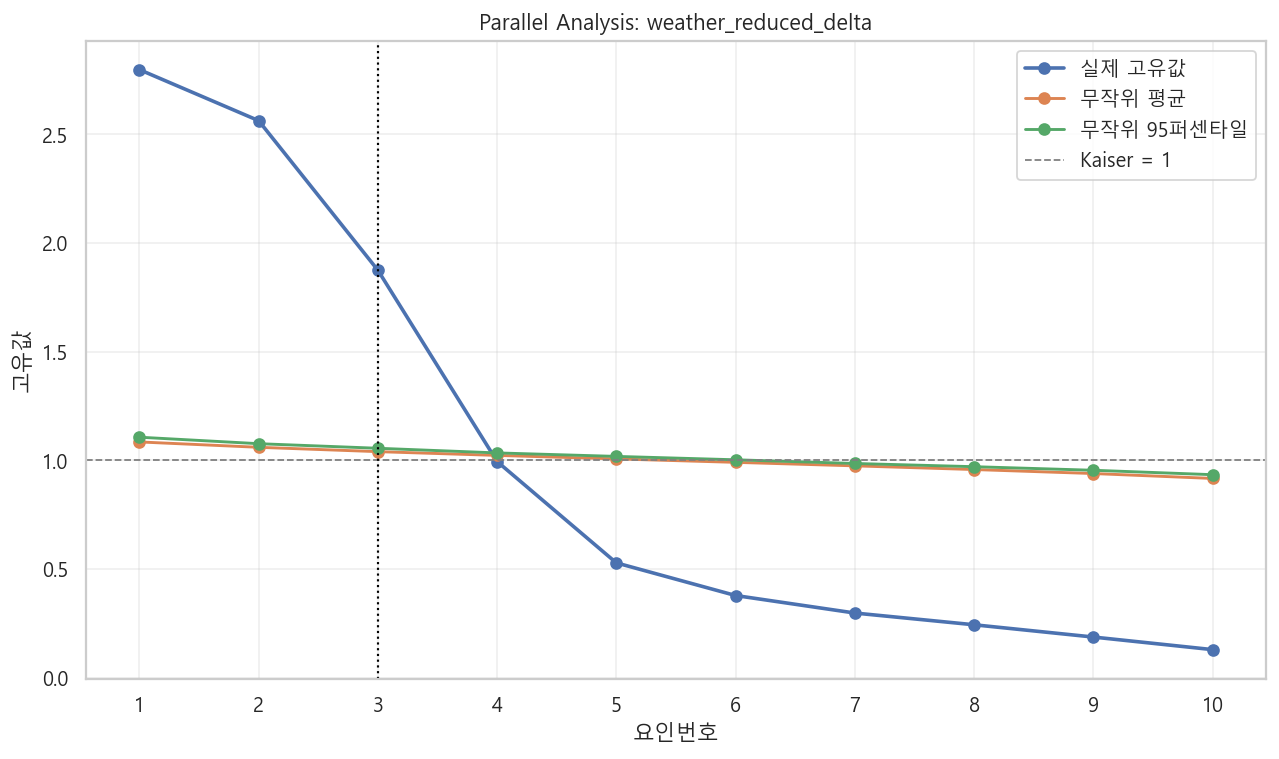

In [15]:
# 8-2. Parallel Analysis Scree Plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=130)
ax.plot(
    pa_table["요인번호"],
    pa_table["실제_고유값"],
    marker="o",
    linewidth=2,
    label="실제 고유값",
)
ax.plot(
    pa_table["요인번호"],
    pa_table["무작위_평균"],
    marker="o",
    linewidth=1.6,
    label="무작위 평균",
)
ax.plot(
    pa_table["요인번호"],
    pa_table["무작위_p95"],
    marker="o",
    linewidth=1.6,
    label=f"무작위 {PARALLEL_PERCENTILE}퍼센타일",
)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Kaiser = 1")
ax.axvline(pa_selected_n_factors, color="black", linestyle=":", linewidth=1.2)
ax.set_title(f"Parallel Analysis: {FA_INPUT_NAME}")
ax.set_xlabel("요인번호")
ax.set_ylabel("고유값")
ax.set_xticks(pa_table["요인번호"])
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 8-2. 요인 수 결정 메모

실행 후 95퍼센타일 기준을 우선 사용한다. 선택 경계가 애매하면 다음 회전/적재량 단계에서 인접 요인 수를 함께 비교한다.


In [16]:
# 8-3. 다음 단계 판단 메모
last_selected = pa_table.loc[pa_table["요인번호"].eq(pa_selected_n_factors)].iloc[0]
next_factor = pa_table.loc[pa_table["요인번호"].eq(pa_selected_n_factors + 1)]

if len(next_factor) > 0:
    next_factor = next_factor.iloc[0]
    next_margin = next_factor["실제_고유값"] - next_factor["무작위_p95"]
else:
    next_margin = np.nan

selected_margin = last_selected["실제_고유값"] - last_selected["무작위_p95"]

pa_decision_memo = pd.DataFrame(
    {
        "항목": [
            "p95 기준 선택 요인 수",
            "선택 요인의 실제 고유값",
            "선택 요인의 무작위 p95",
            "선택 요인의 기준 초과폭",
            "다음 요인의 기준 초과폭",
            "회전 비교 후보",
        ],
        "값": [
            pa_selected_n_factors,
            round(float(last_selected["실제_고유값"]), 4),
            round(float(last_selected["무작위_p95"]), 4),
            round(float(selected_margin), 4),
            "" if pd.isna(next_margin) else round(float(next_margin), 4),
            ", ".join(map(str, fa_n_factor_candidates)),
        ],
    }
)

display(Markdown("### Parallel Analysis 판단 메모"))
display(pa_decision_memo)

print(f"다음 기본 단계: 회전/적재량 비교 요인 수 = {pa_selected_n_factors}")
print(f"민감도 확인용 후보 요인 수: {fa_n_factor_candidates}")


### Parallel Analysis 판단 메모

,항목,값
0,p95 기준 선택 요인 수,3
1,선택 요인의 실제 고유값,1.8751
2,선택 요인의 무작위 p95,1.0562
3,선택 요인의 기준 초과폭,0.8189
4,다음 요인의 기준 초과폭,-0.0396
5,회전 비교 후보,"2, 3, 4"


다음 기본 단계: 회전/적재량 비교 요인 수 = 3
민감도 확인용 후보 요인 수: [2, 3, 4]


### 8번 실행 결과 해석: 병렬분석 기반 요인 수 결정

`weather_reduced_delta` 입력셋에 대해 500회 무작위 반복과 95퍼센타일 기준으로 Parallel Analysis를 수행했다.
분석 대상은 `3,395건`, `10개` 대표 기상 위험방향 delta 변수이다.

#### 요인 수 기준별 결과
세 기준이 모두 `3개 요인`을 제안했다.
Parallel Analysis 95퍼센타일 기준, Parallel Analysis 평균 기준, Kaiser 기준(eigenvalue > 1)이 모두 동일하게 3요인 해를 지지하므로, 이번 입력셋의 요인 수 판단은 명확하다.

| 기준 | 요인 수 |
| --- | ---: |
| Parallel Analysis 95퍼센타일 | `3` |
| Parallel Analysis 평균 | `3` |
| Kaiser 기준(eigenvalue > 1) | `3` |

#### 고유값 비교
실제 고유값은 1요인 `2.7976`, 2요인 `2.5628`, 3요인 `1.8751`까지 무작위 95퍼센타일 기준을 충분히 초과한다.
특히 3요인의 기준 초과폭은 `+0.8189`로 커서, 3번째 요인은 우연한 상관구조가 아니라 실제 공통 요인으로 보는 것이 타당하다.

반면 4요인의 실제 고유값은 `0.9952`로 Kaiser 기준 `1.0`에도 약간 미달하며, 무작위 95퍼센타일 `1.0348`보다도 낮다.
4요인의 기준 초과폭은 `-0.0396`이므로, 4요인을 기본 해로 채택할 근거는 부족하다.
다만 4요인이 기준선과 매우 멀지는 않으므로, 3요인 해에서 `D-3_최소습도_delta` 같은 잔여 변수가 해석되지 않으면 보조적으로 4요인 민감도 확인을 할 수 있다.

| 요인번호 | 실제 고유값 | 무작위 평균 | 무작위 p95 | 판단 |
| ---: | ---: | ---: | ---: | --- |
| 1 | `2.7976` | `1.0853` | `1.1071` | 채택 |
| 2 | `2.5628` | `1.0607` | `1.0773` | 채택 |
| 3 | `1.8751` | `1.0407` | `1.0562` | 채택 |
| 4 | `0.9952` | `1.0234` | `1.0348` | 제외 |
| 5 | `0.5291` | `1.0072` | `1.0188` | 제외 |
| 6 | `0.3790` | `0.9915` | `1.0032` | 제외 |
| 7 | `0.2985` | `0.9753` | `0.9862` | 제외 |
| 8 | `0.2445` | `0.9584` | `0.9715` | 제외 |
| 9 | `0.1881` | `0.9400` | `0.9550` | 제외 |
| 10 | `0.1302` | `0.9174` | `0.9347` | 제외 |

#### Scree Plot 해석
Scree Plot에서도 3요인 구조가 명확하다.
실제 고유값 선은 1~3요인까지 무작위 평균 및 무작위 95퍼센타일 선보다 높게 위치한다.
3요인 이후에는 급격히 하락하여 4요인부터는 무작위 기준선 아래로 내려간다.
수직 점선이 표시된 3요인 지점이 실제 고유값이 무작위 기준을 초과하는 마지막 지점이다.

플롯의 꺾임도 3요인 이후에서 나타난다.
1요인과 2요인은 큰 고유값을 가지며, 3요인도 독립적인 설명력을 유지하지만, 4요인부터는 고유값이 약 `1.0` 이하로 떨어지고 이후 완만한 꼬리 구간에 들어간다.
따라서 시각적으로도 3요인 해가 가장 자연스럽다.

#### 해석상 의미
7번 상관행렬에서 확인한 블록 구조와 병렬분석 결과가 일치한다.
즉 매칭 비발생 대비 기상 이탈 구조는 다음 3개 축으로 요약될 가능성이 높다.

- `상대강수부족`: 직전24h, 직전72h, D-1 강수량합 delta
- `상대강풍`: 발생시각 풍속, 직전24h 평균풍속, 발생일 최대순간풍속 delta
- `상대건조`: 발생시각 습도, 직전24h 최소습도, D-1/D-3 최소습도 delta

이는 기존 절대값 FA의 5요인 구조와 다르다.
기존 FA는 공간 입지와 기상 절대 상태가 함께 들어가 `생활권접점`, `산지접근성`, `선행건조`, `강풍`, `강수부족`이 분리되었다.
반면 매칭 비발생 FA의 `weather_reduced_delta`는 공간 변수를 제외하고 같은 장소·월·시간대의 평상시 대비 기상 이탈만 보므로, 핵심 구조가 3개의 동적 기상 트리거 요인으로 축약된다.

#### 8번 결론 및 다음 단계
기본 요인 수는 `3개`로 결정한다.
다음 단계에서는 `n_factors = 3`을 기본값으로 두고 `varimax`와 `promax` 회전을 비교한다.
민감도 확인용으로는 코드가 제안한 `2, 3, 4`요인 후보를 함께 볼 수 있지만, 본 분석의 기본 해석은 3요인 해를 우선한다.


## 9. 요인 회전 방식 비교: Varimax vs Promax

병렬분석 결과에 따라 기본 요인 수는 `3개`로 둔다.
이 단계에서는 같은 3요인 해를 `varimax`와 `promax`로 각각 회전한 뒤, 공통성, 교차적재, 약한 주적재, 요인 간 상관을 비교한다.


In [22]:
# 9-1. 회전 방식 비교 계산
from factor_analyzer import FactorAnalyzer

FA_N_FACTORS = int(globals().get("pa_selected_n_factors", 3))
PRIMARY_LOADING_CUTOFF = 0.40
CROSS_LOADING_CUTOFF = 0.30
LOW_COMMUNALITY_CUTOFF = 0.20
FA_ROTATIONS = ["varimax", "promax"]

if "pa_X" in globals():
    fa_rotation_X = pa_X.copy()
else:
    fa_rotation_X = fa_fit_X.copy()

fa_rotation_X = fa_rotation_X.apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any")
fa_rotation_X = fa_rotation_X.loc[:, fa_rotation_X.nunique(dropna=True) > 1]
fa_rotation_Z = (fa_rotation_X - fa_rotation_X.mean()) / fa_rotation_X.std(ddof=0)
fa_rotation_Z = fa_rotation_Z.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

if FA_N_FACTORS < 1 or FA_N_FACTORS >= fa_rotation_Z.shape[1]:
    raise ValueError(f"FA_N_FACTORS={FA_N_FACTORS}가 변수 수 {fa_rotation_Z.shape[1]}에 비해 부적절합니다.")


def make_factor_names(n_factors):
    return [f"F{i}" for i in range(1, n_factors + 1)]


def fit_rotated_fa(n_factors, rotation):
    factor_names = make_factor_names(n_factors)
    model = FactorAnalyzer(n_factors=n_factors, rotation=rotation, method="minres")
    model.fit(fa_rotation_Z)

    loadings = pd.DataFrame(model.loadings_, index=fa_rotation_Z.columns, columns=factor_names)
    abs_loadings = loadings.abs()
    communalities = pd.Series(model.get_communalities(), index=fa_rotation_Z.columns, name="공통성")
    uniquenesses = pd.Series(model.get_uniquenesses(), index=fa_rotation_Z.columns, name="고유성")

    variance, prop_var, cum_var = model.get_factor_variance()
    variance_table = pd.DataFrame(
        {
            "요인": factor_names,
            "SS_Loadings": variance,
            "Proportion_Var": prop_var,
            "Cumulative_Var": cum_var,
        }
    )

    phi = getattr(model, "phi_", None)
    if phi is None:
        phi_table = pd.DataFrame(np.eye(n_factors), index=factor_names, columns=factor_names)
    else:
        phi_table = pd.DataFrame(phi, index=factor_names, columns=factor_names)

    primary_idx = abs_loadings.to_numpy().argmax(axis=1)
    primary_factor = [factor_names[idx] for idx in primary_idx]
    primary_loading = loadings.to_numpy()[np.arange(loadings.shape[0]), primary_idx]

    loading_detail = pd.DataFrame(
        {
            "변수": loadings.index,
            "주요인": primary_factor,
            "주적재량": primary_loading,
            "주적재량_abs": abs_loadings.max(axis=1).values,
            "적재량_0.30이상_개수": (abs_loadings >= CROSS_LOADING_CUTOFF).sum(axis=1).values,
            "적재량_0.40이상_개수": (abs_loadings >= PRIMARY_LOADING_CUTOFF).sum(axis=1).values,
            "공통성": communalities.values,
            "고유성": uniquenesses.values,
        }
    )
    loading_detail["교차적재_후보"] = loading_detail["적재량_0.30이상_개수"] >= 2
    loading_detail["약한_주적재"] = loading_detail["주적재량_abs"] < PRIMARY_LOADING_CUTOFF
    loading_detail["낮은_공통성"] = loading_detail["공통성"] < LOW_COMMUNALITY_CUTOFF

    salient_counts = (abs_loadings >= PRIMARY_LOADING_CUTOFF).sum(axis=0)
    off_diag = phi_table.where(~np.eye(n_factors, dtype=bool))
    max_factor_corr = off_diag.abs().max().max()
    factor_corr_ge_030 = int((off_diag.abs() >= 0.30).sum().sum() / 2)

    summary = {
        "rotation": rotation,
        "n_obs": len(fa_rotation_Z),
        "n_vars": fa_rotation_Z.shape[1],
        "n_factors": n_factors,
        "mean_communality": communalities.mean(),
        "min_communality": communalities.min(),
        "max_communality": communalities.max(),
        "communality_lt_020_n": int((communalities < LOW_COMMUNALITY_CUTOFF).sum()),
        "communality_gt_1_n": int((communalities > 1.0).sum()),
        "uniqueness_lt_0_n": int((uniquenesses < 0.0).sum()),
        "weak_primary_loading_n": int(loading_detail["약한_주적재"].sum()),
        "cross_loading_n": int(loading_detail["교차적재_후보"].sum()),
        "empty_factor_n": int((salient_counts == 0).sum()),
        "min_salient_vars_per_factor": int(salient_counts.min()),
        "max_abs_factor_corr": float(max_factor_corr) if pd.notna(max_factor_corr) else 0.0,
        "factor_corr_ge_030_n": factor_corr_ge_030,
        "cumulative_variance": float(variance_table["Cumulative_Var"].iloc[-1]),
    }

    return {
        "model": model,
        "factor_names": factor_names,
        "loadings": loadings,
        "abs_loadings": abs_loadings,
        "loading_detail": loading_detail,
        "communalities": communalities,
        "uniquenesses": uniquenesses,
        "variance": variance_table,
        "phi": phi_table,
        "summary": summary,
    }


factor_names = make_factor_names(FA_N_FACTORS)
rotation_results = {rotation: fit_rotated_fa(FA_N_FACTORS, rotation) for rotation in FA_ROTATIONS}
rotation_summary = pd.DataFrame([rotation_results[r]["summary"] for r in FA_ROTATIONS])

display(Markdown("### 회전 방식 비교 요약"))
display(rotation_summary.round(4))

for rotation in FA_ROTATIONS:
    display(Markdown(f"### `{rotation}` 요인별 설명분산"))
    display(rotation_results[rotation]["variance"].round(4))

print("생성 객체:")
print("- fa_rotation_Z: 회전 분석에 사용한 표준화 입력")
print("- rotation_results: 회전 방식별 FA 결과")
print("- rotation_summary: 회전 방식 비교 요약")


### 회전 방식 비교 요약

,rotation,n_obs,n_vars,n_factors,mean_communality,min_communality,max_communality,communality_lt_020_n,communality_gt_1_n,uniqueness_lt_0_n,weak_primary_loading_n,cross_loading_n,empty_factor_n,min_salient_vars_per_factor,max_abs_factor_corr,factor_corr_ge_030_n,cumulative_variance
0,varimax,3395,10,3,0.6346,0.1586,0.9559,1,0,0,1,0,0,2,0.0000,0,0.6346
1,promax,3395,10,3,0.6378,0.1572,0.9709,1,0,0,1,0,0,2,0.2233,0,0.6378


### `varimax` 요인별 설명분산

,요인,SS_Loadings,Proportion_Var,Cumulative_Var
0,F1,2.3072,0.2307,0.2307
1,F2,2.1312,0.2131,0.4438
2,F3,1.9078,0.1908,0.6346


### `promax` 요인별 설명분산

,요인,SS_Loadings,Proportion_Var,Cumulative_Var
0,F1,2.3251,0.2325,0.2325
1,F2,2.1300,0.2130,0.4455
2,F3,1.9232,0.1923,0.6378


생성 객체:
- fa_rotation_Z: 회전 분석에 사용한 표준화 입력
- rotation_results: 회전 방식별 FA 결과
- rotation_summary: 회전 방식 비교 요약


### 9-1. 회전별 적재량 및 Promax 요인상관 확인

두 회전 방식의 적재량 heatmap과 Promax 요인상관 행렬을 확인한다.
Promax 요인상관이 크면 요인 간 독립 가정보다는 사각회전 해석이 더 적절할 수 있다.


### Promax 요인상관 행렬

,F1,F2,F3
F1,1.000,-0.050,0.223
F2,-0.050,1.000,0.006
F3,0.223,0.006,1.000


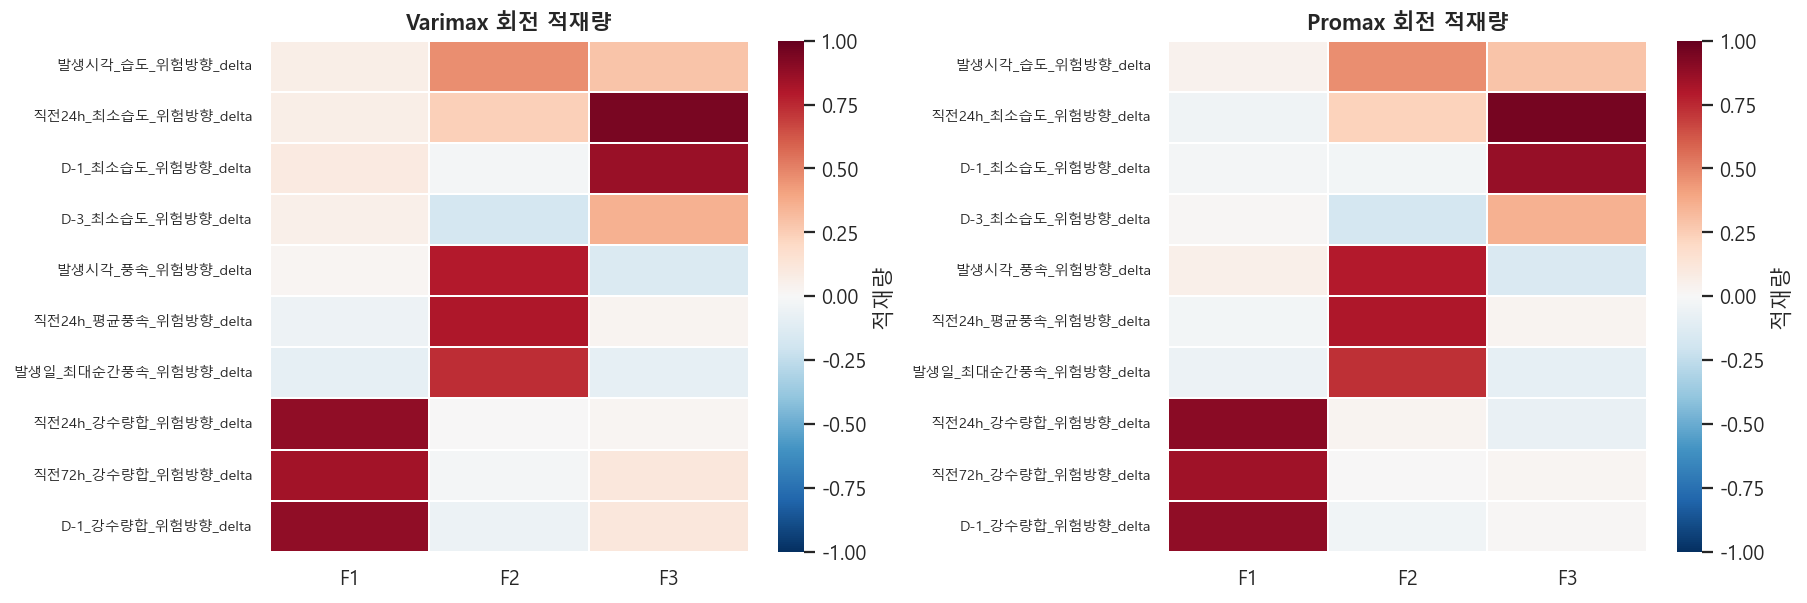

In [23]:
# 9-2. 회전별 적재량 heatmap 및 Promax 요인상관
display(Markdown("### Promax 요인상관 행렬"))
display(rotation_results["promax"]["phi"].round(3))

promax_phi = rotation_results["promax"]["phi"].copy()
promax_off_diag = promax_phi.where(~np.eye(FA_N_FACTORS, dtype=bool))
promax_max_corr = float(promax_off_diag.abs().max().max())

fig_height = max(4.8, 0.35 * fa_rotation_Z.shape[1])
fig, axes = plt.subplots(1, 2, figsize=(14, fig_height), dpi=130)

sns.heatmap(
    rotation_results["varimax"]["loadings"],
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2,
    cbar_kws={"label": "적재량"},
    ax=axes[0],
)
axes[0].set_title("Varimax 회전 적재량", fontweight="bold")
axes[0].tick_params(axis="x", labelrotation=0)
axes[0].tick_params(axis="y", labelsize=8)

sns.heatmap(
    rotation_results["promax"]["loadings"],
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2,
    cbar_kws={"label": "적재량"},
    ax=axes[1],
)
axes[1].set_title("Promax 회전 적재량", fontweight="bold")
axes[1].tick_params(axis="x", labelrotation=0)
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


### 9-2. 회전 방식 임시 선택 및 주적재량 표

요인상관과 적재 구조를 기준으로 임시 선택 회전을 정한다.
최종 선택은 실행 결과 해석 후 확정한다.


In [24]:
# 9-3. 회전 방식 임시 선택 및 변수별 주적재량
varimax_summary = rotation_results["varimax"]["summary"]
promax_summary = rotation_results["promax"]["summary"]

if promax_max_corr >= 0.30:
    selected_rotation = "promax"
    rotation_decision = (
        f"Promax 요인상관 최대 절대값이 {promax_max_corr:.3f}로 0.30 이상이므로, "
        "요인 간 상관을 허용하는 promax를 우선 검토한다."
    )
else:
    varimax_penalty = varimax_summary["cross_loading_n"] + varimax_summary["weak_primary_loading_n"]
    promax_penalty = promax_summary["cross_loading_n"] + promax_summary["weak_primary_loading_n"]
    if promax_penalty < varimax_penalty:
        selected_rotation = "promax"
        rotation_decision = (
            f"Promax 요인상관 최대 절대값은 {promax_max_corr:.3f}로 크지 않지만, "
            "promax의 교차적재/약한 주적재 문제가 더 적어 promax를 우선 검토한다."
        )
    else:
        selected_rotation = "varimax"
        rotation_decision = (
            f"Promax 요인상관 최대 절대값이 {promax_max_corr:.3f}로 0.30 미만이고, "
            "적재 구조도 varimax가 충분히 단순하므로 varimax를 우선 검토한다."
        )

selected_fa = rotation_results[selected_rotation]
selected_loading_detail = (
    selected_fa["loading_detail"]
    .sort_values(["주요인", "주적재량_abs"], ascending=[True, False])
    .reset_index(drop=True)
)

display(Markdown(f"### 회전 방식 임시 선택: `{selected_rotation}`\n\n{rotation_decision}"))
display(Markdown(f"### `{selected_rotation}` 변수별 주적재량"))
display(selected_loading_detail.round(4))

display(Markdown("### 교차적재 또는 약한 주적재 변수"))
loading_issue_table = selected_loading_detail[
    selected_loading_detail["교차적재_후보"]
    | selected_loading_detail["약한_주적재"]
    | selected_loading_detail["낮은_공통성"]
].copy()
display(loading_issue_table.round(4))

print("생성 객체:")
print("- selected_rotation: 임시 선택 회전 방식")
print("- selected_fa: 임시 선택 회전 방식의 FA 결과")
print("- selected_loading_detail: 임시 선택 회전 방식의 변수별 주적재량")
print("- loading_issue_table: 교차적재/약한 주적재/낮은 공통성 변수")


### 회전 방식 임시 선택: `varimax`

Promax 요인상관 최대 절대값이 0.223로 0.30 미만이고, 적재 구조도 varimax가 충분히 단순하므로 varimax를 우선 검토한다.

### `varimax` 변수별 주적재량

,변수,주요인,주적재량,주적재량_abs,적재량_0.30이상_개수,적재량_0.40이상_개수,공통성,고유성,교차적재_후보,약한_주적재,낮은_공통성
0,직전24h_강수량합_위험방향_delta,F1,0.8871,0.8871,1,1,0.7875,0.2125,False,False,False
1,D-1_강수량합_위험방향_delta,F1,0.8829,0.8829,1,1,0.7947,0.2053,False,False,False
2,직전72h_강수량합_위험방향_delta,F1,0.8429,0.8429,1,1,0.7235,0.2765,False,False,False
3,직전24h_평균풍속_위험방향_delta,F2,0.8102,0.8102,1,1,0.6595,0.3405,False,False,False
4,발생시각_풍속_위험방향_delta,F2,0.7911,0.7911,1,1,0.6463,0.3537,False,False,False
5,발생일_최대순간풍속_위험방향_delta,F2,0.7348,0.7348,1,1,0.5561,0.4439,False,False,False
6,발생시각_습도_위험방향_delta,F2,0.4668,0.4668,1,1,0.3056,0.6944,False,False,False
7,직전24h_최소습도_위험방향_delta,F3,0.9465,0.9465,1,1,0.9559,0.0441,False,False,False
8,D-1_최소습도_위험방향_delta,F3,0.8664,0.8664,1,1,0.7587,0.2413,False,False,False
9,D-3_최소습도_위험방향_delta,F3,0.3520,0.3520,1,0,0.1586,0.8414,False,True,True


### 교차적재 또는 약한 주적재 변수

,변수,주요인,주적재량,주적재량_abs,적재량_0.30이상_개수,적재량_0.40이상_개수,공통성,고유성,교차적재_후보,약한_주적재,낮은_공통성
9,D-3_최소습도_위험방향_delta,F3,0.352,0.352,1,0,0.1586,0.8414,False,True,True


생성 객체:
- selected_rotation: 임시 선택 회전 방식
- selected_fa: 임시 선택 회전 방식의 FA 결과
- selected_loading_detail: 임시 선택 회전 방식의 변수별 주적재량
- loading_issue_table: 교차적재/약한 주적재/낮은 공통성 변수


### 9-3. 요인 수 후보 민감도 확인

병렬분석 기본값은 3요인이지만, `2, 3, 4`요인 후보의 회전 결과를 빠르게 비교한다.
이 표는 3요인 해가 실제로 가장 안정적인지 확인하는 보조 진단이다.


In [25]:
# 9-4. 요인 수 후보 민감도 확인
raw_candidates = globals().get("fa_n_factor_candidates", [FA_N_FACTORS])
FA_N_FACTOR_SENSITIVITY_CANDIDATES = sorted(
    {int(v) for v in raw_candidates if 1 <= int(v) < fa_rotation_Z.shape[1]}
)

factor_count_sensitivity_results = {}
sensitivity_rows = []

for n_factors in FA_N_FACTOR_SENSITIVITY_CANDIDATES:
    factor_count_sensitivity_results[n_factors] = {}
    for rotation in FA_ROTATIONS:
        try:
            result = fit_rotated_fa(n_factors, rotation)
            factor_count_sensitivity_results[n_factors][rotation] = result
            row = result["summary"].copy()
            row["status"] = "ok"
        except Exception as exc:
            row = {
                "rotation": rotation,
                "n_obs": len(fa_rotation_Z),
                "n_vars": fa_rotation_Z.shape[1],
                "n_factors": n_factors,
                "status": f"error: {type(exc).__name__}: {exc}",
            }
        sensitivity_rows.append(row)

factor_count_sensitivity_summary = pd.DataFrame(sensitivity_rows)

display(Markdown("### 요인 수 후보별 회전 결과 요약"))
display(factor_count_sensitivity_summary.round(4))

print("생성 객체:")
print("- FA_N_FACTOR_SENSITIVITY_CANDIDATES: 민감도 확인 요인 수 후보")
print("- factor_count_sensitivity_results: 요인 수 후보별 회전 결과")
print("- factor_count_sensitivity_summary: 요인 수 후보별 요약")


### 요인 수 후보별 회전 결과 요약

,rotation,n_obs,n_vars,n_factors,mean_communality,min_communality,max_communality,communality_lt_020_n,communality_gt_1_n,uniqueness_lt_0_n,weak_primary_loading_n,cross_loading_n,empty_factor_n,min_salient_vars_per_factor,max_abs_factor_corr,factor_corr_ge_030_n,cumulative_variance,status
0,varimax,3395,10,2,0.4485,0.0510,0.7495,3,0,0,3,0,0,3,0.0000,0,0.4485,ok
1,promax,3395,10,2,0.4494,0.0525,0.7537,3,0,0,3,0,0,3,0.0312,0,0.4494,ok
2,varimax,3395,10,3,0.6346,0.1586,0.9559,1,0,0,1,0,0,2,0.0000,0,0.6346,ok
3,promax,3395,10,3,0.6378,0.1572,0.9709,1,0,0,1,0,0,2,0.2233,0,0.6378,ok
4,varimax,3395,10,4,0.7041,0.2868,0.8823,0,0,0,0,2,0,2,0.0000,0,0.7041,ok
5,promax,3395,10,4,0.6931,0.3154,0.9088,0,0,0,0,2,0,2,0.4256,1,0.6931,ok


생성 객체:
- FA_N_FACTOR_SENSITIVITY_CANDIDATES: 민감도 확인 요인 수 후보
- factor_count_sensitivity_results: 요인 수 후보별 회전 결과
- factor_count_sensitivity_summary: 요인 수 후보별 요약


### 9번 실행 결과 해석: 3요인 회전 방식 비교

병렬분석에서 결정한 `3요인` 해를 기준으로 `varimax`와 `promax` 회전을 비교했다.
분석 입력은 `weather_reduced_delta`이며, 표본 수는 `3,395건`, 변수 수는 `10개`이다.

#### 회전 방식 비교 요약
두 회전 방식 모두 수치적으로 안정적이다.
`varimax`의 평균 공통성은 `0.6346`, 누적 설명분산은 `0.6346`이고, `promax`의 평균 공통성은 `0.6378`, 누적 설명분산은 `0.6378`이다.
Promax가 아주 약간 높지만 차이는 `0.0032` 수준으로 실질적으로 크지 않다.

두 회전 모두 교차적재 변수는 `0개`, Heywood 징후에 해당하는 공통성 1 초과 변수와 음의 고유성 변수도 `0개`이다.
약한 주적재 변수는 두 회전 모두 `1개`이며, 낮은 공통성 변수도 `1개`이다.
따라서 회전 방식 선택은 공통성 차이보다 해석 단순성과 요인 간 상관 여부를 기준으로 판단하는 것이 적절하다.

| 회전 | 평균 공통성 | 최저 공통성 | 누적 설명분산 | 약한 주적재 | 교차적재 | 최대 요인상관 |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| `varimax` | `0.6346` | `0.1586` | `0.6346` | `1` | `0` | `0.0000` |
| `promax` | `0.6378` | `0.1572` | `0.6378` | `1` | `0` | `0.2233` |

#### Promax 요인상관 행렬 해석
Promax 요인상관의 최대 절대값은 `0.2233`이다.
가장 큰 상관은 `F1`과 `F3` 사이의 `+0.223`이며, `F1-F2`는 `-0.050`, `F2-F3`은 `+0.006`으로 거의 0에 가깝다.
기존 절대값 FA에서는 일부 요인 간 상관이 0.30을 넘었기 때문에 Promax를 우선했지만, 이번 매칭비발생 기상 delta FA에서는 요인 간 상관이 0.30 기준을 넘지 않는다.
따라서 요인 간 상관을 허용해야 할 강한 근거는 없다.

| 요인쌍 | 상관 |
| --- | ---: |
| `F1-F2` | `-0.050` |
| `F1-F3` | `+0.223` |
| `F2-F3` | `+0.006` |

#### 적재량 heatmap 해석
Varimax와 Promax heatmap 모두 거의 같은 3개 블록을 보여준다.
왼쪽 Varimax에서는 세 요인이 더 직교적으로 분리되어 해석이 단순하다.
오른쪽 Promax에서도 동일한 구조가 유지되지만, 요인상관을 허용해도 적재 구조가 크게 개선되지는 않는다.

플롯 기준으로 `F1`은 강수량합 delta 3개 변수가 강하게 적재되는 강수부족 축이다.
`직전24h_강수량합_delta`, `직전72h_강수량합_delta`, `D-1_강수량합_delta`가 모두 F1에 진하게 적재된다.

`F2`는 풍속 delta가 중심이며, `발생시각_풍속_delta`, `직전24h_평균풍속_delta`, `발생일_최대순간풍속_delta`가 강하게 적재된다.
다만 `발생시각_습도_delta`도 F2에 중간 수준으로 적재되어, F2는 순수 풍속이라기보다 발생 순간의 저습-강풍 복합 이탈을 일부 포함한다.

`F3`은 단기 습도 delta 축이다.
`직전24h_최소습도_delta`와 `D-1_최소습도_delta`가 매우 강하게 적재된다.
`D-3_최소습도_delta`도 F3 방향으로 적재되지만 주적재량이 `0.3520`으로 낮고 공통성도 `0.1586`이라, 핵심 요인 변수라기보다 장기 선행습도 잔여 변수로 보는 것이 맞다.

#### Varimax 주적재량 기준 요인 해석
임시 선택된 회전 방식은 `varimax`이다.
Promax 요인상관 최대 절대값이 `0.223`으로 0.30 미만이고, Varimax도 교차적재가 없으며 충분히 단순한 적재 구조를 보였기 때문이다.

`F1`은 강수부족 요인이다.
`D-1_강수량합_delta`의 주적재량은 `0.8829`, `직전24h_강수량합_delta`는 `0.8871`, `직전72h_강수량합_delta`는 `0.8429`이다.
세 변수 모두 공통성이 `0.7235~0.7947`로 높아 매우 안정적인 강수부족 축이다.

`F2`는 상대강풍 요인이다.
`직전24h_평균풍속_delta`가 `0.8102`, `발생시각_풍속_delta`가 `0.7911`, `발생일_최대순간풍속_delta`가 `0.7348`로 강하게 적재된다.
`발생시각_습도_delta`도 `0.4668`로 F2에 적재된다.
이는 산불 발생 순간의 상대적 저습이 단기 습도 축보다 강풍 축과 함께 움직이는 경향이 있음을 뜻한다.
따라서 F2는 이름을 `상대강풍`으로 두되, 해석에서는 `발생시각 저습 동반`을 보조 설명으로 붙이는 것이 적절하다.

`F3`은 단기 상대건조 요인이다.
`직전24h_최소습도_delta`가 `0.9465`, `D-1_최소습도_delta`가 `0.8664`로 매우 강하게 적재된다.
이는 같은 장소·월·시간대의 평상시보다 산불 발생 전 24시간 및 전일의 최소습도가 낮았는지를 나타내는 축이다.
`D-3_최소습도_delta`는 F3에 `0.3520`으로 적재되지만 0.40 기준에 못 미치며 공통성도 낮다.
따라서 `D-3_최소습도_delta`는 최종 요인명 해석에서 핵심 변수로 쓰지 않고 보조 또는 제거 후보로 둔다.

| 요인 | 해석명 | 핵심 변수 |
| --- | --- | --- |
| `F1` | 상대강수부족 | `직전24h_강수량합_delta`, `직전72h_강수량합_delta`, `D-1_강수량합_delta` |
| `F2` | 상대강풍 | `직전24h_평균풍속_delta`, `발생시각_풍속_delta`, `발생일_최대순간풍속_delta` |
| `F3` | 단기 상대건조 | `직전24h_최소습도_delta`, `D-1_최소습도_delta` |

#### 문제 변수
문제 변수는 `D-3_최소습도_위험방향_delta` 하나이다.
주적재량은 `0.3520`, 공통성은 `0.1586`, 고유성은 `0.8414`이다.
교차적재는 아니지만 주적재량이 0.40 미만이고 공통성이 0.20 미만이므로, 3요인 공통구조로 잘 설명되지 않는다.
이 변수는 장기 선행습도의 잔여 성격을 보이며, 최종 축소 모델에서는 제거 또는 보조 변수 전환을 검토한다.

#### 요인 수 민감도 확인
2요인 해는 평균 공통성이 `0.4485~0.4494`로 낮고, 낮은 공통성 변수가 `3개`, 약한 주적재 변수가 `3개`이다.
따라서 2요인 해는 상대강풍, 상대건조, 상대강수부족을 충분히 분리하지 못한다.

3요인 해는 평균 공통성이 `0.6346~0.6378`이고, 교차적재가 없으며, 문제 변수도 `D-3_최소습도_delta` 하나로 제한된다.
병렬분석 기준과도 일치하므로 기본 해로 가장 적절하다.

4요인 해는 평균 공통성이 `0.6931~0.7041`로 더 높고 약한 주적재 변수도 없지만, 교차적재 변수가 `2개` 발생한다.
특히 Promax 4요인 해에서는 최대 요인상관이 `0.4256`으로 커져 요인 분리가 오히려 복잡해진다.
또한 병렬분석에서 4요인은 채택되지 않았으므로, 4요인 해는 기본 해가 아니라 보조 민감도 확인용으로만 둔다.

#### 9번 결론 및 다음 단계
최종 회전 방식은 `varimax`를 우선한다.
매칭비발생 기상 delta FA의 3요인 구조는 요인 간 상관이 크지 않고, Varimax가 교차적재 없이 단순한 구조를 제공하기 때문이다.

다음 단계에서는 Varimax 3요인 해를 기준으로 요인명을 확정하고 요인점수를 생성한다.
요인명은 다음처럼 둘 수 있다.

- `상대강수부족_score`: F1
- `상대강풍_score`: F2
- `단기상대건조_score`: F3

단, `발생시각_습도_delta`는 F2에 적재되므로 `단기상대건조_score`가 모든 습도 이탈을 대표한다고 해석하면 안 된다.
`D-3_최소습도_delta`는 낮은 공통성 변수이므로, 최종 점수 생성 전 제거 민감도 또는 보조 변수 전환 여부를 한 번 더 확인하는 것이 좋다.


## 10. 최종 요인점수 생성 및 D-3 최소습도 민감도 확인

9번 결과에 따라 `varimax` 3요인 해를 기본 최종 모형으로 사용한다.
요인점수는 위험방향 delta 해석과 같은 방향이 되도록 anchor 변수와의 상관을 기준으로 부호를 보정한다.


In [26]:
# 10-1. 최종 3요인 Varimax 모형 고정 및 요인점수 생성
FINAL_ROTATION = "varimax"
FINAL_N_FACTORS = 3

required_objects = ["rotation_results", "fa_rotation_Z", "fa_fit_meta"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(f"먼저 9번 섹션까지 실행해야 합니다. 누락 객체: {missing_objects}")

if FINAL_ROTATION not in rotation_results:
    raise KeyError(f"rotation_results에 {FINAL_ROTATION!r} 결과가 없습니다.")

final_fa = rotation_results[FINAL_ROTATION]
final_model = final_fa["model"]
final_loadings = final_fa["loadings"].copy()
final_loading_detail = final_fa["loading_detail"].copy()
final_variance = final_fa["variance"].copy()
final_phi = final_fa["phi"].copy()

FINAL_FACTOR_NAME_MAP = {
    "F1": "상대강수부족",
    "F2": "상대강풍",
    "F3": "단기상대건조",
}
FINAL_FACTOR_SCORE_NAME_MAP = {
    "F1": "상대강수부족_score",
    "F2": "상대강풍_score",
    "F3": "단기상대건조_score",
}
FINAL_FACTOR_ANCHORS = {
    "F1": [
        "직전24h_강수량합_위험방향_delta",
        "직전72h_강수량합_위험방향_delta",
        "D-1_강수량합_위험방향_delta",
    ],
    "F2": [
        "직전24h_평균풍속_위험방향_delta",
        "발생시각_풍속_위험방향_delta",
        "발생일_최대순간풍속_위험방향_delta",
    ],
    "F3": [
        "직전24h_최소습도_위험방향_delta",
        "D-1_최소습도_위험방향_delta",
    ],
}

missing_anchor_cols = {
    factor: [col for col in cols if col not in fa_rotation_Z.columns]
    for factor, cols in FINAL_FACTOR_ANCHORS.items()
}
missing_anchor_cols = {factor: cols for factor, cols in missing_anchor_cols.items() if cols}
if missing_anchor_cols:
    raise KeyError(f"anchor 변수 누락: {missing_anchor_cols}")

factor_score_raw_array = final_model.transform(fa_rotation_Z)
factor_scores_raw = pd.DataFrame(
    factor_score_raw_array,
    index=fa_rotation_Z.index,
    columns=[f"{factor}_score_raw" for factor in final_loadings.columns],
)

factor_score_orientation_rows = []
factor_scores_oriented = pd.DataFrame(index=fa_rotation_Z.index)

for factor in final_loadings.columns:
    raw_col = f"{factor}_score_raw"
    score_name = FINAL_FACTOR_SCORE_NAME_MAP[factor]
    anchor_cols = FINAL_FACTOR_ANCHORS[factor]
    anchor_value = fa_rotation_Z[anchor_cols].mean(axis=1)
    corr_with_anchor = factor_scores_raw[raw_col].corr(anchor_value)
    sign = 1 if pd.isna(corr_with_anchor) or corr_with_anchor >= 0 else -1
    factor_scores_oriented[score_name] = factor_scores_raw[raw_col] * sign
    factor_score_orientation_rows.append(
        {
            "요인": factor,
            "요인명": FINAL_FACTOR_NAME_MAP[factor],
            "점수명": score_name,
            "anchor_변수": ", ".join(anchor_cols),
            "raw_score_anchor_corr": corr_with_anchor,
            "부호보정": sign,
        }
    )

factor_score_orientation = pd.DataFrame(factor_score_orientation_rows)

matched_factor_score_meta = fa_fit_meta.loc[fa_rotation_Z.index].copy()
matched_factor_scores = pd.concat(
    [matched_factor_score_meta.reset_index(drop=True), factor_scores_oriented.reset_index(drop=True)],
    axis=1,
)

factor_score_summary = (
    factor_scores_oriented
    .agg(["count", "mean", "std", "min", "median", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "요인점수"})
)

factor_score_quantiles = (
    factor_scores_oriented
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .T
    .reset_index()
    .rename(
        columns={
            "index": "요인점수",
            0.01: "p01",
            0.05: "p05",
            0.25: "p25",
            0.5: "p50",
            0.75: "p75",
            0.95: "p95",
            0.99: "p99",
        }
    )
)

score_delta_correlations = pd.concat(
    [factor_scores_oriented, fa_rotation_Z],
    axis=1,
).corr().loc[factor_scores_oriented.columns, fa_rotation_Z.columns]

final_factor_definition = pd.DataFrame(
    [
        {
            "요인": factor,
            "요인명": FINAL_FACTOR_NAME_MAP[factor],
            "요인점수": FINAL_FACTOR_SCORE_NAME_MAP[factor],
            "핵심해석": {
                "F1": "같은 기상셀·월·시간대 평상시보다 최근 강수량이 부족한 정도",
                "F2": "같은 기상셀·월·시간대 평상시보다 발생시각·직전24h·당일 돌풍이 강한 정도",
                "F3": "같은 기상셀·월·시간대 평상시보다 직전24h 및 전일 최소습도가 낮은 정도",
            }[factor],
        }
        for factor in final_loadings.columns
    ]
)

display(Markdown("### 최종 요인 정의"))
display(final_factor_definition)
display(Markdown("### 요인점수 부호 보정 기준"))
display(factor_score_orientation.round(4))
display(Markdown("### 최종 요인점수 요약"))
display(factor_score_summary.round(4))
display(Markdown("### 최종 요인점수 분위수"))
display(factor_score_quantiles.round(4))
display(Markdown("### 요인점수와 입력 delta 변수 상관"))
display(score_delta_correlations.round(3))

print("생성 객체:")
print("- final_fa, final_model, final_loadings, final_loading_detail")
print("- FINAL_FACTOR_NAME_MAP, FINAL_FACTOR_SCORE_NAME_MAP, FINAL_FACTOR_ANCHORS")
print("- factor_scores_raw: 원 부호 요인점수")
print("- factor_scores_oriented: 위험방향 부호 보정 요인점수")
print("- matched_factor_scores: 메타데이터 + 최종 요인점수")
print("- factor_score_orientation, factor_score_summary, factor_score_quantiles")
print("- score_delta_correlations")


### 최종 요인 정의

,요인,요인명,요인점수,핵심해석
0,F1,상대강수부족,상대강수부족_score,같은 기상셀·월·시간대 평상시보다 최근 강수량이 부족한 정도
1,F2,상대강풍,상대강풍_score,같은 기상셀·월·시간대 평상시보다 발생시각·직전24h·당일 돌풍이 강한 정도
2,F3,단기상대건조,단기상대건조_score,같은 기상셀·월·시간대 평상시보다 직전24h 및 전일 최소습도가 낮은 정도


### 요인점수 부호 보정 기준

,요인,요인명,점수명,anchor_변수,raw_score_anchor_corr,부호보정
0,F1,상대강수부족,상대강수부족_score,"직전24h_강수량합_위험방향_delta, 직전72h_강수량합_위험방향_delta, ...",0.9955,1
1,F2,상대강풍,상대강풍_score,"직전24h_평균풍속_위험방향_delta, 발생시각_풍속_위험방향_delta, 발생일...",0.9708,1
2,F3,단기상대건조,단기상대건조_score,"직전24h_최소습도_위험방향_delta, D-1_최소습도_위험방향_delta",0.9732,1


### 최종 요인점수 요약

...

### 최종 요인점수 분위수

,요인점수,p01,p05,p25,p50,p75,p95,p99
0,상대강수부족_score,-1.1028,-0.5202,-0.2720,-0.1445,0.1439,1.1733,2.3886
1,상대강풍_score,-2.0315,-1.2934,-0.6145,-0.1039,0.5124,1.5992,2.7396
2,단기상대건조_score,-2.7663,-1.5806,-0.5802,0.0172,0.6189,1.5494,2.1383


### 요인점수와 입력 delta 변수 상관

,발생시각_습도_위험방향_delta,직전24h_최소습도_위험방향_delta,D-1_최소습도_위험방향_delta,D-3_최소습도_위험방향_delta,발생시각_풍속_위험방향_delta,직전24h_평균풍속_위험방향_delta,발생일_최대순간풍속_위험방향_delta,직전24h_강수량합_위험방향_delta,직전72h_강수량합_위험방향_delta,D-1_강수량합_위험방향_delta
상대강수부족_score,0.069,0.066,0.091,0.061,0.021,-0.052,-0.095,0.931,0.885,0.926
상대강풍_score,0.504,0.256,-0.024,-0.191,0.854,0.875,0.793,0.003,-0.018,-0.060
단기상대건조_score,0.294,0.965,0.883,0.359,-0.144,0.026,-0.091,0.024,0.115,0.112


생성 객체:
- final_fa, final_model, final_loadings, final_loading_detail
- FINAL_FACTOR_NAME_MAP, FINAL_FACTOR_SCORE_NAME_MAP, FINAL_FACTOR_ANCHORS
- factor_scores_raw: 원 부호 요인점수
- factor_scores_oriented: 위험방향 부호 보정 요인점수
- matched_factor_scores: 메타데이터 + 최종 요인점수
- factor_score_orientation, factor_score_summary, factor_score_quantiles
- score_delta_correlations


### 10-1. 요인점수 분포 시각화

최종 요인점수 3개의 분포와 상호 관계를 확인한다.


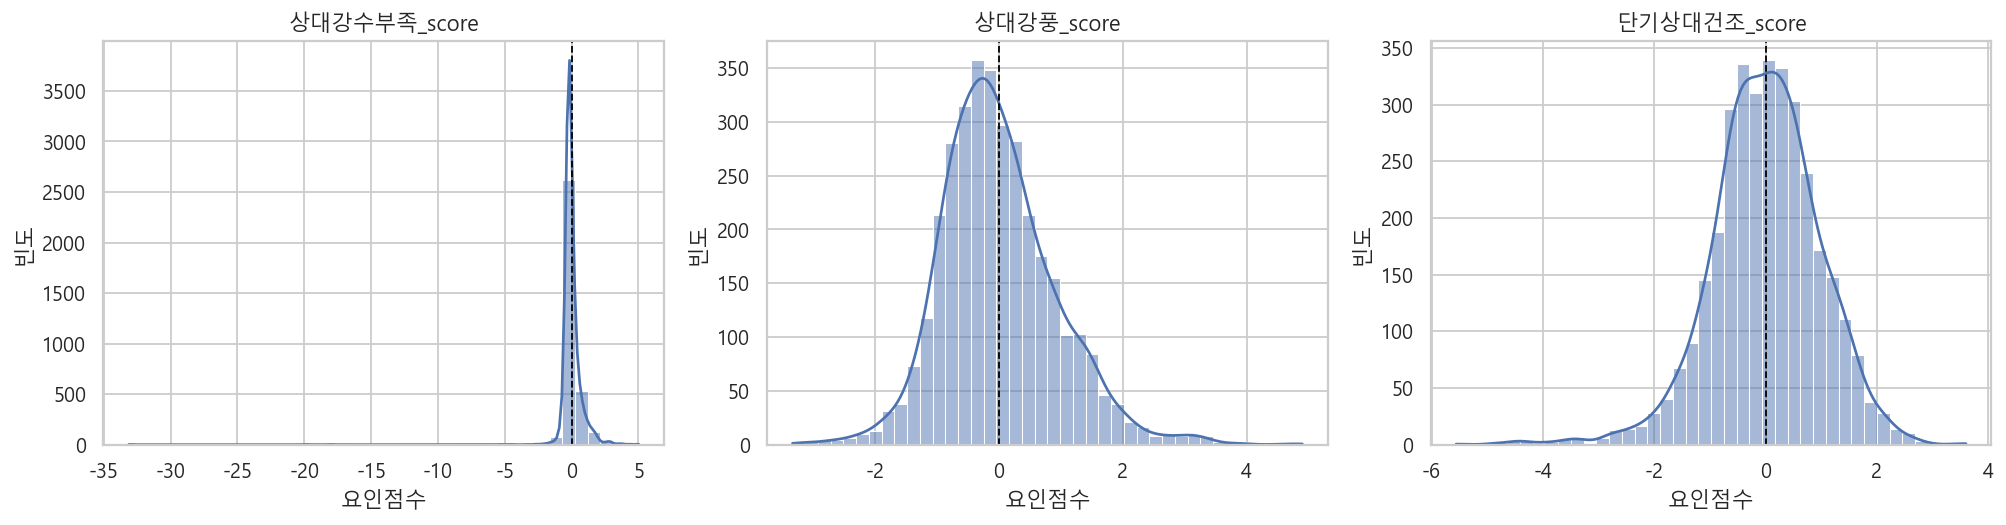

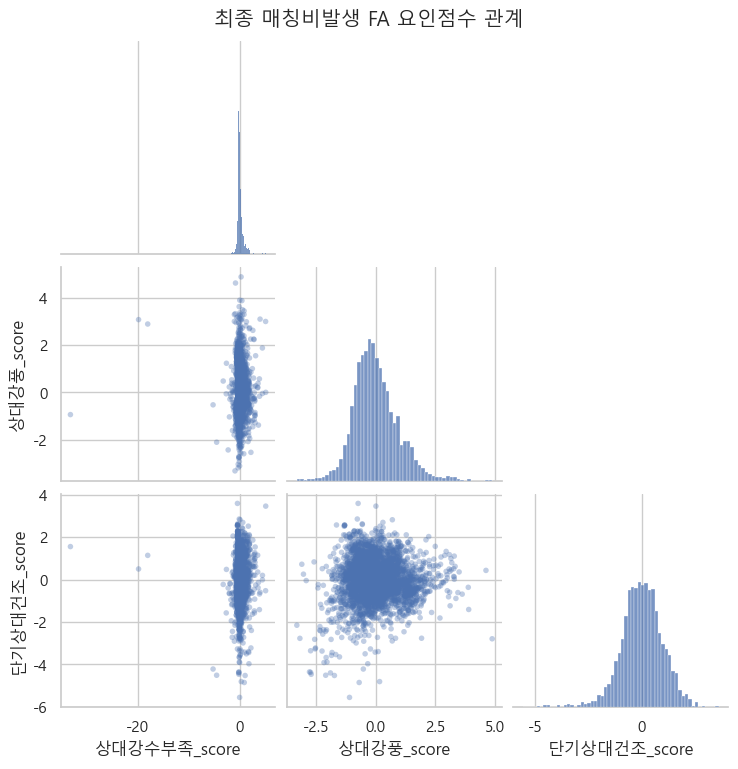

In [27]:
# 10-2. 요인점수 분포 시각화
score_cols = list(factor_scores_oriented.columns)

fig, axes = plt.subplots(1, len(score_cols), figsize=(5.2 * len(score_cols), 4.2), dpi=130)
if len(score_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, score_cols):
    sns.histplot(factor_scores_oriented[col], bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(col)
    ax.set_xlabel("요인점수")
    ax.set_ylabel("빈도")

plt.tight_layout()
plt.show()

score_pair_source = factor_scores_oriented.copy()
score_pair_source["fire_id"] = matched_factor_score_meta["fire_id"].values

pair_grid = sns.pairplot(
    score_pair_source[score_cols],
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.35, "s": 16, "edgecolor": "none"},
)
pair_grid.fig.suptitle("최종 매칭비발생 FA 요인점수 관계", y=1.02)
plt.show()


### 10-2. `D-3_최소습도_delta` 제거 민감도 확인

9번에서 `D-3_최소습도_delta`는 낮은 공통성과 약한 주적재를 보였다.
이 변수를 제거한 뒤 3요인 Varimax 해와 요인점수가 얼마나 달라지는지 확인한다.


In [28]:
# 10-3. D-3 최소습도 delta 제거 민감도 확인
LOW_COMMUNALITY_REVIEW_COL = "D-3_최소습도_위험방향_delta"

if LOW_COMMUNALITY_REVIEW_COL not in fa_rotation_Z.columns:
    raise KeyError(f"{LOW_COMMUNALITY_REVIEW_COL} 변수가 fa_rotation_Z에 없습니다.")

fa_rotation_Z_no_d3 = fa_rotation_Z.drop(columns=[LOW_COMMUNALITY_REVIEW_COL]).copy()

no_d3_model = FactorAnalyzer(n_factors=FINAL_N_FACTORS, rotation=FINAL_ROTATION, method="minres")
no_d3_model.fit(fa_rotation_Z_no_d3)

no_d3_factor_names = [f"F{i}" for i in range(1, FINAL_N_FACTORS + 1)]
no_d3_loadings = pd.DataFrame(
    no_d3_model.loadings_,
    index=fa_rotation_Z_no_d3.columns,
    columns=no_d3_factor_names,
)
no_d3_abs_loadings = no_d3_loadings.abs()
no_d3_communalities = pd.Series(
    no_d3_model.get_communalities(),
    index=fa_rotation_Z_no_d3.columns,
    name="공통성",
)
no_d3_uniquenesses = pd.Series(
    no_d3_model.get_uniquenesses(),
    index=fa_rotation_Z_no_d3.columns,
    name="고유성",
)
no_d3_variance, no_d3_prop_var, no_d3_cum_var = no_d3_model.get_factor_variance()
no_d3_variance_table = pd.DataFrame(
    {
        "요인": no_d3_factor_names,
        "SS_Loadings": no_d3_variance,
        "Proportion_Var": no_d3_prop_var,
        "Cumulative_Var": no_d3_cum_var,
    }
)

no_d3_primary_idx = no_d3_abs_loadings.to_numpy().argmax(axis=1)
no_d3_loading_detail = pd.DataFrame(
    {
        "변수": no_d3_loadings.index,
        "주요인": [no_d3_factor_names[idx] for idx in no_d3_primary_idx],
        "주적재량": no_d3_loadings.to_numpy()[np.arange(no_d3_loadings.shape[0]), no_d3_primary_idx],
        "주적재량_abs": no_d3_abs_loadings.max(axis=1).values,
        "적재량_0.30이상_개수": (no_d3_abs_loadings >= CROSS_LOADING_CUTOFF).sum(axis=1).values,
        "적재량_0.40이상_개수": (no_d3_abs_loadings >= PRIMARY_LOADING_CUTOFF).sum(axis=1).values,
        "공통성": no_d3_communalities.values,
        "고유성": no_d3_uniquenesses.values,
    }
)
no_d3_loading_detail["교차적재_후보"] = no_d3_loading_detail["적재량_0.30이상_개수"] >= 2
no_d3_loading_detail["약한_주적재"] = no_d3_loading_detail["주적재량_abs"] < PRIMARY_LOADING_CUTOFF
no_d3_loading_detail["낮은_공통성"] = no_d3_loading_detail["공통성"] < LOW_COMMUNALITY_CUTOFF

no_d3_summary = pd.DataFrame(
    [
        {
            "모형": "기본 10변수",
            "변수수": fa_rotation_Z.shape[1],
            "평균공통성": final_fa["summary"]["mean_communality"],
            "최저공통성": final_fa["summary"]["min_communality"],
            "누적설명분산": final_fa["summary"]["cumulative_variance"],
            "약한주적재수": final_fa["summary"]["weak_primary_loading_n"],
            "낮은공통성수": final_fa["summary"]["communality_lt_020_n"],
            "교차적재수": final_fa["summary"]["cross_loading_n"],
        },
        {
            "모형": "D-3 제거 9변수",
            "변수수": fa_rotation_Z_no_d3.shape[1],
            "평균공통성": float(no_d3_communalities.mean()),
            "최저공통성": float(no_d3_communalities.min()),
            "누적설명분산": float(no_d3_variance_table["Cumulative_Var"].iloc[-1]),
            "약한주적재수": int(no_d3_loading_detail["약한_주적재"].sum()),
            "낮은공통성수": int(no_d3_loading_detail["낮은_공통성"].sum()),
            "교차적재수": int(no_d3_loading_detail["교차적재_후보"].sum()),
        },
    ]
)

no_d3_raw_scores = pd.DataFrame(
    no_d3_model.transform(fa_rotation_Z_no_d3),
    index=fa_rotation_Z_no_d3.index,
    columns=[f"{factor}_score_raw" for factor in no_d3_factor_names],
)
no_d3_scores_oriented = pd.DataFrame(index=fa_rotation_Z_no_d3.index)
no_d3_orientation_rows = []

for factor in no_d3_factor_names:
    raw_col = f"{factor}_score_raw"
    score_name = FINAL_FACTOR_SCORE_NAME_MAP[factor]
    anchor_cols = [col for col in FINAL_FACTOR_ANCHORS[factor] if col in fa_rotation_Z_no_d3.columns]
    anchor_value = fa_rotation_Z_no_d3[anchor_cols].mean(axis=1)
    corr_with_anchor = no_d3_raw_scores[raw_col].corr(anchor_value)
    sign = 1 if pd.isna(corr_with_anchor) or corr_with_anchor >= 0 else -1
    no_d3_scores_oriented[score_name] = no_d3_raw_scores[raw_col] * sign
    no_d3_orientation_rows.append(
        {
            "요인": factor,
            "요인명": FINAL_FACTOR_NAME_MAP[factor],
            "요인점수": score_name,
            "anchor_변수": ", ".join(anchor_cols),
            "raw_score_anchor_corr": corr_with_anchor,
            "부호보정": sign,
        }
    )

no_d3_orientation = pd.DataFrame(no_d3_orientation_rows)
no_d3_score_correlations = pd.concat(
    [
        factor_scores_oriented.add_suffix("_기본"),
        no_d3_scores_oriented.add_suffix("_D3제거"),
    ],
    axis=1,
).corr().loc[
    [f"{col}_기본" for col in factor_scores_oriented.columns],
    [f"{col}_D3제거" for col in no_d3_scores_oriented.columns],
]

display(Markdown("### D-3 최소습도 제거 전후 모형 요약"))
display(no_d3_summary.round(4))
display(Markdown("### D-3 제거 모형 변수별 주적재량"))
display(no_d3_loading_detail.sort_values(["주요인", "주적재량_abs"], ascending=[True, False]).round(4))
display(Markdown("### D-3 제거 모형 요인점수 부호 보정"))
display(no_d3_orientation.round(4))
display(Markdown("### 기본 점수와 D-3 제거 점수의 상관"))
display(no_d3_score_correlations.round(4))

print("생성 객체:")
print("- fa_rotation_Z_no_d3")
print("- no_d3_model, no_d3_loadings, no_d3_loading_detail")
print("- no_d3_summary")
print("- no_d3_scores_oriented")
print("- no_d3_score_correlations")


### D-3 최소습도 제거 전후 모형 요약

,모형,변수수,평균공통성,최저공통성,누적설명분산,약한주적재수,낮은공통성수,교차적재수
0,기본 10변수,10,0.6346,0.1586,0.6346,1,1,0
1,D-3 제거 9변수,9,0.6861,0.3145,0.6861,0,0,1


### D-3 제거 모형 변수별 주적재량

,변수,주요인,주적재량,주적재량_abs,적재량_0.30이상_개수,적재량_0.40이상_개수,공통성,고유성,교차적재_후보,약한_주적재,낮은_공통성
8,D-1_강수량합_위험방향_delta,F1,0.8862,0.8862,1,1,0.7992,0.2008,False,False,False
6,직전24h_강수량합_위험방향_delta,F1,0.8838,0.8838,1,1,0.7821,0.2179,False,False,False
7,직전72h_강수량합_위험방향_delta,F1,0.8438,0.8438,1,1,0.7208,0.2792,False,False,False
3,발생시각_풍속_위험방향_delta,F2,0.8224,0.8224,1,1,0.6815,0.3185,False,False,False
4,직전24h_평균풍속_위험방향_delta,F2,0.7809,0.7809,1,1,0.6284,0.3716,False,False,False
5,발생일_최대순간풍속_위험방향_delta,F2,0.7687,0.7687,1,1,0.6000,0.4000,False,False,False
0,발생시각_습도_위험방향_delta,F2,0.4079,0.4079,2,1,0.3145,0.6855,True,False,False
1,직전24h_최소습도_위험방향_delta,F3,1.0054,1.0054,1,1,1.0293,-0.0293,False,False,False
2,D-1_최소습도_위험방향_delta,F3,0.7750,0.7750,1,1,0.6190,0.3810,False,False,False


### D-3 제거 모형 요인점수 부호 보정

,요인,요인명,요인점수,anchor_변수,raw_score_anchor_corr,부호보정
0,F1,상대강수부족,상대강수부족_score,"직전24h_강수량합_위험방향_delta, 직전72h_강수량합_위험방향_delta, ...",0.9957,1
1,F2,상대강풍,상대강풍_score,"직전24h_평균풍속_위험방향_delta, 발생시각_풍속_위험방향_delta, 발생일...",0.9908,1
2,F3,단기상대건조,단기상대건조_score,"직전24h_최소습도_위험방향_delta, D-1_최소습도_위험방향_delta",0.9157,1


### 기본 점수와 D-3 제거 점수의 상관

,상대강수부족_score_D3제거,상대강풍_score_D3제거,단기상대건조_score_D3제거
상대강수부족_score_기본,0.9998,-0.0100,0.0038
상대강풍_score_기본,-0.0124,0.9879,0.1653
단기상대건조_score_기본,0.0163,-0.0789,0.9701


생성 객체:
- fa_rotation_Z_no_d3
- no_d3_model, no_d3_loadings, no_d3_loading_detail
- no_d3_summary
- no_d3_scores_oriented
- no_d3_score_correlations


### 10-3. 다음 단계 판단 기준

10번 실행 후에는 아래 기준으로 최종 점수셋을 정한다.


In [29]:
# 10-4. 다음 단계 판단용 체크표
base_problem_n = int(
    final_loading_detail["약한_주적재"].sum()
    + final_loading_detail["낮은_공통성"].sum()
    + final_loading_detail["교차적재_후보"].sum()
)
no_d3_problem_n = int(
    no_d3_loading_detail["약한_주적재"].sum()
    + no_d3_loading_detail["낮은_공통성"].sum()
    + no_d3_loading_detail["교차적재_후보"].sum()
)

same_score_corr_diag = [
    no_d3_score_correlations.loc[f"{col}_기본", f"{col}_D3제거"]
    for col in factor_scores_oriented.columns
]
min_same_score_corr = float(np.nanmin(same_score_corr_diag))

factor_score_decision_check = pd.DataFrame(
    {
        "항목": [
            "기본 모형 문제 지표 수",
            "D-3 제거 모형 문제 지표 수",
            "동일 요인점수 최소 상관",
            "D-3 제거 후 평균공통성 변화",
            "D-3 제거 후 누적설명분산 변화",
            "권장 확인",
        ],
        "값": [
            base_problem_n,
            no_d3_problem_n,
            round(min_same_score_corr, 4),
            round(float(no_d3_summary.loc[1, "평균공통성"] - no_d3_summary.loc[0, "평균공통성"]), 4),
            round(float(no_d3_summary.loc[1, "누적설명분산"] - no_d3_summary.loc[0, "누적설명분산"]), 4),
            "동일 요인점수 상관이 높고 D-3 제거 모형 문제가 줄면 D-3 제거 점수셋 검토",
        ],
    }
)

display(Markdown("### 최종 점수셋 판단 체크표"))
display(factor_score_decision_check)

print("다음 단계:")
print("- 실행 결과 해석 후 기본 10변수 점수셋 또는 D-3 제거 9변수 점수셋 중 하나를 확정한다.")
print("- 확정된 요인점수를 기후지형유형, addr_type, 산불위험계절 등 메타데이터별로 비교한다.")


### 최종 점수셋 판단 체크표

,항목,값
0,기본 모형 문제 지표 수,2
1,D-3 제거 모형 문제 지표 수,1
2,동일 요인점수 최소 상관,0.9701
3,D-3 제거 후 평균공통성 변화,0.0515
4,D-3 제거 후 누적설명분산 변화,0.0515
5,권장 확인,동일 요인점수 상관이 높고 D-3 제거 모형 문제가 줄면 D-3 제거 점수셋 검토


다음 단계:
- 실행 결과 해석 후 기본 10변수 점수셋 또는 D-3 제거 9변수 점수셋 중 하나를 확정한다.
- 확정된 요인점수를 기후지형유형, addr_type, 산불위험계절 등 메타데이터별로 비교한다.


### 10번 실행 결과 해석: 최종 요인점수와 D-3 민감도

9번에서 선택한 `varimax` 3요인 해를 기준으로 요인점수를 생성했다.
요인점수는 각 요인의 anchor 변수와 양의 상관을 갖도록 부호를 보정했으며, 세 요인 모두 부호 반전 없이 원 부호를 유지했다.

#### 최종 요인 정의와 부호 보정
최종 요인은 `상대강수부족`, `상대강풍`, `단기상대건조` 3개이다.
부호 보정 기준인 anchor 평균과 원 요인점수의 상관은 모두 매우 높다.
`상대강수부족_score`는 anchor와 `0.9955`, `상대강풍_score`는 `0.9708`, `단기상대건조_score`는 `0.9732`의 상관을 보인다.
따라서 세 점수는 모두 값이 클수록 같은 기상셀·월·시간대 평상시보다 산불 위험 방향으로 더 많이 이탈한 것으로 해석할 수 있다.

| 요인 | 요인점수 | anchor 상관 | 해석 |
| --- | --- | ---: | --- |
| `F1` | `상대강수부족_score` | `0.9955` | 평상시 대비 최근 강수량 부족 |
| `F2` | `상대강풍_score` | `0.9708` | 평상시 대비 발생시각·직전24h·당일 돌풍 강화 |
| `F3` | `단기상대건조_score` | `0.9732` | 평상시 대비 직전24h 및 전일 최소습도 저하 |

#### 요인점수 분포 해석
`상대강수부족_score`는 매우 비대칭적인 분포이다.
중앙값은 `-0.1445`, 95퍼센타일은 `1.1733`, 99퍼센타일은 `2.3886`이지만 최솟값은 `-33.1280`이다.
즉 대부분의 사례는 0 근처에 몰려 있으나, 일부 산불 시점은 매칭 비발생 평균보다 강수량이 훨씬 많아 강수부족 점수가 극단적으로 낮게 계산된다.
히스토그램에서도 거의 모든 사례가 0 주변에 밀집하고 긴 왼쪽 꼬리가 나타난다.
따라서 이 점수는 최종 메타데이터 비교에서 평균보다 중앙값, 분위수, 극단값 제외 민감도를 함께 확인해야 한다.

`상대강풍_score`는 세 점수 중 가장 일반적인 연속형 분포에 가깝다.
중앙값은 `-0.1039`, 95퍼센타일은 `1.5992`, 99퍼센타일은 `2.7396`, 최댓값은 `4.8995`이다.
히스토그램은 약간 오른쪽 꼬리가 있으며, 일부 강풍 산불 사례가 높은 점수 영역을 형성한다.
이는 앞선 해석처럼 강풍이 모든 산불에서 보편적으로 높아지는 조건이라기보다, 특정 기후·계절·지역에서 강하게 작동하는 동적 트리거일 가능성을 시사한다.

`단기상대건조_score`는 대체로 0 주변의 비교적 안정적인 분포를 보인다.
중앙값은 `0.0172`, 95퍼센타일은 `1.5494`, 99퍼센타일은 `2.1383`, 최솟값은 `-5.5589`이다.
왼쪽 꼬리가 일부 존재하지만 `상대강수부족_score`처럼 극단적으로 치우치지는 않는다.
따라서 단기 건조 점수는 메타데이터별 비교에 바로 사용할 수 있는 편이다.

| 요인점수 | 중앙값 | p95 | p99 | 최솟값 | 최댓값 |
| --- | ---: | ---: | ---: | ---: | ---: |
| `상대강수부족_score` | `-0.1445` | `1.1733` | `2.3886` | `-33.1280` | `5.0231` |
| `상대강풍_score` | `-0.1039` | `1.5992` | `2.7396` | `-3.3260` | `4.8995` |
| `단기상대건조_score` | `0.0172` | `1.5494` | `2.1383` | `-5.5589` | `3.6016` |

#### 요인점수와 입력 delta 변수 상관
요인점수와 입력 변수의 상관은 요인 해석과 잘 맞는다.
`상대강수부족_score`는 `직전24h_강수량합_delta`와 `0.931`, `직전72h_강수량합_delta`와 `0.885`, `D-1_강수량합_delta`와 `0.926`의 높은 상관을 보인다.
다른 습도·풍속 변수와의 상관은 대부분 낮아 강수부족 축이 독립적으로 잘 분리되었다.

`상대강풍_score`는 `발생시각_풍속_delta`와 `0.854`, `직전24h_평균풍속_delta`와 `0.875`, `발생일_최대순간풍속_delta`와 `0.793`의 높은 상관을 보인다.
동시에 `발생시각_습도_delta`와도 `0.504`의 상관을 보인다.
이는 `상대강풍_score`가 순수 풍속만이 아니라 발생 순간의 저습-강풍 복합 이탈을 일부 포함한다는 9번 loading 해석과 일치한다.

`단기상대건조_score`는 `직전24h_최소습도_delta`와 `0.965`, `D-1_최소습도_delta`와 `0.883`의 매우 높은 상관을 보인다.
`D-3_최소습도_delta`와의 상관은 `0.359`로 낮아, 이 점수는 장기 선행습도보다 단기 최소습도 이탈을 대표한다.

#### 요인점수 관계 플롯 해석
pairplot에서도 세 점수는 대체로 분리되어 있다.
`상대강수부족_score`는 대부분 0 주변에 몰려 있고 일부 극단 음수 사례가 있어 다른 점수와의 산점도에서도 세로로 긴 꼬리 형태를 만든다.
`상대강풍_score`와 `단기상대건조_score` 사이에는 약한 양의 관계가 보이지만, 강하게 같은 축으로 합쳐질 정도는 아니다.
따라서 이후 메타데이터별 비교에서는 세 점수를 별도 축으로 유지하는 것이 타당하다.

#### D-3 최소습도 제거 민감도
`D-3_최소습도_delta`를 제거하면 평균공통성은 `0.6346`에서 `0.6861`로 `+0.0515` 개선되고, 최저공통성도 `0.1586`에서 `0.3145`로 개선된다.
약한 주적재 변수와 낮은 공통성 변수는 각각 `1개`에서 `0개`로 줄어든다.
또한 기본 점수와 D-3 제거 점수의 동일 요인 상관은 `상대강수부족 0.9998`, `상대강풍 0.9879`, `단기상대건조 0.9701`로 매우 높다.
즉 D-3 제거 여부와 관계없이 세 요인점수의 전체 순위 구조는 거의 유지된다.

그러나 D-3 제거 모형은 별도의 문제가 있다.
`직전24h_최소습도_delta`의 주적재량이 `1.0054`, 공통성이 `1.0293`, 고유성이 `-0.0293`으로 Heywood 징후를 보인다.
또한 `발생시각_습도_delta`가 교차적재 후보가 되어 교차적재 수가 `0개`에서 `1개`로 늘어난다.
따라서 D-3 제거 모형은 공통성 평균은 좋아지지만, 최종 기본 모형으로 쓰기에는 안정성이 떨어진다.

| 모형 | 평균공통성 | 최저공통성 | 약한주적재 | 낮은공통성 | 교차적재 | 특이사항 |
| --- | ---: | ---: | ---: | ---: | ---: | --- |
| 기본 10변수 | `0.6346` | `0.1586` | `1` | `1` | `0` | D-3 최소습도 설명력 낮음 |
| D-3 제거 9변수 | `0.6861` | `0.3145` | `0` | `0` | `1` | 직전24h 최소습도 Heywood 징후 |

#### 10번 결론 및 다음 단계
최종 점수셋은 기본 10변수 Varimax 3요인 점수셋을 유지한다.
이유는 D-3 제거 모형이 평균공통성을 개선하더라도 Heywood 징후와 교차적재를 새로 만들기 때문이다.
기본 모형은 `D-3_최소습도_delta` 하나의 낮은 공통성 문제가 있지만, 교차적재가 없고 음의 고유성도 없어 더 안정적이다.

다만 해석에서는 `D-3_최소습도_delta`를 핵심 변수로 보지 않는다.
`단기상대건조_score`는 `직전24h_최소습도_delta`와 `D-1_최소습도_delta` 중심의 단기 건조 이탈 점수로 해석한다.
`상대강수부족_score`는 극단 음수 사례가 있으므로, 다음 메타데이터별 비교에서는 평균과 중앙값을 함께 보고 필요하면 극단값 민감도도 확인한다.

다음 단계는 확정된 3개 요인점수를 메타데이터별로 비교하는 것이다.
우선순위는 `기후지형유형`, `기후지형_번지유형`, `addr_type`, `산불위험계절` 순서로 둔다.


## 11. 메타데이터별 최종 요인점수 비교

기존 `2026-06-08_FA.ipynb`의 후반 흐름처럼 요인점수를 메타데이터별로 비교한다.
다만 이번 노트북의 요인점수는 공간 입지 요인이 아니라, 같은 기상셀·월·시간대 평상시 대비 기상 이탈 요인이다.

따라서 해석 우선순위는 다음처럼 둔다.
- `기후지형유형`: 상대강풍과 상대건조가 영동/산간/내륙 기후 차이를 보이는지 확인
- `기후지형_번지유형`: 기후지형에 번지유형이 결합될 때 기상 이탈 차이가 더 커지는지 확인
- `addr_type`: 번지유형 자체가 기상 이탈을 설명하는지 확인. 기존 절대값 FA와 달리 약할 가능성이 높다.
- `산불위험계절`: 상대강풍·단기상대건조가 계절성 트리거로 움직이는지 확인


In [30]:
# 11-0. 메타데이터별 비교 입력 준비
required_score_objects = ["matched_factor_scores", "factor_scores_oriented"]
missing_score_objects = [name for name in required_score_objects if name not in globals()]
if missing_score_objects:
    raise NameError(f"10번 섹션을 먼저 실행해야 합니다. 누락 객체: {missing_score_objects}")

MATCHED_SCORE_COLS = [
    "상대강수부족_score",
    "상대강풍_score",
    "단기상대건조_score",
]
missing_score_cols = [col for col in MATCHED_SCORE_COLS if col not in matched_factor_scores.columns]
if missing_score_cols:
    raise KeyError(f"matched_factor_scores에 요인점수 컬럼이 없습니다: {missing_score_cols}")

matched_factor_meta_df = matched_factor_scores.copy()
for col in MATCHED_SCORE_COLS:
    matched_factor_meta_df[col] = pd.to_numeric(matched_factor_meta_df[col], errors="coerce")

rain_score_col = "상대강수부족_score"
rain_score_z = (
    matched_factor_meta_df[rain_score_col] - matched_factor_meta_df[rain_score_col].mean()
) / matched_factor_meta_df[rain_score_col].std(ddof=0)
matched_factor_meta_df["상대강수부족_z"] = rain_score_z
matched_factor_meta_df["상대강수부족_극단음수_z3"] = rain_score_z <= -3
matched_factor_meta_df["상대강수부족_극단양수_z3"] = rain_score_z >= 3

MATCHED_META_COMPARE_COLS = [
    "기후지형유형",
    "기후지형_번지유형",
    "addr_type",
    "산불위험계절",
]
available_matched_meta_cols = [col for col in MATCHED_META_COMPARE_COLS if col in matched_factor_meta_df.columns]

meta_compare_input_summary = pd.DataFrame(
    {
        "항목": [
            "요인점수 행 수",
            "요인점수 수",
            "비교 가능 메타데이터 수",
            "상대강수부족 z<=-3 사례 수",
            "상대강수부족 z>=+3 사례 수",
        ],
        "값": [
            len(matched_factor_meta_df),
            len(MATCHED_SCORE_COLS),
            len(available_matched_meta_cols),
            int(matched_factor_meta_df["상대강수부족_극단음수_z3"].sum()),
            int(matched_factor_meta_df["상대강수부족_극단양수_z3"].sum()),
        ],
    }
)

display(Markdown("### 메타데이터별 비교 입력 요약"))
display(meta_compare_input_summary)
display(Markdown("### 비교 대상 요인점수"))
display(pd.DataFrame({"요인점수": MATCHED_SCORE_COLS}))


### 메타데이터별 비교 입력 요약

,항목,값
0,요인점수 행 수,3395
1,요인점수 수,3
2,비교 가능 메타데이터 수,4
3,상대강수부족 z<=-3 사례 수,6
4,상대강수부족 z>=+3 사례 수,20


### 비교 대상 요인점수

,요인점수
0,상대강수부족_score
1,상대강풍_score
2,단기상대건조_score


### 11-1. 공통 함수

그룹별 표본 수, 평균차/중앙값차, Kruskal-Wallis 또는 Mann-Whitney 검정, 효과크기, heatmap을 공통 함수로 계산한다.


In [31]:
# 11-1. 메타데이터별 비교 공통 함수
def matched_benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)
    adjusted = np.full(n, np.nan)
    valid_mask = ~np.isnan(p_values)
    valid_p = p_values[valid_mask]
    if len(valid_p) == 0:
        return adjusted

    order = np.argsort(valid_p)
    ranked = valid_p[order]
    adj = ranked * len(valid_p) / (np.arange(len(valid_p)) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    valid_indices = np.where(valid_mask)[0]
    adjusted[valid_indices[order]] = adj
    return adjusted


def matched_rank_biserial(x, y):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
    y = pd.to_numeric(pd.Series(y), errors="coerce").dropna()
    if len(x) == 0 or len(y) == 0:
        return np.nan
    u_stat, _ = stats.mannwhitneyu(x, y, alternative="two-sided")
    return (2 * u_stat / (len(x) * len(y))) - 1


def matched_group_order(df, meta_col, preferred_order=None):
    observed = pd.Series(df[meta_col].dropna().astype(str).unique()).tolist()
    if preferred_order is None:
        return observed
    order = [item for item in preferred_order if item in observed]
    order.extend([item for item in observed if item not in order])
    return order


def summarize_matched_scores_by_meta(df, meta_col, score_cols, group_order=None, min_n=10):
    source = df[[meta_col] + score_cols].copy()
    source = source.dropna(subset=[meta_col])
    source[meta_col] = source[meta_col].astype(str)

    order = matched_group_order(source, meta_col, group_order)
    count_table = (
        source.groupby(meta_col, observed=False)
        .size()
        .reindex(order)
        .dropna()
        .astype(int)
        .reset_index(name="n")
    )
    count_table["비율"] = count_table["n"] / count_table["n"].sum()

    rows = []
    for group in count_table[meta_col]:
        group_df = source[source[meta_col] == group]
        for score_col in score_cols:
            values = pd.to_numeric(group_df[score_col], errors="coerce").dropna()
            global_values = pd.to_numeric(source[score_col], errors="coerce").dropna()
            global_mean = global_values.mean()
            global_median = global_values.median()
            global_std = global_values.std(ddof=0)
            if len(values) == 0 or global_std == 0 or pd.isna(global_std):
                mean_diff_sd = np.nan
                median_diff_sd = np.nan
            else:
                mean_diff_sd = (values.mean() - global_mean) / global_std
                median_diff_sd = (values.median() - global_median) / global_std
            rows.append(
                {
                    "메타데이터": meta_col,
                    "그룹": group,
                    "요인점수": score_col,
                    "n": len(values),
                    "평균": values.mean(),
                    "중앙값": values.median(),
                    "표준편차": values.std(ddof=1),
                    "p25": values.quantile(0.25),
                    "p75": values.quantile(0.75),
                    "평균차_sd": mean_diff_sd,
                    "중앙값차_sd": median_diff_sd,
                }
            )

    summary_long = pd.DataFrame(rows)
    summary_long = summary_long[summary_long["n"] >= min_n].copy()
    mean_wide = summary_long.pivot(index="그룹", columns="요인점수", values="평균차_sd").reindex(order)
    median_wide = summary_long.pivot(index="그룹", columns="요인점수", values="중앙값차_sd").reindex(order)
    return count_table, summary_long, mean_wide, median_wide


def test_matched_scores_by_meta(df, meta_col, score_cols, group_order=None, min_n=10):
    source = df[[meta_col] + score_cols].copy()
    source = source.dropna(subset=[meta_col])
    source[meta_col] = source[meta_col].astype(str)
    order = matched_group_order(source, meta_col, group_order)

    rows = []
    pair_rows = []
    for score_col in score_cols:
        group_values = []
        group_names = []
        for group in order:
            values = pd.to_numeric(source.loc[source[meta_col] == group, score_col], errors="coerce").dropna()
            if len(values) >= min_n:
                group_values.append(values)
                group_names.append(group)

        if len(group_values) < 2:
            rows.append(
                {
                    "메타데이터": meta_col,
                    "요인점수": score_col,
                    "검정": "그룹부족",
                    "그룹수": len(group_values),
                    "statistic": np.nan,
                    "p_value": np.nan,
                    "effect_size": np.nan,
                    "effect_label": "계산불가",
                }
            )
            continue

        if len(group_values) == 2:
            statistic, p_value = stats.mannwhitneyu(group_values[0], group_values[1], alternative="two-sided")
            effect_size = matched_rank_biserial(group_values[0], group_values[1])
            test_name = "Mann-Whitney"
            effect_label = "rank_biserial"
        else:
            statistic, p_value = stats.kruskal(*group_values)
            n_total = sum(len(values) for values in group_values)
            k = len(group_values)
            effect_size = max(0, (statistic - k + 1) / (n_total - k)) if n_total > k else np.nan
            test_name = "Kruskal-Wallis"
            effect_label = "epsilon_sq"

        rows.append(
            {
                "메타데이터": meta_col,
                "요인점수": score_col,
                "검정": test_name,
                "그룹수": len(group_values),
                "statistic": statistic,
                "p_value": p_value,
                "effect_size": effect_size,
                "effect_label": effect_label,
            }
        )

        for i in range(len(group_values)):
            for j in range(i + 1, len(group_values)):
                x = group_values[i]
                y = group_values[j]
                u_stat, pair_p = stats.mannwhitneyu(x, y, alternative="two-sided")
                pair_rows.append(
                    {
                        "메타데이터": meta_col,
                        "요인점수": score_col,
                        "그룹1": group_names[i],
                        "그룹2": group_names[j],
                        "그룹1_n": len(x),
                        "그룹2_n": len(y),
                        "그룹1_평균": x.mean(),
                        "그룹2_평균": y.mean(),
                        "평균차": x.mean() - y.mean(),
                        "그룹1_중앙값": x.median(),
                        "그룹2_중앙값": y.median(),
                        "중앙값차": x.median() - y.median(),
                        "u_stat": u_stat,
                        "p_value": pair_p,
                        "rank_biserial": matched_rank_biserial(x, y),
                    }
                )

    test_table = pd.DataFrame(rows)
    if len(test_table) > 0:
        test_table["p_adj_fdr"] = matched_benjamini_hochberg(test_table["p_value"].to_numpy())

    pair_table = pd.DataFrame(pair_rows)
    if len(pair_table) > 0:
        pair_table["p_adj_fdr"] = matched_benjamini_hochberg(pair_table["p_value"].to_numpy())
        pair_table["abs_rank_biserial"] = pair_table["rank_biserial"].abs()
        pair_table = pair_table.sort_values(["요인점수", "abs_rank_biserial"], ascending=[True, False])

    return test_table, pair_table


def summarize_rain_extremes_by_meta(df, meta_col, group_order=None):
    if "상대강수부족_극단음수_z3" not in df.columns:
        return pd.DataFrame()
    source = df[[meta_col, "상대강수부족_극단음수_z3", "상대강수부족_극단양수_z3"]].dropna(subset=[meta_col]).copy()
    source[meta_col] = source[meta_col].astype(str)
    order = matched_group_order(source, meta_col, group_order)
    out = (
        source.groupby(meta_col, observed=False)
        .agg(
            n=(meta_col, "size"),
            강수부족_극단음수수=("상대강수부족_극단음수_z3", "sum"),
            강수부족_극단양수수=("상대강수부족_극단양수_z3", "sum"),
        )
        .reindex(order)
        .dropna()
        .reset_index()
    )
    out["강수부족_극단음수비율"] = out["강수부족_극단음수수"] / out["n"]
    out["강수부족_극단양수비율"] = out["강수부족_극단양수수"] / out["n"]
    return out


def plot_matched_meta_heatmaps(meta_col, mean_wide, median_wide):
    fig_height = max(3.6, 0.45 * len(mean_wide))
    fig, axes = plt.subplots(1, 2, figsize=(15, fig_height), dpi=130)
    sns.heatmap(
        mean_wide,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        linewidths=0.4,
        cbar_kws={"label": "평균차(sd)"},
        ax=axes[0],
    )
    axes[0].set_title(f"{meta_col}별 평균차(sd)")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")

    sns.heatmap(
        median_wide,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        linewidths=0.4,
        cbar_kws={"label": "중앙값차(sd)"},
        ax=axes[1],
    )
    axes[1].set_title(f"{meta_col}별 중앙값차(sd)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")
    plt.tight_layout()
    plt.show()


def run_matched_meta_factor_analysis(meta_col, group_order=None, min_n=10, top_pair_n=20):
    if meta_col not in matched_factor_meta_df.columns:
        raise KeyError(f"{meta_col} 컬럼이 matched_factor_meta_df에 없습니다.")

    count_table, summary_long, mean_wide, median_wide = summarize_matched_scores_by_meta(
        matched_factor_meta_df,
        meta_col,
        MATCHED_SCORE_COLS,
        group_order=group_order,
        min_n=min_n,
    )
    test_table, pair_table = test_matched_scores_by_meta(
        matched_factor_meta_df,
        meta_col,
        MATCHED_SCORE_COLS,
        group_order=group_order,
        min_n=min_n,
    )
    rain_extreme_table = summarize_rain_extremes_by_meta(
        matched_factor_meta_df,
        meta_col,
        group_order=group_order,
    )

    display(Markdown(f"### `{meta_col}` 그룹 수"))
    display(count_table)
    display(Markdown(f"### `{meta_col}` 요인점수 요약"))
    display(summary_long.round(4))
    display(Markdown(f"### `{meta_col}` 검정 결과"))
    display(test_table.round(4))

    if len(pair_table) > 0:
        display(Markdown(f"### `{meta_col}` 쌍별 비교 상위 {top_pair_n}개"))
        display(pair_table.head(top_pair_n).round(4))

    if len(rain_extreme_table) > 0:
        display(Markdown(f"### `{meta_col}` 상대강수부족 극단값 분포"))
        display(rain_extreme_table.round(4))

    plot_matched_meta_heatmaps(meta_col, mean_wide, median_wide)

    return {
        "count": count_table,
        "summary_long": summary_long,
        "mean_wide": mean_wide,
        "median_wide": median_wide,
        "test": test_table,
        "pairwise": pair_table,
        "rain_extreme": rain_extreme_table,
    }


### 11-2. 기후지형유형별 요인점수 비교

확인 질문:
- `영동 해안형`은 평상시 대비 `상대강풍_score`가 높은가?
- `고지·산간형` 또는 `영서 내륙형`은 상대건조·강수부족 이탈이 다른가?
- 강수부족 점수의 극단값이 특정 기후지형에 집중되는가?


### `기후지형유형` 그룹 수

,기후지형유형,n,비율
0,영동 해안형,1218,0.358763
1,영서 내륙형,1556,0.458321
2,고지·산간형,621,0.182916


### `기후지형유형` 요인점수 요약

,메타데이터,그룹,요인점수,n,평균,중앙값,표준편차,p25,p75,평균차_sd,중앙값차_sd
0,기후지형유형,영동 해안형,상대강수부족_score,1218,0.0366,-0.1348,0.9632,-0.2542,0.2410,0.0384,0.0102
1,기후지형유형,영동 해안형,상대강풍_score,1218,0.1297,0.1683,0.9181,-0.3391,0.6148,0.1400,0.2939
2,기후지형유형,영동 해안형,단기상대건조_score,1218,0.0646,0.0532,1.0723,-0.5254,0.7270,0.0658,0.0367
3,기후지형유형,영서 내륙형,상대강수부족_score,1556,0.0010,-0.1575,1.0725,-0.2844,0.1110,0.0011,-0.0136
4,기후지형유형,영서 내륙형,상대강풍_score,1556,-0.0768,-0.2334,0.8673,-0.6716,0.3313,-0.0829,-0.1398
5,기후지형유형,영서 내륙형,단기상대건조_score,1556,-0.0445,-0.0360,0.9336,-0.6154,0.5185,-0.0454,-0.0542
6,기후지형유형,고지·산간형,상대강수부족_score,621,-0.0744,-0.1233,0.5084,-0.2774,0.0816,-0.0781,0.0223
7,기후지형유형,고지·산간형,상대강풍_score,621,-0.0619,-0.3075,1.0509,-0.7306,0.6270,-0.0668,-0.2199
8,기후지형유형,고지·산간형,단기상대건조_score,621,-0.0151,0.0659,0.9035,-0.5730,0.6347,-0.0154,0.0497


### `기후지형유형` 검정 결과

,메타데이터,요인점수,검정,그룹수,statistic,p_value,effect_size,effect_label,p_adj_fdr
0,기후지형유형,상대강수부족_score,Kruskal-Wallis,3,16.2305,0.0003,0.0042,epsilon_sq,0.0004
1,기후지형유형,상대강풍_score,Kruskal-Wallis,3,95.0085,0.0000,0.0274,epsilon_sq,0.0000
2,기후지형유형,단기상대건조_score,Kruskal-Wallis,3,13.4259,0.0012,0.0034,epsilon_sq,0.0012


### `기후지형유형` 쌍별 비교 상위 18개

,메타데이터,요인점수,그룹1,그룹2,그룹1_n,그룹2_n,그룹1_평균,그룹2_평균,평균차,그룹1_중앙값,그룹2_중앙값,중앙값차,u_stat,p_value,rank_biserial,p_adj_fdr,abs_rank_biserial
6,기후지형유형,단기상대건조_score,영동 해안형,영서 내륙형,1218,1556,0.0646,-0.0445,0.1091,0.0532,-0.0360,0.0892,1023872.0,0.0003,0.0805,0.0006,0.0805
7,기후지형유형,단기상대건조_score,영동 해안형,고지·산간형,1218,621,0.0646,-0.0151,0.0796,0.0532,0.0659,-0.0127,393850.0,0.1459,0.0414,0.1876,0.0414
8,기후지형유형,단기상대건조_score,영서 내륙형,고지·산간형,1556,621,-0.0445,-0.0151,-0.0294,-0.0360,0.0659,-0.1020,463322.0,0.1346,-0.0410,0.1876,0.0410
0,기후지형유형,상대강수부족_score,영동 해안형,영서 내륙형,1218,1556,0.0366,0.0010,0.0356,-0.1348,-0.1575,0.0227,1026559.0,0.0002,0.0833,0.0005,0.0833
1,기후지형유형,상대강수부족_score,영동 해안형,고지·산간형,1218,621,0.0366,-0.0744,0.1110,-0.1348,-0.1233,-0.0115,409489.0,0.0037,0.0828,0.0066,0.0828
2,기후지형유형,상대강수부족_score,영서 내륙형,고지·산간형,1556,621,0.0010,-0.0744,0.0754,-0.1575,-0.1233,-0.0342,479661.0,0.7929,-0.0072,0.7929,0.0072
3,기후지형유형,상대강풍_score,영동 해안형,영서 내륙형,1218,1556,0.1297,-0.0768,0.2065,0.1683,-0.2334,0.4017,1139446.0,0.0000,0.2024,0.0000,0.2024
4,기후지형유형,상대강풍_score,영동 해안형,고지·산간형,1218,621,0.1297,-0.0619,0.1916,0.1683,-0.3075,0.4758,452828.0,0.0000,0.1974,0.0000,0.1974
5,기후지형유형,상대강풍_score,영서 내륙형,고지·산간형,1556,621,-0.0768,-0.0619,-0.0149,-0.2334,-0.3075,0.0742,497177.0,0.2891,0.0291,0.3253,0.0291


### `기후지형유형` 상대강수부족 극단값 분포

,기후지형유형,n,강수부족_극단음수수,강수부족_극단양수수,강수부족_극단음수비율,강수부족_극단양수비율
0,영동 해안형,1218,4,2,0.0033,0.0016
1,영서 내륙형,1556,1,17,0.0006,0.0109
2,고지·산간형,621,1,1,0.0016,0.0016


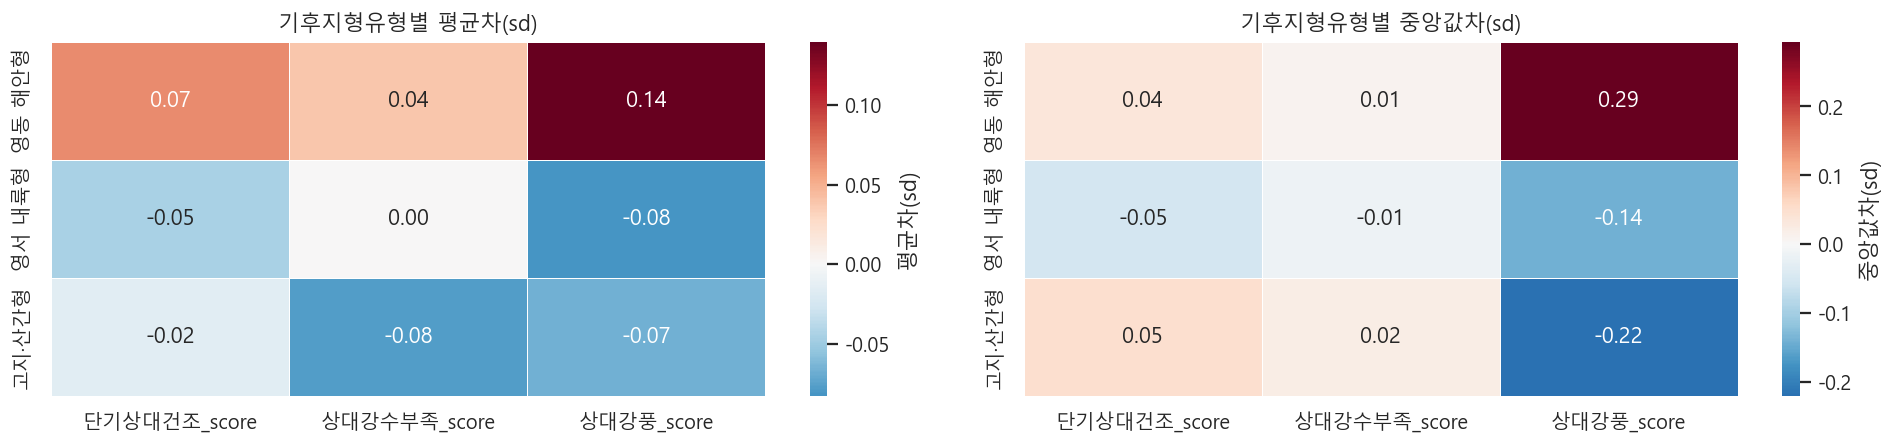

In [32]:
# 11-2. 기후지형유형별 요인점수 비교
climate_type_order = [item for item in TYPE_ORDER if item in matched_factor_meta_df["기후지형유형"].astype(str).unique()]

matched_climate_type_result = run_matched_meta_factor_analysis(
    "기후지형유형",
    group_order=climate_type_order,
    min_n=10,
    top_pair_n=18,
)


### 11-3. 기후지형_번지유형별 요인점수 비교

기후지형에 번지유형을 결합했을 때 상대강풍·상대건조 이탈 패턴이 더 선명해지는지 확인한다.


### `기후지형_번지유형` 그룹 수

,기후지형_번지유형,n,비율
0,영동 해안형 / 일반번지,972,0.286303
1,영동 해안형 / 임야번지(산),246,0.072459
2,고지·산간형 / 일반번지,412,0.121355
3,고지·산간형 / 임야번지(산),209,0.061561
4,영서 내륙형 / 일반번지,1227,0.361414
5,영서 내륙형 / 임야번지(산),329,0.096907


### `기후지형_번지유형` 요인점수 요약

,메타데이터,그룹,요인점수,n,평균,중앙값,표준편차,p25,p75,평균차_sd,중앙값차_sd
0,기후지형_번지유형,영동 해안형 / 일반번지,상대강수부족_score,972,0.0546,-0.1071,1.0513,-0.2440,0.2803,0.0573,0.0393
1,기후지형_번지유형,영동 해안형 / 일반번지,상대강풍_score,972,0.0912,0.1094,0.9155,-0.3642,0.5395,0.0985,0.2303
2,기후지형_번지유형,영동 해안형 / 일반번지,단기상대건조_score,972,-0.0407,-0.0341,1.0311,-0.5854,0.6045,-0.0415,-0.0523
3,기후지형_번지유형,영동 해안형 / 임야번지(산),상대강수부족_score,246,-0.0344,-0.1999,0.4712,-0.2949,0.0591,-0.0360,-0.0581
4,기후지형_번지유형,영동 해안형 / 임야번지(산),상대강풍_score,246,0.2816,0.4193,0.9144,-0.2407,0.8004,0.3041,0.5649
5,기후지형_번지유형,영동 해안형 / 임야번지(산),단기상대건조_score,246,0.4805,0.5339,1.1314,-0.2599,1.3149,0.4896,0.5266
6,기후지형_번지유형,고지·산간형 / 일반번지,상대강수부족_score,412,-0.1076,-0.1683,0.4989,-0.2944,0.0605,-0.1129,-0.0250
7,기후지형_번지유형,고지·산간형 / 일반번지,상대강풍_score,412,0.0110,-0.2217,1.1269,-0.7434,0.7495,0.0118,-0.1272
8,기후지형_번지유형,고지·산간형 / 일반번지,단기상대건조_score,412,0.1043,0.1330,0.8471,-0.3841,0.7099,0.1063,0.1180
9,기후지형_번지유형,고지·산간형 / 임야번지(산),상대강수부족_score,209,-0.0090,-0.0818,0.5217,-0.1974,0.1464,-0.0094,0.0659


### `기후지형_번지유형` 검정 결과

,메타데이터,요인점수,검정,그룹수,statistic,p_value,effect_size,effect_label,p_adj_fdr
0,기후지형_번지유형,상대강수부족_score,Kruskal-Wallis,6,78.4522,0.0,0.0217,epsilon_sq,0.0
1,기후지형_번지유형,상대강풍_score,Kruskal-Wallis,6,111.0975,0.0,0.0313,epsilon_sq,0.0
2,기후지형_번지유형,단기상대건조_score,Kruskal-Wallis,6,97.7398,0.0,0.0274,epsilon_sq,0.0


### `기후지형_번지유형` 쌍별 비교 상위 24개

,메타데이터,요인점수,그룹1,그룹2,그룹1_n,그룹2_n,그룹1_평균,그룹2_평균,평균차,그룹1_중앙값,그룹2_중앙값,중앙값차,u_stat,p_value,rank_biserial,p_adj_fdr,abs_rank_biserial
38,기후지형_번지유형,단기상대건조_score,영동 해안형 / 임야번지(산),영서 내륙형 / 임야번지(산),246,329,0.4805,-0.2212,0.7017,0.5339,-0.2864,0.8202,57150.0,0.0000,0.4123,0.0000,0.4123
36,기후지형_번지유형,단기상대건조_score,영동 해안형 / 임야번지(산),고지·산간형 / 임야번지(산),246,209,0.4805,-0.2504,0.7309,0.5339,-0.1709,0.7048,35677.0,0.0000,0.3878,0.0000,0.3878
30,기후지형_번지유형,단기상대건조_score,영동 해안형 / 일반번지,영동 해안형 / 임야번지(산),972,246,-0.0407,0.4805,-0.5212,-0.0341,0.5339,-0.5680,85900.0,0.0000,-0.2815,0.0000,0.2815
37,기후지형_번지유형,단기상대건조_score,영동 해안형 / 임야번지(산),영서 내륙형 / 일반번지,246,1227,0.4805,0.0029,0.4776,0.5339,0.0336,0.5003,193049.0,0.0000,0.2791,0.0000,0.2791
41,기후지형_번지유형,단기상대건조_score,고지·산간형 / 일반번지,영서 내륙형 / 임야번지(산),412,329,0.1043,-0.2212,0.3255,0.1330,-0.2864,0.4193,84310.0,0.0000,0.2440,0.0000,0.2440
35,기후지형_번지유형,단기상대건조_score,영동 해안형 / 임야번지(산),고지·산간형 / 일반번지,246,412,0.4805,0.1043,0.3762,0.5339,0.1330,0.4009,62005.0,0.0000,0.2236,0.0000,0.2236
39,기후지형_번지유형,단기상대건조_score,고지·산간형 / 일반번지,고지·산간형 / 임야번지(산),412,209,0.1043,-0.2504,0.3547,0.1330,-0.1709,0.3038,52114.0,0.0000,0.2104,0.0000,0.2104
44,기후지형_번지유형,단기상대건조_score,영서 내륙형 / 일반번지,영서 내륙형 / 임야번지(산),1227,329,0.0029,-0.2212,0.2240,0.0336,-0.2864,0.3199,232274.0,0.0000,0.1508,0.0001,0.1508
34,기후지형_번지유형,단기상대건조_score,영동 해안형 / 일반번지,영서 내륙형 / 임야번지(산),972,329,-0.0407,-0.2212,0.1805,-0.0341,-0.2864,0.2523,182384.0,0.0001,0.1407,0.0003,0.1407
42,기후지형_번지유형,단기상대건조_score,고지·산간형 / 임야번지(산),영서 내륙형 / 일반번지,209,1227,-0.2504,0.0029,-0.2533,-0.1709,0.0336,-0.2044,110866.0,0.0017,-0.1354,0.0028,0.1354


### `기후지형_번지유형` 상대강수부족 극단값 분포

,기후지형_번지유형,n,강수부족_극단음수수,강수부족_극단양수수,강수부족_극단음수비율,강수부족_극단양수비율
0,영동 해안형 / 일반번지,972,4,2,0.0041,0.0021
1,영동 해안형 / 임야번지(산),246,0,0,0.0000,0.0000
2,고지·산간형 / 일반번지,412,1,0,0.0024,0.0000
3,고지·산간형 / 임야번지(산),209,0,1,0.0000,0.0048
4,영서 내륙형 / 일반번지,1227,1,13,0.0008,0.0106
5,영서 내륙형 / 임야번지(산),329,0,4,0.0000,0.0122


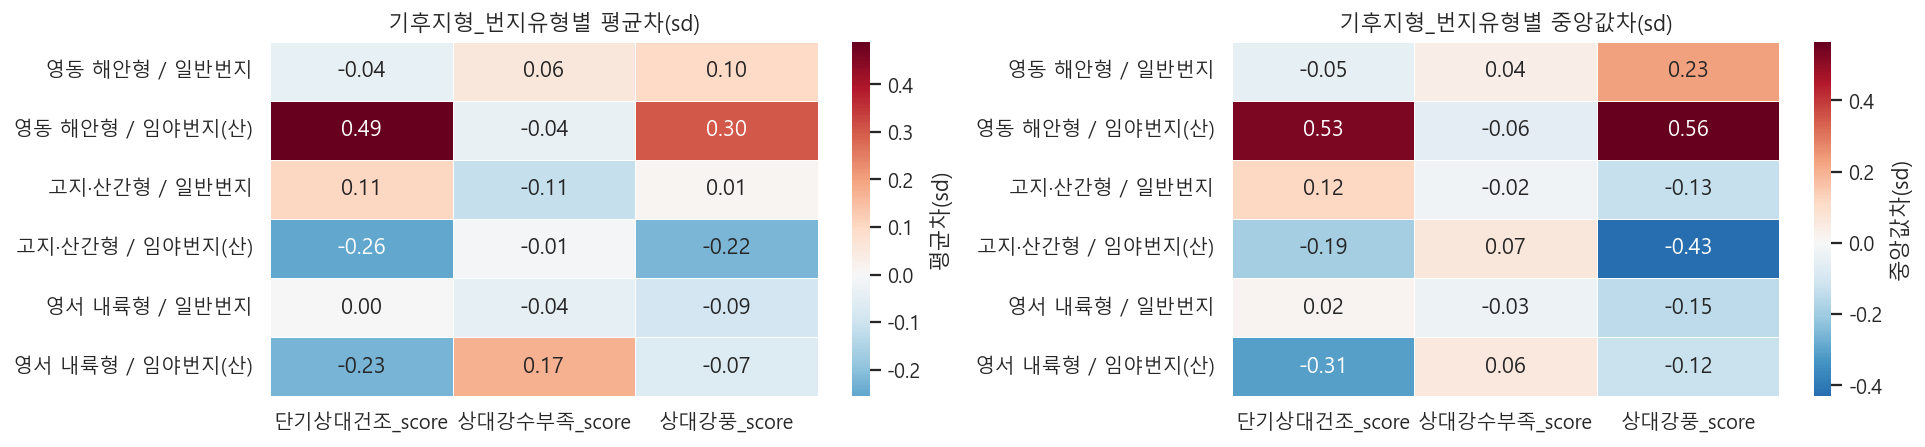

In [33]:
# 11-3. 기후지형_번지유형별 요인점수 비교
climate_addr_preferred_order = [
    "영동 해안형 / 일반번지",
    "영동 해안형 / 임야번지(산)",
    "고지·산간형 / 일반번지",
    "고지·산간형 / 임야번지(산)",
    "영서 내륙형 / 일반번지",
    "영서 내륙형 / 임야번지(산)",
]

matched_climate_addr_result = run_matched_meta_factor_analysis(
    "기후지형_번지유형",
    group_order=climate_addr_preferred_order,
    min_n=10,
    top_pair_n=24,
)


### 11-4. addr_type별 요인점수 비교

기존 절대값 FA에서는 `addr_type`이 공간 입지 요인과 강하게 연결되었다.
이번 매칭비발생 FA에서는 기상 이탈 점수만 있으므로, 번지유형 자체의 효과가 약한지 확인한다.


### `addr_type` 그룹 수

,addr_type,n,비율
0,임야번지(산),784,0.230928
1,일반번지,2611,0.769072


### `addr_type` 요인점수 요약

,메타데이터,그룹,요인점수,n,평균,중앙값,표준편차,p25,p75,평균차_sd,중앙값차_sd
0,addr_type,임야번지(산),상대강수부족_score,784,0.0559,-0.1276,0.6531,-0.2545,0.1872,0.0586,0.0178
1,addr_type,임야번지(산),상대강풍_score,784,0.0068,-0.1260,0.8969,-0.6136,0.5889,0.0074,-0.0238
2,addr_type,임야번지(산),단기상대건조_score,784,-0.0088,-0.0330,1.0302,-0.6426,0.6505,-0.0090,-0.0512
3,addr_type,일반번지,상대강수부족_score,2611,-0.0168,-0.1482,1.0257,-0.2773,0.1274,-0.0176,-0.0039
4,addr_type,일반번지,상대강풍_score,2611,-0.0020,-0.0963,0.9351,-0.6148,0.4886,-0.0022,0.0082
5,addr_type,일반번지,단기상대건조_score,2611,0.0026,0.0305,0.9665,-0.5620,0.6139,0.0027,0.0136


### `addr_type` 검정 결과

,메타데이터,요인점수,검정,그룹수,statistic,p_value,effect_size,effect_label,p_adj_fdr
0,addr_type,상대강수부족_score,Mann-Whitney,2,1077973.0,0.0237,0.0532,rank_biserial,0.0710
1,addr_type,상대강풍_score,Mann-Whitney,2,1025357.0,0.9389,0.0018,rank_biserial,0.9389
2,addr_type,단기상대건조_score,Mann-Whitney,2,1002382.0,0.3800,-0.0206,rank_biserial,0.5700


### `addr_type` 쌍별 비교 상위 12개

,메타데이터,요인점수,그룹1,그룹2,그룹1_n,그룹2_n,그룹1_평균,그룹2_평균,평균차,그룹1_중앙값,그룹2_중앙값,중앙값차,u_stat,p_value,rank_biserial,p_adj_fdr,abs_rank_biserial
2,addr_type,단기상대건조_score,임야번지(산),일반번지,784,2611,-0.0088,0.0026,-0.0115,-0.0330,0.0305,-0.0635,1002382.0,0.3800,-0.0206,0.5700,0.0206
0,addr_type,상대강수부족_score,임야번지(산),일반번지,784,2611,0.0559,-0.0168,0.0726,-0.1276,-0.1482,0.0207,1077973.0,0.0237,0.0532,0.0710,0.0532
1,addr_type,상대강풍_score,임야번지(산),일반번지,784,2611,0.0068,-0.0020,0.0089,-0.1260,-0.0963,-0.0297,1025357.0,0.9389,0.0018,0.9389,0.0018


### `addr_type` 상대강수부족 극단값 분포

,addr_type,n,강수부족_극단음수수,강수부족_극단양수수,강수부족_극단음수비율,강수부족_극단양수비율
0,임야번지(산),784,0,5,0.0000,0.0064
1,일반번지,2611,6,15,0.0023,0.0057


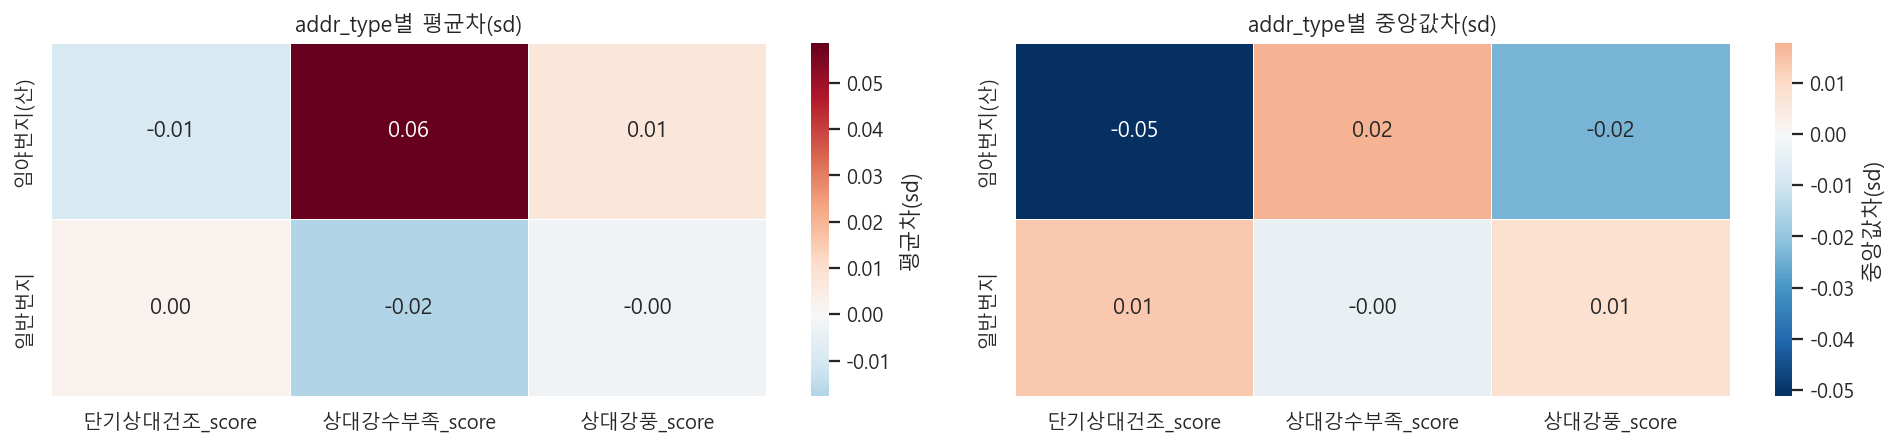

In [34]:
# 11-4. addr_type별 요인점수 비교
matched_addr_type_result = run_matched_meta_factor_analysis(
    "addr_type",
    group_order=ADDR_ORDER,
    min_n=10,
    top_pair_n=12,
)


### 11-5. 산불위험계절별 요인점수 비교

매칭비발생 FA에서 가장 중요한 확인 대상이다.
같은 장소·월·시간대 기준을 이미 맞췄기 때문에, 이 결과는 계절 자체의 절대 차이라기보다 산불위험계절 산불이 평상시 대비 얼마나 더 강풍·단기건조 방향으로 이탈했는지를 보여준다.


### `산불위험계절` 그룹 수

,산불위험계절,n,비율
0,산불위험계절(11~5월),2565,0.755523
1,기타계절,830,0.244477


### `산불위험계절` 요인점수 요약

,메타데이터,그룹,요인점수,n,평균,중앙값,표준편차,p25,p75,평균차_sd,중앙값차_sd
0,산불위험계절,산불위험계절(11~5월),상대강수부족_score,2565,-0.0238,-0.1705,0.6044,-0.2894,0.1000,-0.0249,-0.0272
1,산불위험계절,산불위험계절(11~5월),상대강풍_score,2565,0.1269,0.0831,0.9918,-0.5191,0.7328,0.1370,0.2019
2,산불위험계절,산불위험계절(11~5월),단기상대건조_score,2565,-0.0779,-0.0763,0.9874,-0.6347,0.5231,-0.0794,-0.0952
3,산불위험계절,기타계절,상대강수부족_score,830,0.0735,-0.0518,1.6069,-0.2077,0.2563,0.0771,0.0973
4,산불위험계절,기타계절,상대강풍_score,830,-0.3921,-0.4279,0.5166,-0.7236,-0.0839,-0.4234,-0.3498
5,산불위험계절,기타계절,단기상대건조_score,830,0.2407,0.3091,0.9226,-0.3560,0.9199,0.2453,0.2975


### `산불위험계절` 검정 결과

,메타데이터,요인점수,검정,그룹수,statistic,p_value,effect_size,effect_label,p_adj_fdr
0,산불위험계절,상대강수부족_score,Mann-Whitney,2,821297.0,0.0,-0.2284,rank_biserial,0.0
1,산불위험계절,상대강풍_score,Mann-Whitney,2,1454967.0,0.0,0.3668,rank_biserial,0.0
2,산불위험계절,단기상대건조_score,Mann-Whitney,2,846163.0,0.0,-0.2051,rank_biserial,0.0


### `산불위험계절` 쌍별 비교 상위 12개

,메타데이터,요인점수,그룹1,그룹2,그룹1_n,그룹2_n,그룹1_평균,그룹2_평균,평균차,그룹1_중앙값,그룹2_중앙값,중앙값차,u_stat,p_value,rank_biserial,p_adj_fdr,abs_rank_biserial
2,산불위험계절,단기상대건조_score,산불위험계절(11~5월),기타계절,2565,830,-0.0779,0.2407,-0.3186,-0.0763,0.3091,-0.3854,846163.0,0.0,-0.2051,0.0,0.2051
0,산불위험계절,상대강수부족_score,산불위험계절(11~5월),기타계절,2565,830,-0.0238,0.0735,-0.0972,-0.1705,-0.0518,-0.1187,821297.0,0.0,-0.2284,0.0,0.2284
1,산불위험계절,상대강풍_score,산불위험계절(11~5월),기타계절,2565,830,0.1269,-0.3921,0.5190,0.0831,-0.4279,0.5110,1454967.0,0.0,0.3668,0.0,0.3668


### `산불위험계절` 상대강수부족 극단값 분포

,산불위험계절,n,강수부족_극단음수수,강수부족_극단양수수,강수부족_극단음수비율,강수부족_극단양수비율
0,산불위험계절(11~5월),2565,3,11,0.0012,0.0043
1,기타계절,830,3,9,0.0036,0.0108


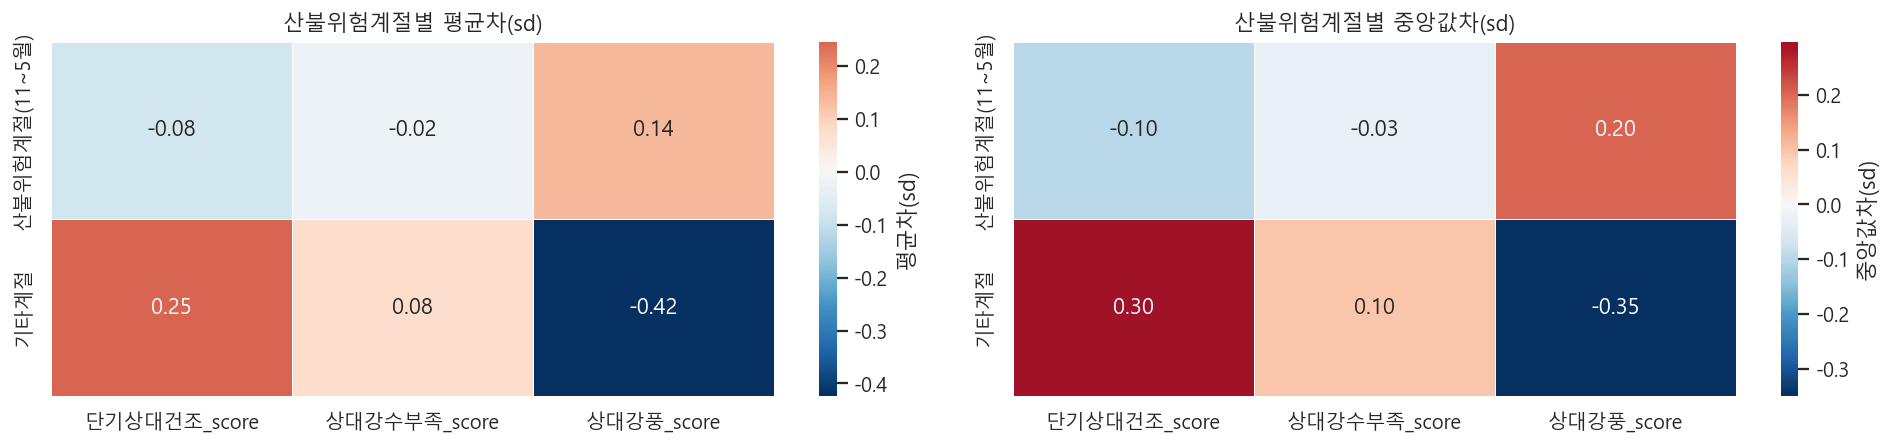

In [35]:
# 11-5. 산불위험계절별 요인점수 비교
fire_risk_season_order = ["산불위험계절(11~5월)", "기타계절"]

matched_fire_risk_season_result = run_matched_meta_factor_analysis(
    "산불위험계절",
    group_order=fire_risk_season_order,
    min_n=10,
    top_pair_n=12,
)


### 11-6. 메타데이터별 효과크기 요약

네 개 메타데이터가 세 요인점수 중 어떤 축을 가장 잘 설명하는지 효과크기 중심으로 비교한다.


### 메타데이터별 효과크기 요약

,메타데이터,요인점수,검정,그룹수,effect_label,effect_size,p_value,p_adj_fdr
5,기후지형_번지유형,단기상대건조_score,Kruskal-Wallis,6,epsilon_sq,0.0274,0.0000,0.0000
2,기후지형유형,단기상대건조_score,Kruskal-Wallis,3,epsilon_sq,0.0034,0.0012,0.0012
8,addr_type,단기상대건조_score,Mann-Whitney,2,rank_biserial,-0.0206,0.3800,0.5700
11,산불위험계절,단기상대건조_score,Mann-Whitney,2,rank_biserial,-0.2051,0.0000,0.0000
6,addr_type,상대강수부족_score,Mann-Whitney,2,rank_biserial,0.0532,0.0237,0.0710
3,기후지형_번지유형,상대강수부족_score,Kruskal-Wallis,6,epsilon_sq,0.0217,0.0000,0.0000
0,기후지형유형,상대강수부족_score,Kruskal-Wallis,3,epsilon_sq,0.0042,0.0003,0.0004
9,산불위험계절,상대강수부족_score,Mann-Whitney,2,rank_biserial,-0.2284,0.0000,0.0000
10,산불위험계절,상대강풍_score,Mann-Whitney,2,rank_biserial,0.3668,0.0000,0.0000
4,기후지형_번지유형,상대강풍_score,Kruskal-Wallis,6,epsilon_sq,0.0313,0.0000,0.0000


### 메타데이터 x 요인점수 효과크기

요인점수,단기상대건조_score,상대강수부족_score,상대강풍_score
메타데이터,,,
기후지형유형,0.0034,0.0042,0.0274
기후지형_번지유형,0.0274,0.0217,0.0313
addr_type,-0.0206,0.0532,0.0018
산불위험계절,-0.2051,-0.2284,0.3668


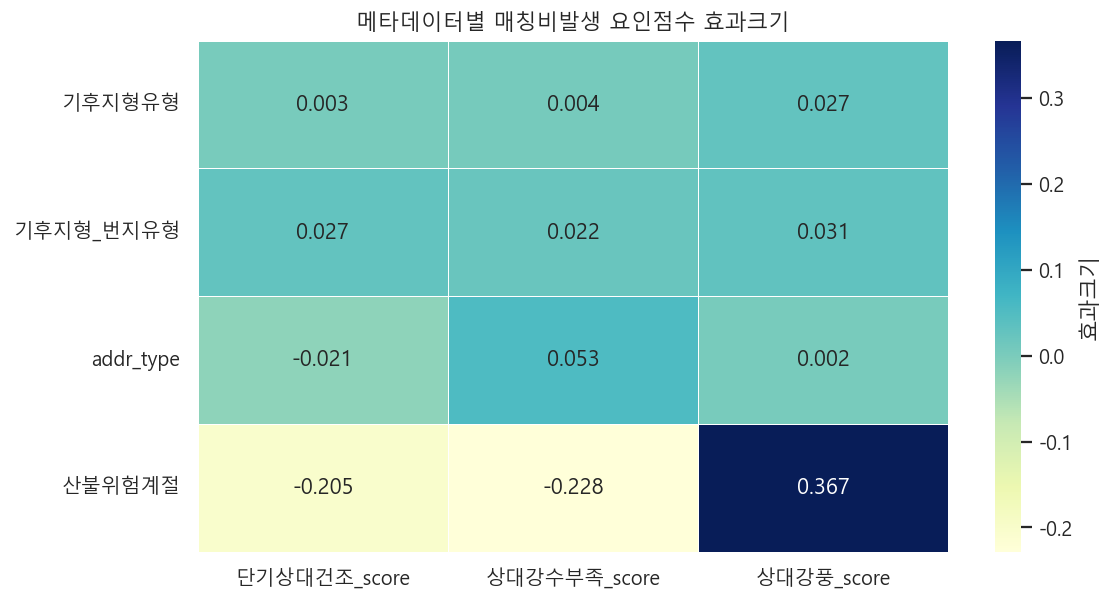

생성 객체:
- matched_climate_type_result
- matched_climate_addr_result
- matched_addr_type_result
- matched_fire_risk_season_result
- matched_meta_effect_summary
- matched_meta_effect_wide


In [36]:
# 11-6. 메타데이터별 효과크기 요약
matched_meta_results = {
    "기후지형유형": matched_climate_type_result,
    "기후지형_번지유형": matched_climate_addr_result,
    "addr_type": matched_addr_type_result,
    "산불위험계절": matched_fire_risk_season_result,
}

matched_meta_effect_summary = pd.concat(
    [
        result["test"].assign(메타데이터=meta_col)
        for meta_col, result in matched_meta_results.items()
        if "test" in result and len(result["test"]) > 0
    ],
    ignore_index=True,
)
matched_meta_effect_summary = matched_meta_effect_summary[
    [
        "메타데이터",
        "요인점수",
        "검정",
        "그룹수",
        "effect_label",
        "effect_size",
        "p_value",
        "p_adj_fdr",
    ]
].sort_values(["요인점수", "effect_size"], ascending=[True, False])

matched_meta_effect_wide = matched_meta_effect_summary.pivot(
    index="메타데이터",
    columns="요인점수",
    values="effect_size",
).reindex(["기후지형유형", "기후지형_번지유형", "addr_type", "산불위험계절"])

display(Markdown("### 메타데이터별 효과크기 요약"))
display(matched_meta_effect_summary.round(4))
display(Markdown("### 메타데이터 x 요인점수 효과크기"))
display(matched_meta_effect_wide.round(4))

fig, ax = plt.subplots(figsize=(9, 4.8), dpi=130)
sns.heatmap(
    matched_meta_effect_wide,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.4,
    cbar_kws={"label": "효과크기"},
    ax=ax,
)
ax.set_title("메타데이터별 매칭비발생 요인점수 효과크기")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("생성 객체:")
print("- matched_climate_type_result")
print("- matched_climate_addr_result")
print("- matched_addr_type_result")
print("- matched_fire_risk_season_result")
print("- matched_meta_effect_summary")
print("- matched_meta_effect_wide")


### 11번 실행 결과 해석: 메타데이터별 매칭비발생 요인점수 비교

11번은 확정된 3개 매칭비발생 요인점수(`상대강수부족_score`, `상대강풍_score`, `단기상대건조_score`)를 주요 메타데이터별로 비교한 단계이다.
기존 절대값 FA 노트북과 흐름은 비슷하지만, 해석 대상은 공간 입지 요인이 아니라 같은 기상셀·월·시간대의 평상시 대비 기상 이탈이다.
따라서 `addr_type`이나 토지피복처럼 공간 입지를 직접 가르는 변수는 약하게 나타날 수 있고, `기후지형유형` 및 `산불위험계절`이 더 중요한 해석 대상이다.

#### 11-0. 비교 입력 요약
비교 대상은 요인점수 `3개`, 표본 `3,395건`이다.
상대강수부족 점수는 앞서 확인한 것처럼 꼬리가 매우 긴 분포이므로 극단값을 별도로 표시했다.
`상대강수부족_score` 기준 `z <= -3`인 극단 음수 사례는 `6건`, `z >= +3`인 극단 양수 사례는 `20건`이다.
이후 강수부족 점수는 평균만으로 해석하지 않고 중앙값과 극단값 분포를 함께 봐야 한다.

| 항목 | 값 |
| --- | ---: |
| 요인점수 행 수 | `3,395` |
| 요인점수 수 | `3` |
| 비교 가능 메타데이터 수 | `4` |
| 상대강수부족 z<=-3 사례 수 | `6` |
| 상대강수부족 z>=+3 사례 수 | `20` |

#### 11-2. 기후지형유형별 해석
기후지형유형은 `상대강풍_score`를 가장 잘 구분하지만, 효과크기는 크지 않다.
Kruskal-Wallis 효과크기는 `상대강풍_score epsilon_sq = 0.0274`로 세 요인 중 가장 크고, `상대강수부족_score = 0.0042`, `단기상대건조_score = 0.0034`는 매우 작다.
즉 기후지형유형 단독으로 매칭비발생 기상 이탈을 강하게 설명한다고 보기는 어렵고, 그중에서는 상대강풍만 약하게 구분된다.

플롯에서 `영동 해안형`은 `상대강풍_score`가 평균차 `+0.14sd`, 중앙값차 `+0.29sd`로 가장 높다.
반대로 `영서 내륙형`은 평균차 `-0.08sd`, 중앙값차 `-0.14sd`, `고지·산간형`은 평균차 `-0.07sd`, 중앙값차 `-0.22sd`로 낮다.
쌍별 비교에서도 영동 해안형은 영서 내륙형보다 강풍 점수 평균이 `+0.2065`, 중앙값이 `+0.4017` 높고, rank-biserial은 `+0.2024`이다.
영동 해안형은 고지·산간형 대비로도 평균 `+0.1916`, 중앙값 `+0.4758`, rank-biserial `+0.1974`로 높다.
따라서 매칭비발생 기준에서도 영동 해안형 산불은 평상시 대비 강풍 이탈이 상대적으로 크다는 기존 결론이 유지된다.

`단기상대건조_score`는 기후지형유형 단독으로는 뚜렷하지 않다.
영동 해안형이 평균차 `+0.07sd`, 중앙값차 `+0.04sd`로 약간 높고, 영서 내륙형은 평균차 `-0.05sd`, 중앙값차 `-0.05sd`로 낮지만 실질 차이는 작다.
`상대강수부족_score`도 영동 해안형 `+0.04sd`, 영서 내륙형 `0.00sd`, 고지·산간형 `-0.08sd` 수준으로 거의 구분되지 않는다.

강수부족 극단값은 해석에 주의가 필요하다.
`z >= +3` 극단 양수 사례는 영서 내륙형에 `17건`으로 가장 많고, 영동 해안형은 `2건`, 고지·산간형은 `1건`이다.
반대로 `z <= -3` 극단 음수 사례는 영동 해안형 `4건`, 영서 내륙형 `1건`, 고지·산간형 `1건`이다.
따라서 기후지형유형별 강수부족 평균차는 일부 극단값의 영향을 받을 수 있으므로 핵심 해석축으로 삼지 않는다.

#### 11-3. 기후지형_번지유형별 해석
기후지형_번지유형은 기후지형유형 단독보다 세 요인점수 차이를 더 잘 드러낸다.
효과크기는 `상대강풍_score epsilon_sq = 0.0313`, `단기상대건조_score = 0.0274`, `상대강수부족_score = 0.0217`이다.
절대값은 여전히 작지만, 기후지형유형 단독보다 높아져 기후와 번지유형의 결합이 매칭비발생 기상 이탈 패턴을 일부 설명한다.

가장 중요한 그룹은 `영동 해안형 / 임야번지(산)`이다.
이 그룹은 `단기상대건조_score` 평균차 `+0.49sd`, 중앙값차 `+0.53sd`, `상대강풍_score` 평균차 `+0.30sd`, 중앙값차 `+0.56sd`로 가장 강한 복합 이탈을 보인다.
즉 영동 해안형 임야번지 산불은 같은 기상셀·월·시간대의 평상시보다 단기 건조와 강풍이 동시에 크게 올라간 상태에서 발생하는 경향이 강하다.
이는 기존 절대값 FA에서 `영동 해안형 / 임야번지(산)`이 강풍·건조 위험형으로 해석된 결과와 방향이 일치한다.

반대로 `고지·산간형 / 임야번지(산)`은 `단기상대건조_score` 평균차 `-0.26sd`, 중앙값차 `-0.19sd`, `상대강풍_score` 평균차 `-0.22sd`, 중앙값차 `-0.43sd`로 낮다.
이 그룹의 산불은 평상시 대비 강풍·단기건조 이탈이 크다기보다, 산지 입지 자체나 다른 조건에 의해 설명될 가능성이 높다.
다만 이번 매칭비발생 FA에는 공간 요인이 없으므로, 이 해석은 기존 절대값 FA의 산지접근성 결과와 함께 봐야 한다.

`영서 내륙형 / 임야번지(산)`은 `상대강수부족_score` 평균차 `+0.17sd`, 중앙값차 `+0.06sd`로 상대적으로 높지만, 강풍과 단기건조는 낮다.
특히 `단기상대건조_score` 평균차 `-0.23sd`, 중앙값차 `-0.31sd`이다.
영서 내륙 임야 산불은 강풍형이라기보다 일부 강수부족 이탈 또는 다른 공간적 조건을 함께 봐야 하는 유형이다.

쌍별 비교에서는 `영동 해안형 / 임야번지(산)`과 다른 임야 그룹 간 차이가 특히 크다.
`단기상대건조_score`에서 영동 해안형 임야번지(산)는 영서 내륙형 임야번지(산)보다 평균 `+0.7017`, 중앙값 `+0.8202`, rank-biserial `+0.4123` 높다.
고지·산간형 임야번지(산) 대비로도 평균 `+0.7309`, 중앙값 `+0.7048`, rank-biserial `+0.3878` 높다.
따라서 단기상대건조의 핵심 고위험 이탈 그룹은 `영동 해안형 / 임야번지(산)`으로 볼 수 있다.

강수부족 극단값은 영서 내륙형에 많이 몰린다.
`z >= +3` 극단 양수 사례는 `영서 내륙형 / 일반번지`가 `13건`, `영서 내륙형 / 임야번지(산)`이 `4건`이다.
반면 영동 해안형 임야번지(산)은 극단 양수·음수 사례가 모두 `0건`이다.
즉 영동 해안형 임야번지(산)의 위험은 강수부족 극단값이 아니라 강풍과 단기건조의 동시 이탈로 설명하는 것이 더 적절하다.

#### 11-4. addr_type별 해석
addr_type 단독 비교에서는 의미 있는 기상 이탈 차이가 거의 없다.
임야번지(산)은 `상대강수부족_score` 평균차 `+0.06sd`, `상대강풍_score` 평균차 `+0.01sd`, `단기상대건조_score` 평균차 `-0.01sd`이다.
일반번지는 세 점수 모두 거의 0에 가깝다.

검정 결과도 같은 결론을 준다.
`상대강수부족_score`는 p-value `0.0237`이지만 FDR 보정 후 `p_adj = 0.0710`으로 유의하지 않고, rank-biserial도 `+0.0532`로 매우 작다.
`상대강풍_score`는 p-value `0.9389`, rank-biserial `+0.0018`, `단기상대건조_score`는 p-value `0.3800`, rank-biserial `-0.0206`이다.
따라서 번지유형 자체는 매칭비발생 기상 이탈 점수를 설명하지 못한다.

이 결과는 기존 절대값 FA와 중요한 차이점이다.
기존 FA에서 addr_type은 `생활권접점_score`, `산지접근성_score` 같은 공간 요인을 매우 강하게 구분했다.
하지만 이번 매칭비발생 FA에는 공간 입지 요인이 없고 기상 이탈만 있으므로 addr_type 효과가 사라지는 것이 자연스럽다.
즉 addr_type은 산불 발생지의 공간 성격을 설명하는 변수이지, 같은 장소·월·시간대 평상시 대비 기상 이탈을 직접 설명하는 변수는 아니다.

#### 11-5. 산불위험계절별 해석
산불위험계절은 이번 매칭비발생 FA에서 가장 강한 메타데이터이다.
`상대강풍_score`의 rank-biserial은 `+0.3668`로 전체 비교 중 가장 크고, `상대강수부족_score`는 `-0.2284`, `단기상대건조_score`는 `-0.2051`이다.
즉 산불위험계절 산불은 평상시 대비 강풍 이탈이 크고, 기타계절 산불은 평상시 대비 단기건조 및 강수부족 이탈이 더 크다.

산불위험계절(11~5월)은 `상대강풍_score` 평균차 `+0.14sd`, 중앙값차 `+0.20sd`이다.
기타계절은 `상대강풍_score` 평균차 `-0.42sd`, 중앙값차 `-0.35sd`로 낮다.
쌍별 비교에서도 산불위험계절은 기타계절보다 강풍 점수 평균이 `+0.5190`, 중앙값이 `+0.5110` 높다.
따라서 매칭 기준을 같은 기상셀·월·시간대로 맞춘 뒤에도 산불위험계절 산불의 핵심 동적 트리거는 상대강풍이다.

반대로 기타계절은 `단기상대건조_score`와 `상대강수부족_score`가 더 높다.
기타계절의 `단기상대건조_score` 평균차는 `+0.25sd`, 중앙값차는 `+0.30sd`이고, 산불위험계절은 평균차 `-0.08sd`, 중앙값차 `-0.10sd`이다.
기타계절의 `상대강수부족_score`도 평균차 `+0.08sd`, 중앙값차 `+0.10sd`로 산불위험계절보다 높다.
이는 여름·비위험계절에 산불이 발생하려면 그 계절의 평상시보다 더 뚜렷한 단기건조나 강수부족 이탈이 필요하다는 의미로 해석할 수 있다.

강수부족 극단값도 기타계절 쪽 비율이 높다.
`z >= +3` 극단 양수 비율은 산불위험계절 `0.0043`, 기타계절 `0.0108`이고, `z <= -3` 극단 음수 비율도 산불위험계절 `0.0012`, 기타계절 `0.0036`이다.
기타계절의 상대강수부족 분포가 더 넓고 극단값 영향을 더 받는다는 뜻이다.

#### 11-6. 효과크기 종합
효과크기 종합 heatmap에서 가장 큰 값은 `산불위험계절 × 상대강풍_score = 0.3668`이다.
그 다음은 `산불위험계절 × 상대강수부족_score = -0.2284`, `산불위험계절 × 단기상대건조_score = -0.2051`이다.
부호는 그룹 순서에 따른 방향을 포함하므로, 핵심은 산불위험계절이 세 기상 이탈 점수 중 특히 상대강풍을 가장 강하게 구분한다는 점이다.

기후지형_번지유형은 세 점수 모두에서 작지만 일관된 효과를 보인다.
`상대강풍_score epsilon_sq = 0.0313`, `단기상대건조_score = 0.0274`, `상대강수부족_score = 0.0217`이다.
기후지형유형 단독보다 효과가 크므로, 기후지형과 번지유형의 결합은 일부 기상 이탈 패턴을 더 잘 드러낸다.

기후지형유형 단독의 효과는 약하다.
가장 큰 값은 `상대강풍_score epsilon_sq = 0.0274`이고, 강수부족과 단기건조는 각각 `0.0042`, `0.0034`로 매우 작다.
addr_type 단독 효과는 사실상 없다.
특히 `상대강풍_score`의 rank-biserial은 `0.0018`로 거의 0이고, 단기상대건조도 `-0.0206`에 불과하다.

#### 11번 결론
매칭비발생 FA 요인점수 해석의 핵심은 기존 절대값 FA와 다르다.
기존 FA는 산불 발생지의 공간 구조와 기상 절대 상태를 함께 설명했지만, 이번 분석은 같은 장소·월·시간대 평상시 대비 기상 트리거 이탈을 설명한다.

최종적으로 다음과 같이 정리한다.
- `산불위험계절`: 상대강풍 이탈을 가장 강하게 설명한다.
- `기타계절`: 평상시 대비 단기건조와 강수부족 이탈이 더 필요한 산불 조건으로 해석된다.
- `영동 해안형`: 기후지형유형 중 상대강풍 이탈이 가장 높다.
- `영동 해안형 / 임야번지(산)`: 상대강풍과 단기상대건조가 동시에 높은 핵심 복합 트리거 그룹이다.
- `addr_type`: 공간 입지를 설명하는 변수이지, 매칭비발생 기상 이탈을 단독으로 설명하는 변수는 아니다.

다음 단계에서는 이 3개 요인점수를 활용해 최종 위험도 지수 또는 Pole 적용용 동적 기상 트리거 지수 설계를 진행할 수 있다.


## 12. 상대강수부족 극단값 제외 민감도

기본 분석은 전체 표본을 유지한다.
이 섹션에서는 `상대강수부족_score`의 극단 음수 꼬리가 메타데이터별 해석을 왜곡하는지 확인하기 위해 `z <= -3` 사례만 제외한 민감도 분석을 수행한다.

주의할 점은 다음과 같다.
- 극단값 제외 결과는 기본 분석을 대체하지 않고 보조 검증으로 사용한다.
- 제외 기준은 `상대강수부족_score`의 하단 극단값(`z <= -3`)이다.
- 비교 대상은 11번과 같은 `기후지형유형`, `기후지형_번지유형`, `addr_type`, `산불위험계절`이다.


In [37]:
# 12-0. 상대강수부족 극단 음수 사례 정의
required_sensitivity_objects = [
    "matched_factor_meta_df",
    "MATCHED_SCORE_COLS",
    "summarize_matched_scores_by_meta",
    "test_matched_scores_by_meta",
    "matched_group_order",
]
missing_sensitivity_objects = [name for name in required_sensitivity_objects if name not in globals()]
if missing_sensitivity_objects:
    raise NameError(f"11번 섹션을 먼저 실행해야 합니다. 누락 객체: {missing_sensitivity_objects}")

RAIN_SENSITIVITY_SCORE_COL = "상대강수부족_score"
RAIN_SENSITIVITY_Z_CUTOFF = -3.0

rain_sensitivity_source = matched_factor_meta_df.copy()
rain_score_for_sensitivity = pd.to_numeric(
    rain_sensitivity_source[RAIN_SENSITIVITY_SCORE_COL],
    errors="coerce",
)
rain_sensitivity_z = (
    rain_score_for_sensitivity - rain_score_for_sensitivity.mean()
) / rain_score_for_sensitivity.std(ddof=0)

rain_sensitivity_source["상대강수부족_민감도_z"] = rain_sensitivity_z
rain_sensitivity_source["상대강수부족_민감도_극단음수"] = (
    rain_sensitivity_source["상대강수부족_민감도_z"] <= RAIN_SENSITIVITY_Z_CUTOFF
)

rain_extreme_negative_mask = rain_sensitivity_source["상대강수부족_민감도_극단음수"].fillna(False)
matched_factor_meta_no_rain_extreme_df = rain_sensitivity_source.loc[~rain_extreme_negative_mask].copy()
matched_factor_meta_rain_extreme_removed_df = rain_sensitivity_source.loc[rain_extreme_negative_mask].copy()

rain_extreme_sensitivity_input_summary = pd.DataFrame(
    {
        "항목": [
            "전체 표본 수",
            "제외 기준",
            "제외 사례 수",
            "제외 비율",
            "민감도 분석 표본 수",
            "제외 전 상대강수부족 평균",
            "제외 후 상대강수부족 평균",
            "제외 전 상대강수부족 중앙값",
            "제외 후 상대강수부족 중앙값",
        ],
        "값": [
            len(rain_sensitivity_source),
            f"{RAIN_SENSITIVITY_SCORE_COL} z <= {RAIN_SENSITIVITY_Z_CUTOFF}",
            int(rain_extreme_negative_mask.sum()),
            rain_extreme_negative_mask.mean(),
            len(matched_factor_meta_no_rain_extreme_df),
            rain_score_for_sensitivity.mean(),
            matched_factor_meta_no_rain_extreme_df[RAIN_SENSITIVITY_SCORE_COL].mean(),
            rain_score_for_sensitivity.median(),
            matched_factor_meta_no_rain_extreme_df[RAIN_SENSITIVITY_SCORE_COL].median(),
        ],
    }
)

rain_extreme_detail_cols = [
    "fire_id",
    "발생일시",
    "기상셀ID",
    "기후지형유형",
    "기후지형_번지유형",
    "addr_type",
    "산불위험계절",
    "L1_NAME",
    "L2_NAME",
    "상대강수부족_score",
    "상대강수부족_민감도_z",
    "상대강풍_score",
    "단기상대건조_score",
]
rain_extreme_detail_cols = [
    col for col in rain_extreme_detail_cols
    if col in matched_factor_meta_rain_extreme_removed_df.columns
]
rain_extreme_removed_detail = (
    matched_factor_meta_rain_extreme_removed_df
    .sort_values("상대강수부족_score")
    [rain_extreme_detail_cols]
)

display(Markdown("### 상대강수부족 극단 음수 제외 기준 요약"))
display(rain_extreme_sensitivity_input_summary.round(4))
display(Markdown("### 제외된 상대강수부족 극단 음수 사례"))
display(rain_extreme_removed_detail.round(4))

print("생성 객체:")
print("- rain_sensitivity_source: 극단값 플래그가 포함된 전체 요인점수 데이터")
print("- matched_factor_meta_no_rain_extreme_df: 상대강수부족 z<=-3 제외 데이터")
print("- matched_factor_meta_rain_extreme_removed_df: 제외된 극단 음수 사례")
print("- rain_extreme_sensitivity_input_summary")


### 상대강수부족 극단 음수 제외 기준 요약

,항목,값
0,전체 표본 수,3395
1,제외 기준,상대강수부족_score z <= -3.0
2,제외 사례 수,6
3,제외 비율,0.001767
4,민감도 분석 표본 수,3389
5,제외 전 상대강수부족 평균,0.0
6,제외 후 상대강수부족 평균,0.024812
7,제외 전 상대강수부족 중앙값,-0.144535
8,제외 후 상대강수부족 중앙값,-0.14382


### 제외된 상대강수부족 극단 음수 사례

,fire_id,발생일시,기상셀ID,기후지형유형,기후지형_번지유형,addr_type,산불위험계절,L1_NAME,L2_NAME,상대강수부족_score,상대강수부족_민감도_z,상대강풍_score,단기상대건조_score
3235,F_010990,2020-08-03 14:00:00,YS_0063,영서 내륙형,영서 내륙형 / 일반번지,일반번지,기타계절,시가화건조지역,주거지역,-33.1280,-34.7626,-0.9397,1.5623
202,F_007818,2020-09-03 15:00:00,YD_0014,영동 해안형,영동 해안형 / 일반번지,일반번지,기타계절,나지,인공나지,-19.8189,-20.7968,3.0876,0.5054
3236,F_010993,2020-09-03 15:00:00,YD_0014,영동 해안형,영동 해안형 / 일반번지,일반번지,기타계절,나지,인공나지,-18.0297,-18.9193,2.9013,1.1479
3211,F_010943,2020-05-19 04:00:00,YD_0017,영동 해안형,영동 해안형 / 일반번지,일반번지,산불위험계절(11~5월),시가화건조지역,도로,-5.2644,-5.5242,-0.5255,-4.2192
3394,F_011274,2021-05-18 09:00:00,YS_0013,고지·산간형,고지·산간형 / 일반번지,일반번지,산불위험계절(11~5월),산림지역,침엽수림,-4.5662,-4.7915,-2.1109,-4.5133
2864,F_010483,2021-04-13 15:00:00,YD_0013,영동 해안형,영동 해안형 / 일반번지,일반번지,산불위험계절(11~5월),시가화건조지역,도로,-3.2818,-3.4437,0.4826,-0.2245


생성 객체:
- rain_sensitivity_source: 극단값 플래그가 포함된 전체 요인점수 데이터
- matched_factor_meta_no_rain_extreme_df: 상대강수부족 z<=-3 제외 데이터
- matched_factor_meta_rain_extreme_removed_df: 제외된 극단 음수 사례
- rain_extreme_sensitivity_input_summary


### 12-1. 메타데이터별 제외 전후 요약 비교

각 메타데이터 그룹에서 극단 음수 사례를 제외했을 때 평균차(sd), 중앙값차(sd), 효과크기가 얼마나 바뀌는지 확인한다.


In [38]:
# 12-1. 메타데이터별 극단값 제외 전후 비교 함수
def build_rain_extreme_group_order(meta_col):
    if meta_col == "기후지형유형":
        return [item for item in TYPE_ORDER if item in rain_sensitivity_source[meta_col].astype(str).unique()]
    if meta_col == "기후지형_번지유형":
        preferred = [
            "영동 해안형 / 일반번지",
            "영동 해안형 / 임야번지(산)",
            "고지·산간형 / 일반번지",
            "고지·산간형 / 임야번지(산)",
            "영서 내륙형 / 일반번지",
            "영서 내륙형 / 임야번지(산)",
        ]
        return [item for item in preferred if item in rain_sensitivity_source[meta_col].astype(str).unique()]
    if meta_col == "addr_type":
        return [item for item in ADDR_ORDER if item in rain_sensitivity_source[meta_col].astype(str).unique()]
    if meta_col == "산불위험계절":
        return [
            item for item in ["산불위험계절(11~5월)", "기타계절"]
            if item in rain_sensitivity_source[meta_col].astype(str).unique()
        ]
    return None


def compare_meta_before_after_rain_extreme(meta_col, score_cols, min_n=10):
    group_order = build_rain_extreme_group_order(meta_col)

    full_count, full_summary, full_mean_wide, full_median_wide = summarize_matched_scores_by_meta(
        rain_sensitivity_source,
        meta_col,
        score_cols,
        group_order=group_order,
        min_n=min_n,
    )
    no_extreme_count, no_extreme_summary, no_extreme_mean_wide, no_extreme_median_wide = summarize_matched_scores_by_meta(
        matched_factor_meta_no_rain_extreme_df,
        meta_col,
        score_cols,
        group_order=group_order,
        min_n=min_n,
    )

    full_test, full_pair = test_matched_scores_by_meta(
        rain_sensitivity_source,
        meta_col,
        score_cols,
        group_order=group_order,
        min_n=min_n,
    )
    no_extreme_test, no_extreme_pair = test_matched_scores_by_meta(
        matched_factor_meta_no_rain_extreme_df,
        meta_col,
        score_cols,
        group_order=group_order,
        min_n=min_n,
    )

    summary_compare = full_summary.merge(
        no_extreme_summary,
        on=["메타데이터", "그룹", "요인점수"],
        suffixes=("_전체", "_극단제외"),
        how="outer",
    )
    summary_compare["제외_n"] = summary_compare["n_전체"] - summary_compare["n_극단제외"]
    summary_compare["평균차_sd_변화"] = (
        summary_compare["평균차_sd_극단제외"] - summary_compare["평균차_sd_전체"]
    )
    summary_compare["중앙값차_sd_변화"] = (
        summary_compare["중앙값차_sd_극단제외"] - summary_compare["중앙값차_sd_전체"]
    )
    summary_compare["평균_변화"] = summary_compare["평균_극단제외"] - summary_compare["평균_전체"]
    summary_compare["중앙값_변화"] = summary_compare["중앙값_극단제외"] - summary_compare["중앙값_전체"]

    effect_compare = full_test.merge(
        no_extreme_test,
        on=["메타데이터", "요인점수", "검정", "그룹수", "effect_label"],
        suffixes=("_전체", "_극단제외"),
        how="outer",
    )
    effect_compare["effect_size_변화"] = (
        effect_compare["effect_size_극단제외"] - effect_compare["effect_size_전체"]
    )
    effect_compare["p_adj_fdr_변화"] = (
        effect_compare["p_adj_fdr_극단제외"] - effect_compare["p_adj_fdr_전체"]
    )

    removed_by_group = (
        rain_sensitivity_source
        .dropna(subset=[meta_col])
        .assign(**{meta_col: lambda df: df[meta_col].astype(str)})
        .groupby(meta_col, observed=False)
        .agg(
            전체_n=(meta_col, "size"),
            제외_n=("상대강수부족_민감도_극단음수", "sum"),
        )
        .reindex(group_order)
        .dropna()
        .reset_index()
    )
    removed_by_group["제외비율"] = removed_by_group["제외_n"] / removed_by_group["전체_n"]

    return {
        "count_full": full_count,
        "count_no_extreme": no_extreme_count,
        "removed_by_group": removed_by_group,
        "summary_compare": summary_compare,
        "effect_compare": effect_compare,
        "full_mean_wide": full_mean_wide,
        "no_extreme_mean_wide": no_extreme_mean_wide,
        "full_median_wide": full_median_wide,
        "no_extreme_median_wide": no_extreme_median_wide,
        "full_pair": full_pair,
        "no_extreme_pair": no_extreme_pair,
    }


RAIN_EXTREME_SENSITIVITY_META_COLS = [
    "기후지형유형",
    "기후지형_번지유형",
    "addr_type",
    "산불위험계절",
]

rain_extreme_sensitivity_results = {
    meta_col: compare_meta_before_after_rain_extreme(meta_col, MATCHED_SCORE_COLS, min_n=10)
    for meta_col in RAIN_EXTREME_SENSITIVITY_META_COLS
}

rain_extreme_sensitivity_group_summary = pd.concat(
    [
        result["summary_compare"].assign(메타데이터=meta_col)
        for meta_col, result in rain_extreme_sensitivity_results.items()
    ],
    ignore_index=True,
)
rain_extreme_sensitivity_effect_summary = pd.concat(
    [
        result["effect_compare"].assign(메타데이터=meta_col)
        for meta_col, result in rain_extreme_sensitivity_results.items()
    ],
    ignore_index=True,
)
rain_extreme_removed_by_group_summary = pd.concat(
    [
        result["removed_by_group"].assign(메타데이터=meta_col)
        for meta_col, result in rain_extreme_sensitivity_results.items()
    ],
    ignore_index=True,
)

display(Markdown("### 메타데이터 그룹별 극단 음수 제외 사례 수"))
display(rain_extreme_removed_by_group_summary.round(4))
display(Markdown("### 상대강수부족_score 제외 전후 그룹 요약"))
rain_score_group_compare_cols = [
    "메타데이터",
    "그룹",
    "요인점수",
    "n_전체",
    "n_극단제외",
    "제외_n",
    "평균차_sd_전체",
    "평균차_sd_극단제외",
    "평균차_sd_변화",
    "중앙값차_sd_전체",
    "중앙값차_sd_극단제외",
    "중앙값차_sd_변화",
]
display(
    rain_extreme_sensitivity_group_summary
    .loc[lambda df: df["요인점수"].eq(RAIN_SENSITIVITY_SCORE_COL), rain_score_group_compare_cols]
    .round(4)
)
display(Markdown("### 제외 전후 효과크기 비교"))
effect_compare_cols = [
    "메타데이터",
    "요인점수",
    "effect_label",
    "effect_size_전체",
    "effect_size_극단제외",
    "effect_size_변화",
    "p_adj_fdr_전체",
    "p_adj_fdr_극단제외",
]
display(rain_extreme_sensitivity_effect_summary[effect_compare_cols].round(4))

print("생성 객체:")
print("- rain_extreme_sensitivity_results")
print("- rain_extreme_sensitivity_group_summary")
print("- rain_extreme_sensitivity_effect_summary")
print("- rain_extreme_removed_by_group_summary")


### 메타데이터 그룹별 극단 음수 제외 사례 수

,기후지형유형,전체_n,제외_n,제외비율,메타데이터,기후지형_번지유형,addr_type,산불위험계절
0,영동 해안형,1218,4,0.0033,기후지형유형,NaN,NaN,NaN
1,영서 내륙형,1556,1,0.0006,기후지형유형,NaN,NaN,NaN
2,고지·산간형,621,1,0.0016,기후지형유형,NaN,NaN,NaN
3,NaN,972,4,0.0041,기후지형_번지유형,영동 해안형 / 일반번지,NaN,NaN
4,NaN,246,0,0.0000,기후지형_번지유형,영동 해안형 / 임야번지(산),NaN,NaN
5,NaN,412,1,0.0024,기후지형_번지유형,고지·산간형 / 일반번지,NaN,NaN
6,NaN,209,0,0.0000,기후지형_번지유형,고지·산간형 / 임야번지(산),NaN,NaN
7,NaN,1227,1,0.0008,기후지형_번지유형,영서 내륙형 / 일반번지,NaN,NaN
8,NaN,329,0,0.0000,기후지형_번지유형,영서 내륙형 / 임야번지(산),NaN,NaN
9,NaN,784,0,0.0000,addr_type,NaN,임야번지(산),NaN


### 상대강수부족_score 제외 전후 그룹 요약

,메타데이터,그룹,요인점수,n_전체,n_극단제외,제외_n,평균차_sd_전체,평균차_sd_극단제외,평균차_sd_변화,중앙값차_sd_전체,중앙값차_sd_극단제외,중앙값차_sd_변화
1,기후지형유형,고지·산간형,상대강수부족_score,621,620,1,-0.0781,-0.1541,-0.0761,0.0223,0.0351,0.0129
4,기후지형유형,영동 해안형,상대강수부족_score,1218,1214,4,0.0384,0.0841,0.0456,0.0102,0.0173,0.0071
7,기후지형유형,영서 내륙형,상대강수부족_score,1556,1555,1,0.0011,-0.0042,-0.0052,-0.0136,-0.0228,-0.0092
10,기후지형_번지유형,고지·산간형 / 일반번지,상대강수부족_score,412,411,1,-0.1129,-0.2037,-0.0908,-0.0250,-0.0397,-0.0147
13,기후지형_번지유형,고지·산간형 / 임야번지(산),상대강수부족_score,209,209,0,-0.0094,-0.0567,-0.0472,0.0659,0.1040,0.0381
16,기후지형_번지유형,영동 해안형 / 일반번지,상대강수부족_score,972,968,4,0.0573,0.1306,0.0733,0.0393,0.0633,0.0240
19,기후지형_번지유형,영동 해안형 / 임야번지(산),상대강수부족_score,246,246,0,-0.0360,-0.0992,-0.0631,-0.0581,-0.0940,-0.0359
22,기후지형_번지유형,영서 내륙형 / 일반번지,상대강수부족_score,1227,1226,1,-0.0449,-0.0681,-0.0232,-0.0282,-0.0462,-0.0180
25,기후지형_번지유형,영서 내륙형 / 임야번지(산),상대강수부족_score,329,329,0,0.1727,0.2342,0.0615,0.0596,0.0940,0.0344
28,addr_type,일반번지,상대강수부족_score,2611,2605,6,-0.0176,-0.0157,0.0019,-0.0039,-0.0067,-0.0028


### 제외 전후 효과크기 비교

,메타데이터,요인점수,effect_label,effect_size_전체,effect_size_극단제외,effect_size_변화,p_adj_fdr_전체,p_adj_fdr_극단제외
0,기후지형유형,단기상대건조_score,epsilon_sq,0.0034,0.0035,0.0001,0.0012,0.0011
1,기후지형유형,상대강수부족_score,epsilon_sq,0.0042,0.0045,0.0003,0.0004,0.0003
2,기후지형유형,상대강풍_score,epsilon_sq,0.0274,0.0269,-0.0005,0.0000,0.0000
3,기후지형_번지유형,단기상대건조_score,epsilon_sq,0.0274,0.0276,0.0002,0.0000,0.0000
4,기후지형_번지유형,상대강수부족_score,epsilon_sq,0.0217,0.0222,0.0006,0.0000,0.0000
5,기후지형_번지유형,상대강풍_score,epsilon_sq,0.0313,0.0309,-0.0004,0.0000,0.0000
6,addr_type,단기상대건조_score,rank_biserial,-0.0206,-0.0207,-0.0001,0.5700,0.5673
7,addr_type,상대강수부족_score,rank_biserial,0.0532,0.0510,-0.0022,0.0710,0.0902
8,addr_type,상대강풍_score,rank_biserial,0.0018,0.0019,0.0001,0.9389,0.9362
9,산불위험계절,단기상대건조_score,rank_biserial,-0.2051,-0.2025,0.0026,0.0000,0.0000


생성 객체:
- rain_extreme_sensitivity_results
- rain_extreme_sensitivity_group_summary
- rain_extreme_sensitivity_effect_summary
- rain_extreme_removed_by_group_summary


### 12-2. 극단값 제외 전후 시각화

상대강수부족 점수의 평균차·중앙값차 변화와 메타데이터별 효과크기 변화를 시각화한다.


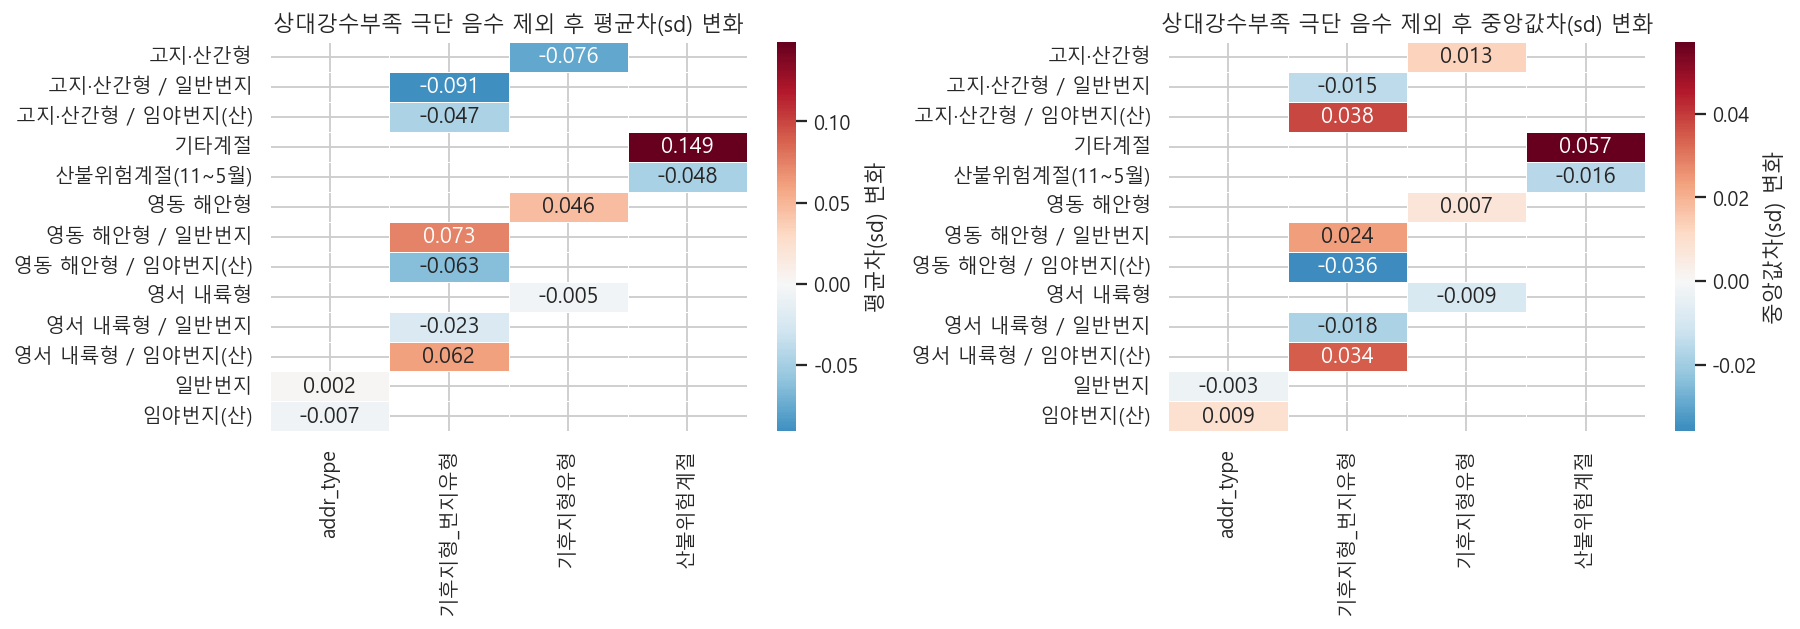

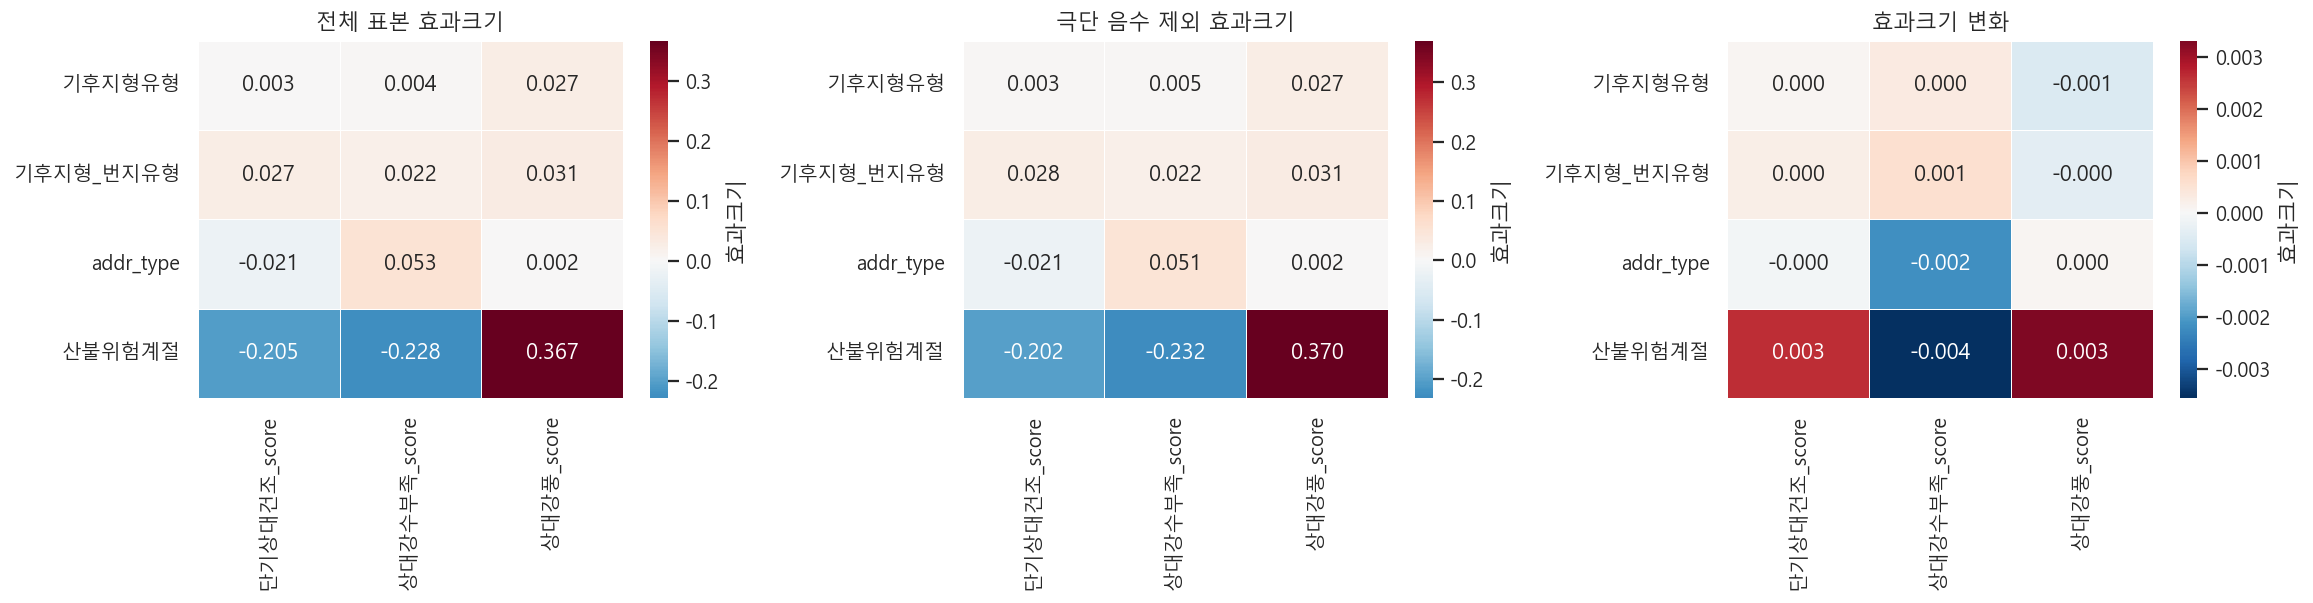

생성 객체:
- rain_score_mean_delta_wide
- rain_score_median_delta_wide
- effect_full_wide
- effect_no_extreme_wide
- effect_delta_wide


In [39]:
# 12-2. 극단값 제외 전후 시각화
rain_score_mean_delta_wide = (
    rain_extreme_sensitivity_group_summary
    .loc[lambda df: df["요인점수"].eq(RAIN_SENSITIVITY_SCORE_COL)]
    .pivot(index="그룹", columns="메타데이터", values="평균차_sd_변화")
)
rain_score_median_delta_wide = (
    rain_extreme_sensitivity_group_summary
    .loc[lambda df: df["요인점수"].eq(RAIN_SENSITIVITY_SCORE_COL)]
    .pivot(index="그룹", columns="메타데이터", values="중앙값차_sd_변화")
)

fig_height = max(5.0, 0.35 * len(rain_score_mean_delta_wide))
fig, axes = plt.subplots(1, 2, figsize=(14, fig_height), dpi=130)
sns.heatmap(
    rain_score_mean_delta_wide,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "평균차(sd) 변화"},
    ax=axes[0],
)
axes[0].set_title("상대강수부족 극단 음수 제외 후 평균차(sd) 변화")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    rain_score_median_delta_wide,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "중앙값차(sd) 변화"},
    ax=axes[1],
)
axes[1].set_title("상대강수부족 극단 음수 제외 후 중앙값차(sd) 변화")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

effect_full_wide = rain_extreme_sensitivity_effect_summary.pivot(
    index="메타데이터",
    columns="요인점수",
    values="effect_size_전체",
).reindex(RAIN_EXTREME_SENSITIVITY_META_COLS)
effect_no_extreme_wide = rain_extreme_sensitivity_effect_summary.pivot(
    index="메타데이터",
    columns="요인점수",
    values="effect_size_극단제외",
).reindex(RAIN_EXTREME_SENSITIVITY_META_COLS)
effect_delta_wide = effect_no_extreme_wide - effect_full_wide

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), dpi=130)
for ax, data, title in [
    (axes[0], effect_full_wide, "전체 표본 효과크기"),
    (axes[1], effect_no_extreme_wide, "극단 음수 제외 효과크기"),
    (axes[2], effect_delta_wide, "효과크기 변화"),
]:
    sns.heatmap(
        data,
        annot=True,
        fmt=".3f",
        cmap="RdBu_r",
        center=0,
        linewidths=0.4,
        cbar_kws={"label": "효과크기"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

print("생성 객체:")
print("- rain_score_mean_delta_wide")
print("- rain_score_median_delta_wide")
print("- effect_full_wide")
print("- effect_no_extreme_wide")
print("- effect_delta_wide")


### 12-3. 민감도 판단표

극단값 제외 후 결론이 바뀌는지 확인한다.
핵심 판단 기준은 `상대강수부족_score`의 효과크기 변화와 그룹 평균차/중앙값차 변화이다.


In [40]:
# 12-3. 민감도 판단표
rain_effect_only = rain_extreme_sensitivity_effect_summary[
    rain_extreme_sensitivity_effect_summary["요인점수"].eq(RAIN_SENSITIVITY_SCORE_COL)
].copy()

rain_group_change_abs = (
    rain_extreme_sensitivity_group_summary[
        rain_extreme_sensitivity_group_summary["요인점수"].eq(RAIN_SENSITIVITY_SCORE_COL)
    ]
    .groupby("메타데이터", observed=False)
    .agg(
        최대_평균차sd_변화_abs=("평균차_sd_변화", lambda s: s.abs().max()),
        최대_중앙값차sd_변화_abs=("중앙값차_sd_변화", lambda s: s.abs().max()),
        총제외수=("제외_n", "sum"),
    )
    .reset_index()
)

rain_extreme_sensitivity_decision_table = rain_effect_only.merge(
    rain_group_change_abs,
    on="메타데이터",
    how="left",
)
rain_extreme_sensitivity_decision_table["효과크기_abs_변화"] = (
    rain_extreme_sensitivity_decision_table["effect_size_극단제외"].abs()
    - rain_extreme_sensitivity_decision_table["effect_size_전체"].abs()
)
rain_extreme_sensitivity_decision_table["판단"] = np.where(
    (
        rain_extreme_sensitivity_decision_table["효과크기_abs_변화"].abs() < 0.02
    )
    & (
        rain_extreme_sensitivity_decision_table["최대_중앙값차sd_변화_abs"] < 0.05
    ),
    "결론 유지",
    "해석 주의",
)

display(Markdown("### 상대강수부족 극단 음수 제외 민감도 판단표"))
display(
    rain_extreme_sensitivity_decision_table[
        [
            "메타데이터",
            "effect_label",
            "effect_size_전체",
            "effect_size_극단제외",
            "effect_size_변화",
            "효과크기_abs_변화",
            "최대_평균차sd_변화_abs",
            "최대_중앙값차sd_변화_abs",
            "총제외수",
            "판단",
        ]
    ].round(4)
)

print("다음 해석 기준:")
print("- 판단이 '결론 유지'이면 11번 기본 해석을 유지한다.")
print("- 판단이 '해석 주의'이면 해당 메타데이터의 상대강수부족 해석은 중앙값/극단값 분포 중심으로 보조 해석한다.")
print("- 상대강풍과 단기상대건조의 핵심 결론은 상대강수부족 극단 음수 제외와 직접 관련이 작다.")


### 상대강수부족 극단 음수 제외 민감도 판단표

,메타데이터,effect_label,effect_size_전체,effect_size_극단제외,effect_size_변화,효과크기_abs_변화,최대_평균차sd_변화_abs,최대_중앙값차sd_변화_abs,총제외수,판단
0,기후지형유형,epsilon_sq,0.0042,0.0045,0.0003,0.0003,0.0761,0.0129,6,결론 유지
1,기후지형_번지유형,epsilon_sq,0.0217,0.0222,0.0006,0.0006,0.0908,0.0381,6,결론 유지
2,addr_type,rank_biserial,0.0532,0.0510,-0.0022,-0.0022,0.0066,0.0094,6,결론 유지
3,산불위험계절,rank_biserial,-0.2284,-0.2320,-0.0036,0.0036,0.1487,0.0571,6,해석 주의


다음 해석 기준:
- 판단이 '결론 유지'이면 11번 기본 해석을 유지한다.
- 판단이 '해석 주의'이면 해당 메타데이터의 상대강수부족 해석은 중앙값/극단값 분포 중심으로 보조 해석한다.
- 상대강풍과 단기상대건조의 핵심 결론은 상대강수부족 극단 음수 제외와 직접 관련이 작다.


#### 12. 상대강수부족 극단값 제외 민감도 실행 결과 해석
- 12번은 `상대강수부족_score`의 극단 음수 꼬리가 11번 메타데이터 비교 결론을 왜곡하는지 확인한 민감도 분석이다.
- 제외 기준은 `상대강수부족_score`의 표준화 z값 `<= -3.0`이며, 전체 `3,395건` 중 `6건`만 제외된다.
- 제외 비율은 `0.001767`, 약 `0.18%`로 매우 작다. 극단값 제외 후 분석 표본은 `3,389건`이다.
- 제외 전 `상대강수부족_score` 평균은 `0.0000`, 제외 후 평균은 `+0.0248`로 약간 상승한다.
- 반면 중앙값은 `-0.1445`에서 `-0.1438`로 거의 변하지 않는다.
- 따라서 극단 음수 사례는 평균을 일부 끌어내리지만, 전체 분포의 중심 위치를 바꿀 정도는 아니다.

##### 제외된 극단 음수 사례의 성격
- 제외된 6건은 산불 발생 시점이 매칭 비발생 시점보다 강수량이 훨씬 많았던 사례이다.
- 가장 큰 극단값은 `상대강수부족_score = -33.1280`이고, 그 다음도 `-19.8189`, `-18.0297`처럼 매우 낮다.
- 이 값들은 `강수부족`이 강한 사례가 아니라, 오히려 발생 시점에 비발생 대비 강수량이 많았던 예외 사례로 해석해야 한다.
- 기후지형유형별로는 `영동 해안형` 4건, `영서 내륙형` 1건, `고지·산간형` 1건이다.
- 번지유형 기준으로는 6건 모두 `일반번지`이며, `임야번지(산)`에서는 제외 사례가 없다.
- 계절 기준으로는 `산불위험계절(11~5월)` 3건, `기타계절` 3건이다.

##### 평균차와 중앙값차 변화
- 첫 번째 플롯에서 평균차 변화가 중앙값차 변화보다 크다.
- 이는 극단 음수 제외가 분포의 중심보다는 평균에 더 크게 작용한다는 뜻이다.
- `산불위험계절` 기준 변화가 가장 크다. `기타계절`의 `상대강수부족_score` 평균차는 `+0.1487sd` 증가하고, 중앙값차는 `+0.0571sd` 증가한다.
- `산불위험계절(11~5월)`은 평균차가 `-0.0480sd`, 중앙값차가 `-0.0157sd`만큼 낮아진다.
- 즉 기타계절에 포함된 극단 음수 3건이 기타계절 평균을 낮추고 있었으며, 이를 제외하면 기타계절의 상대강수부족 경향이 더 뚜렷해진다.
- `기후지형_번지유형`에서는 `영동 해안형 / 일반번지`의 평균차가 `+0.0733sd` 증가하고, `고지·산간형 / 일반번지`는 `-0.0908sd` 감소한다.
- 다만 중앙값 변화는 대부분 작아, 그룹의 전형적인 위치가 크게 바뀌었다고 보기는 어렵다.
- `addr_type`은 6건 모두 `일반번지`에서 제외되었는데도 변화가 거의 없다. `일반번지` 평균차 변화는 `+0.0019sd`, `임야번지(산)`은 `-0.0066sd` 수준이다.

##### 효과크기 변화
- 두 번째 플롯의 전체 표본 효과크기와 극단 음수 제외 효과크기는 거의 동일하다.
- `기후지형유형 × 상대강수부족_score` 효과크기는 `0.0042`에서 `0.0045`로 `+0.0003`만 변한다.
- `기후지형_번지유형 × 상대강수부족_score`는 `0.0217`에서 `0.0222`로 `+0.0006`만 변한다.
- `addr_type × 상대강수부족_score`는 `0.0532`에서 `0.0510`으로 `-0.0022` 변한다. FDR 보정 p-value도 `0.0710`에서 `0.0902`로 바뀌어, 여전히 유의한 핵심축으로 보기 어렵다.
- `산불위험계절 × 상대강수부족_score`는 `-0.2284`에서 `-0.2320`으로 `-0.0036` 변한다.
- 효과크기 변화는 모두 매우 작으므로, 극단 음수 제외가 11번의 메타데이터별 핵심 결론을 바꾸지는 않는다.

##### 판단표 해석
- 판단표에서는 `기후지형유형`, `기후지형_번지유형`, `addr_type`이 모두 `결론 유지`로 분류된다.
- `산불위험계절`만 `해석 주의`로 분류된다.
- 여기서 `해석 주의`는 계절 효과 자체가 사라진다는 의미가 아니다.
- 계절의 효과크기는 거의 유지되지만, `상대강수부족_score`의 평균 기반 해석이 일부 극단값에 민감하므로 중앙값과 분위수를 함께 보라는 의미이다.
- 특히 11번에서 확인한 `산불위험계절은 상대강풍이 높고, 기타계절은 상대강수부족 및 단기상대건조가 상대적으로 높다`는 방향은 유지된다.
- 다만 기타계절의 `상대강수부족_score` 평균은 극단 음수 제외 후 더 높아지므로, 기타계절의 강수부족 해석은 평균 하나가 아니라 중앙값과 극단값 제외 결과를 같이 제시하는 것이 안전하다.

##### 12번 결론
- `상대강수부족_score`의 극단 음수 6건은 평균에는 영향을 주지만, 전체 결론을 뒤집지는 않는다.
- 극단값 제외 후에도 메타데이터별 효과크기 구조는 거의 동일하다.
- 따라서 기본 분석은 전체 표본 기준 11번 결과를 유지한다.
- 단, `상대강수부족_score`를 해석할 때는 평균보다 중앙값, 분위수, 극단값 제외 민감도 결과를 함께 사용한다.
- 특히 `산불위험계절`과 `기타계절`의 상대강수부족 비교는 `해석 주의` 대상으로 둔다.
- 최종 산출물과 이후 WUI/Pole 모델 결합 단계에서는 전체 표본 기반 `상대강수부족_score`를 기본 점수로 사용하되, 필요하면 `상대강수부족 극단 음수 플래그` 또는 극단값 제외 민감도 표를 보조 검증 자료로 함께 관리한다.


## 13. 최종 산출물 CSV 저장

최종 매칭비발생 FA 산출물은 `jsw/Analysis/outputs`에 저장한다.
이 섹션은 이후 WUI/Pole 모델 결합에 필요한 요인점수, 적재량, 요인 정의, 메타데이터 비교표, 극단값 민감도 표를 CSV로 고정한다.


In [41]:
# 13-1. 최종 매칭비발생 FA 산출물 CSV 저장
from pathlib import Path
import numpy as np
import pandas as pd

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print

    def Markdown(text):
        return text


def resolve_matching_analysis_dir():
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "jsw" / "Analysis",
        Path("jsw/Analysis"),
        Path("D:/farm-system-public-02/jsw/Analysis"),
    ]
    for candidate in candidates:
        if (candidate / "2026-06-08_FA-매칭비발생.ipynb").exists():
            return candidate
    raise FileNotFoundError("Analysis 폴더를 찾지 못했습니다.")


MATCHING_ANALYSIS_DIR = resolve_matching_analysis_dir()
MATCHING_OUTPUT_DIR = MATCHING_ANALYSIS_DIR / "outputs"
MATCHING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_final_output_objects = [
    "matched_factor_scores",
    "final_loadings",
    "final_factor_definition",
    "FINAL_FACTOR_SCORE_NAME_MAP",
    "FINAL_FACTOR_NAME_MAP",
    "FINAL_FACTOR_ANCHORS",
    "matched_meta_results",
    "matched_meta_effect_summary",
    "rain_extreme_sensitivity_group_summary",
    "rain_extreme_sensitivity_effect_summary",
    "rain_extreme_sensitivity_decision_table",
]
missing_final_output_objects = [
    name for name in required_final_output_objects
    if name not in globals()
]
if missing_final_output_objects:
    raise NameError(
        "13번 저장 전에 10~12번 섹션을 먼저 실행해야 합니다. "
        f"누락 객체: {missing_final_output_objects}"
    )

matching_nonfire_factor_scores_export = matched_factor_scores.copy()

loading_sign_map = {}
if "factor_score_orientation" in globals() and {"요인", "부호보정"}.issubset(factor_score_orientation.columns):
    loading_sign_map = factor_score_orientation.set_index("요인")["부호보정"].to_dict()

matching_nonfire_final_loadings_export = final_loadings.copy()
for factor in matching_nonfire_final_loadings_export.columns:
    matching_nonfire_final_loadings_export[factor] = (
        matching_nonfire_final_loadings_export[factor] * loading_sign_map.get(factor, 1)
    )
matching_nonfire_final_loadings_export = (
    matching_nonfire_final_loadings_export
    .rename(columns=FINAL_FACTOR_SCORE_NAME_MAP)
    .reset_index()
    .rename(columns={"index": "변수"})
)

matching_nonfire_factor_definitions_export = final_factor_definition.copy()
matching_nonfire_factor_definitions_export["anchor_변수"] = matching_nonfire_factor_definitions_export["요인"].map(
    lambda factor: ", ".join(FINAL_FACTOR_ANCHORS.get(factor, []))
)
if "factor_score_orientation" in globals():
    orientation_cols = [
        col for col in ["요인", "raw_score_anchor_corr", "부호보정"]
        if col in factor_score_orientation.columns
    ]
    if "요인" in orientation_cols:
        matching_nonfire_factor_definitions_export = matching_nonfire_factor_definitions_export.merge(
            factor_score_orientation[orientation_cols],
            on="요인",
            how="left",
        )
matching_nonfire_factor_definitions_export["분석역할"] = "같은 기상셀·월·시간대 평상시 대비 산불 발생 시점의 동적 기상 이탈"

matching_nonfire_meta_summary_long_export = pd.concat(
    [
        result["summary_long"].assign(메타데이터=meta_col)
        for meta_col, result in matched_meta_results.items()
        if "summary_long" in result and len(result["summary_long"]) > 0
    ],
    ignore_index=True,
)
matching_nonfire_meta_summary_long_export = matching_nonfire_meta_summary_long_export.sort_values(
    ["메타데이터", "요인점수", "그룹"]
).reset_index(drop=True)

matching_nonfire_meta_effect_summary_export = matched_meta_effect_summary.copy().sort_values(
    ["메타데이터", "요인점수"]
).reset_index(drop=True)

matching_nonfire_rain_extreme_sensitivity_export = rain_extreme_sensitivity_group_summary.copy()
matching_nonfire_rain_extreme_sensitivity_export = matching_nonfire_rain_extreme_sensitivity_export.merge(
    rain_extreme_sensitivity_effect_summary[
        [
            "메타데이터",
            "요인점수",
            "effect_label",
            "effect_size_전체",
            "effect_size_극단제외",
            "effect_size_변화",
            "p_adj_fdr_전체",
            "p_adj_fdr_극단제외",
        ]
    ],
    on=["메타데이터", "요인점수"],
    how="left",
)
matching_nonfire_rain_extreme_sensitivity_export = matching_nonfire_rain_extreme_sensitivity_export.merge(
    rain_extreme_sensitivity_decision_table[
        ["메타데이터", "판단"]
    ].drop_duplicates("메타데이터"),
    on="메타데이터",
    how="left",
)

matching_nonfire_output_paths = {
    "matched_factor_scores": MATCHING_OUTPUT_DIR / "2026-06-08_FA_matching_nonfire_factor_scores.csv",
    "final_loadings": MATCHING_OUTPUT_DIR / "2026-06-08_FA_matching_nonfire_final_loadings.csv",
    "factor_definitions": MATCHING_OUTPUT_DIR / "2026-06-08_FA_matching_nonfire_factor_definitions.csv",
    "meta_summary_long": MATCHING_OUTPUT_DIR / "2026-06-08_FA_matching_nonfire_meta_summary_long.csv",
    "meta_effect_summary": MATCHING_OUTPUT_DIR / "2026-06-08_FA_matching_nonfire_meta_effect_summary.csv",
    "rain_extreme_sensitivity": MATCHING_OUTPUT_DIR / "2026-06-08_FA_matching_nonfire_rain_extreme_sensitivity.csv",
}

matching_nonfire_export_objects = {
    "matched_factor_scores": matching_nonfire_factor_scores_export,
    "final_loadings": matching_nonfire_final_loadings_export,
    "factor_definitions": matching_nonfire_factor_definitions_export,
    "meta_summary_long": matching_nonfire_meta_summary_long_export,
    "meta_effect_summary": matching_nonfire_meta_effect_summary_export,
    "rain_extreme_sensitivity": matching_nonfire_rain_extreme_sensitivity_export,
}

matching_nonfire_saved_file_summary_rows = []
for name, df in matching_nonfire_export_objects.items():
    path = matching_nonfire_output_paths[name]
    df.to_csv(path, index=False, encoding="utf-8-sig")
    matching_nonfire_saved_file_summary_rows.append(
        {
            "산출물": name,
            "파일": path.name,
            "행수": len(df),
            "열수": len(df.columns),
            "경로": str(path),
        }
    )

matching_nonfire_saved_file_summary = pd.DataFrame(matching_nonfire_saved_file_summary_rows)

display(Markdown("### 매칭비발생 FA 최종 CSV 저장 결과"))
display(matching_nonfire_saved_file_summary)

print("생성 객체:")
print("- matching_nonfire_factor_scores_export")
print("- matching_nonfire_final_loadings_export")
print("- matching_nonfire_factor_definitions_export")
print("- matching_nonfire_meta_summary_long_export")
print("- matching_nonfire_meta_effect_summary_export")
print("- matching_nonfire_rain_extreme_sensitivity_export")
print("- matching_nonfire_saved_file_summary")
print("- matching_nonfire_output_paths")


### 매칭비발생 FA 최종 CSV 저장 결과

,산출물,파일,행수,열수,경로
0,matched_factor_scores,2026-06-08_FA_matching_nonfire_factor_scores.csv,3395,18,d:\farm-system-public-02\jsw\Analysis\outputs\...
1,final_loadings,2026-06-08_FA_matching_nonfire_final_loadings.csv,10,4,d:\farm-system-public-02\jsw\Analysis\outputs\...
2,factor_definitions,2026-06-08_FA_matching_nonfire_factor_definiti...,3,8,d:\farm-system-public-02\jsw\Analysis\outputs\...
3,meta_summary_long,2026-06-08_FA_matching_nonfire_meta_summary_lo...,39,11,d:\farm-system-public-02\jsw\Analysis\outputs\...
4,meta_effect_summary,2026-06-08_FA_matching_nonfire_meta_effect_sum...,12,8,d:\farm-system-public-02\jsw\Analysis\outputs\...
5,rain_extreme_sensitivity,2026-06-08_FA_matching_nonfire_rain_extreme_se...,39,31,d:\farm-system-public-02\jsw\Analysis\outputs\...


생성 객체:
- matching_nonfire_factor_scores_export
- matching_nonfire_final_loadings_export
- matching_nonfire_factor_definitions_export
- matching_nonfire_meta_summary_long_export
- matching_nonfire_meta_effect_summary_export
- matching_nonfire_rain_extreme_sensitivity_export
- matching_nonfire_saved_file_summary
- matching_nonfire_output_paths


## 14. 기존 FA 점수와 매칭비발생 점수 결합

기존 FA는 산불 발생지가 놓인 절대 환경 구조를 설명한다.
매칭비발생 FA는 같은 장소·월·시간대의 평상시 대비 산불 발생 시점의 기상 이탈을 설명한다.

결합은 `fire_id`를 우선 키로 사용하고, 필요한 경우 `발생일시`, `기상셀ID`를 보조 검증한다.


In [42]:
# 14-1. 기존 FA 점수와 매칭비발생 FA 점수 결합
from pathlib import Path
import numpy as np
import pandas as pd

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print

    def Markdown(text):
        return text


if "MATCHING_OUTPUT_DIR" not in globals():
    MATCHING_ANALYSIS_DIR = resolve_matching_analysis_dir()
    MATCHING_OUTPUT_DIR = MATCHING_ANALYSIS_DIR / "outputs"

ABSOLUTE_FA_SCORE_PATH = MATCHING_OUTPUT_DIR / "2026-06-08_FA_factor_scores_oriented.csv"
MATCHING_NONFIRE_SCORE_PATH = MATCHING_OUTPUT_DIR / "2026-06-08_FA_matching_nonfire_factor_scores.csv"
COMBINED_ABSOLUTE_MATCHING_SCORE_PATH = (
    MATCHING_OUTPUT_DIR / "2026-06-08_FA_combined_absolute_matching_scores.csv"
)

ABSOLUTE_FA_SCORE_COLS = [
    "생활권접점_score",
    "선행건조_score",
    "강풍_score",
    "강수부족_score",
    "산지접근성_score",
]
MATCHING_NONFIRE_SCORE_COLS_FOR_COMBINE = [
    "상대강수부족_score",
    "상대강풍_score",
    "단기상대건조_score",
]

if not ABSOLUTE_FA_SCORE_PATH.exists():
    raise FileNotFoundError(
        "기존 FA 요인점수 파일이 없습니다. "
        f"먼저 기존 FA 노트북의 요인점수 저장 셀을 실행하세요: {ABSOLUTE_FA_SCORE_PATH}"
    )

absolute_fa_scores_source = pd.read_csv(ABSOLUTE_FA_SCORE_PATH, encoding="utf-8-sig")
if "matched_factor_scores" in globals():
    matching_nonfire_scores_source = matched_factor_scores.copy()
else:
    if not MATCHING_NONFIRE_SCORE_PATH.exists():
        raise FileNotFoundError(
            "매칭비발생 FA 요인점수 파일이 없습니다. "
            "먼저 13번 CSV 저장 셀을 실행하세요."
        )
    matching_nonfire_scores_source = pd.read_csv(MATCHING_NONFIRE_SCORE_PATH, encoding="utf-8-sig")

missing_absolute_score_cols = [
    col for col in ABSOLUTE_FA_SCORE_COLS
    if col not in absolute_fa_scores_source.columns
]
missing_matching_score_cols = [
    col for col in MATCHING_NONFIRE_SCORE_COLS_FOR_COMBINE
    if col not in matching_nonfire_scores_source.columns
]
if missing_absolute_score_cols:
    raise KeyError(f"기존 FA 점수 컬럼이 없습니다: {missing_absolute_score_cols}")
if missing_matching_score_cols:
    raise KeyError(f"매칭비발생 FA 점수 컬럼이 없습니다: {missing_matching_score_cols}")


def normalize_key_columns(df, datetime_cols=("발생일시",)):
    out = df.copy()
    for col in datetime_cols:
        if col in out.columns:
            parsed = pd.to_datetime(out[col], errors="coerce")
            out[col] = np.where(
                parsed.notna(),
                parsed.dt.strftime("%Y-%m-%d %H:%M:%S"),
                out[col].astype(str),
            )
    for col in ["fire_id", "기상셀ID"]:
        if col in out.columns:
            out[col] = out[col].astype(str)
    return out


absolute_fa_scores_for_merge = normalize_key_columns(absolute_fa_scores_source)
matching_nonfire_scores_for_merge = normalize_key_columns(matching_nonfire_scores_source)

candidate_merge_keys = [
    ["fire_id"],
    ["fire_id", "발생일시", "기상셀ID"],
    ["발생일시", "기상셀ID"],
]

combined_merge_key_qc_rows = []
selected_combined_merge_key = None
for key_cols in candidate_merge_keys:
    available = (
        all(col in absolute_fa_scores_for_merge.columns for col in key_cols)
        and all(col in matching_nonfire_scores_for_merge.columns for col in key_cols)
    )
    if not available:
        combined_merge_key_qc_rows.append(
            {
                "후보키": " + ".join(key_cols),
                "사용가능": False,
                "기존FA_키결측행": np.nan,
                "매칭비발생_키결측행": np.nan,
                "기존FA_중복키행": np.nan,
                "매칭비발생_중복키행": np.nan,
                "선택": False,
            }
        )
        continue

    absolute_key_null = int(absolute_fa_scores_for_merge[key_cols].isna().any(axis=1).sum())
    matching_key_null = int(matching_nonfire_scores_for_merge[key_cols].isna().any(axis=1).sum())
    absolute_duplicate = int(absolute_fa_scores_for_merge.duplicated(key_cols, keep=False).sum())
    matching_duplicate = int(matching_nonfire_scores_for_merge.duplicated(key_cols, keep=False).sum())
    can_select = (
        absolute_key_null == 0
        and matching_key_null == 0
        and absolute_duplicate == 0
        and matching_duplicate == 0
        and selected_combined_merge_key is None
    )
    if can_select:
        selected_combined_merge_key = key_cols

    combined_merge_key_qc_rows.append(
        {
            "후보키": " + ".join(key_cols),
            "사용가능": True,
            "기존FA_키결측행": absolute_key_null,
            "매칭비발생_키결측행": matching_key_null,
            "기존FA_중복키행": absolute_duplicate,
            "매칭비발생_중복키행": matching_duplicate,
            "선택": can_select,
        }
    )

if selected_combined_merge_key is None:
    raise ValueError("결합에 사용할 수 있는 고유 키가 없습니다.")

combined_merge_key_qc = pd.DataFrame(combined_merge_key_qc_rows)

matching_meta_cols_for_combine = [
    "fire_id",
    "발생일시",
    "기상셀ID",
    "기후권역",
    "기후지형유형",
    "addr_type",
    "기후지형_번지유형",
    "월_key",
    "시간_key",
    "산불위험계절",
    "발생시간대구분",
    "L1_NAME",
    "L2_NAME",
    "생활권프록시",
    "원인프록시_500m",
]
matching_meta_cols_for_combine = [
    col for col in matching_meta_cols_for_combine
    if col in matching_nonfire_scores_for_merge.columns
]

matching_export_cols = []
for col in selected_combined_merge_key + matching_meta_cols_for_combine + MATCHING_NONFIRE_SCORE_COLS_FOR_COMBINE:
    if col in matching_nonfire_scores_for_merge.columns and col not in matching_export_cols:
        matching_export_cols.append(col)

absolute_export_cols = []
for col in selected_combined_merge_key + ABSOLUTE_FA_SCORE_COLS:
    if col in absolute_fa_scores_for_merge.columns and col not in absolute_export_cols:
        absolute_export_cols.append(col)

combined_absolute_matching_scores = matching_nonfire_scores_for_merge[matching_export_cols].merge(
    absolute_fa_scores_for_merge[absolute_export_cols],
    on=selected_combined_merge_key,
    how="inner",
    validate="one_to_one",
)

matching_key_unique = matching_nonfire_scores_for_merge[selected_combined_merge_key].drop_duplicates()
absolute_key_unique = absolute_fa_scores_for_merge[selected_combined_merge_key].drop_duplicates()
combined_key_outer = matching_key_unique.merge(
    absolute_key_unique,
    on=selected_combined_merge_key,
    how="outer",
    indicator=True,
)

combined_merge_summary = pd.DataFrame(
    [
        {"항목": "선택 결합키", "값": " + ".join(selected_combined_merge_key)},
        {"항목": "기존 FA 점수 행 수", "값": len(absolute_fa_scores_for_merge)},
        {"항목": "매칭비발생 FA 점수 행 수", "값": len(matching_nonfire_scores_for_merge)},
        {"항목": "결합 완료 행 수", "값": len(combined_absolute_matching_scores)},
        {"항목": "매칭비발생에만 있는 키 수", "값": int((combined_key_outer["_merge"] == "left_only").sum())},
        {"항목": "기존 FA에만 있는 키 수", "값": int((combined_key_outer["_merge"] == "right_only").sum())},
        {"항목": "양쪽 공통 키 수", "값": int((combined_key_outer["_merge"] == "both").sum())},
    ]
)

combined_auxiliary_check_rows = []
if selected_combined_merge_key == ["fire_id"]:
    for aux_col in ["발생일시", "기상셀ID"]:
        if aux_col in absolute_fa_scores_for_merge.columns and aux_col in matching_nonfire_scores_for_merge.columns:
            aux_check = matching_nonfire_scores_for_merge[["fire_id", aux_col]].merge(
                absolute_fa_scores_for_merge[["fire_id", aux_col]],
                on="fire_id",
                how="inner",
                suffixes=("_매칭비발생", "_기존FA"),
            )
            mismatch_mask = (
                aux_check[f"{aux_col}_매칭비발생"].astype(str)
                != aux_check[f"{aux_col}_기존FA"].astype(str)
            )
            combined_auxiliary_check_rows.append(
                {
                    "보조확인컬럼": aux_col,
                    "비교행수": len(aux_check),
                    "불일치행수": int(mismatch_mask.sum()),
                }
            )

combined_auxiliary_key_check = pd.DataFrame(combined_auxiliary_check_rows)

combined_absolute_matching_scores.to_csv(
    COMBINED_ABSOLUTE_MATCHING_SCORE_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(Markdown("### 기존 FA + 매칭비발생 FA 결합 키 점검"))
display(combined_merge_key_qc)
display(Markdown("### 결합 결과 요약"))
display(combined_merge_summary)
if len(combined_auxiliary_key_check) > 0:
    display(Markdown("### fire_id 결합 보조 확인"))
    display(combined_auxiliary_key_check)
display(Markdown("### 결합 요인점수 미리보기"))
display(
    combined_absolute_matching_scores[
        [
            col for col in (
                selected_combined_merge_key
                + ABSOLUTE_FA_SCORE_COLS
                + MATCHING_NONFIRE_SCORE_COLS_FOR_COMBINE
            )
            if col in combined_absolute_matching_scores.columns
        ]
    ].head()
)

print("저장 파일:")
print(f"- {COMBINED_ABSOLUTE_MATCHING_SCORE_PATH}")
print("생성 객체:")
print("- absolute_fa_scores_source")
print("- matching_nonfire_scores_source")
print("- combined_absolute_matching_scores")
print("- combined_merge_key_qc")
print("- combined_merge_summary")
print("- combined_auxiliary_key_check")


### 기존 FA + 매칭비발생 FA 결합 키 점검

,후보키,사용가능,기존FA_키결측행,매칭비발생_키결측행,기존FA_중복키행,매칭비발생_중복키행,선택
0,fire_id,True,0,0,0,0,True
1,fire_id + 발생일시 + 기상셀ID,True,0,0,0,0,False
2,발생일시 + 기상셀ID,True,0,0,2080,2655,False


### 결합 결과 요약

,항목,값
0,선택 결합키,fire_id
1,기존 FA 점수 행 수,2670
2,매칭비발생 FA 점수 행 수,3395
3,결합 완료 행 수,2670
4,매칭비발생에만 있는 키 수,725
5,기존 FA에만 있는 키 수,0
6,양쪽 공통 키 수,2670


### fire_id 결합 보조 확인

,보조확인컬럼,비교행수,불일치행수
0,발생일시,2670,0
1,기상셀ID,2670,0


### 결합 요인점수 미리보기

,fire_id,생활권접점_score,선행건조_score,강풍_score,강수부족_score,산지접근성_score,상대강수부족_score,상대강풍_score,단기상대건조_score
0,F_003556,-2.768149,0.507630,0.520273,0.178606,0.710586,0.081617,0.442495,-0.817587
1,F_006688,-2.768149,0.507630,0.520273,0.178606,0.710586,0.115442,-0.255771,-1.081104
2,F_007618,-2.061195,0.350059,-0.870964,0.119556,1.337774,0.685981,-0.568369,0.385106
3,F_007619,-0.055026,0.208224,-0.854799,0.147131,0.507055,-0.233154,-0.113381,0.998713
4,F_007620,-2.013945,0.182940,-0.862153,0.215273,0.816550,-0.318178,-0.117252,0.616771


저장 파일:
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_combined_absolute_matching_scores.csv
생성 객체:
- absolute_fa_scores_source
- matching_nonfire_scores_source
- combined_absolute_matching_scores
- combined_merge_key_qc
- combined_merge_summary
- combined_auxiliary_key_check


## 15. 최종 종합: 기존 FA와 매칭비발생 FA의 결합 해석

### 두 FA의 역할
- 기존 `2026-06-08_FA.ipynb`는 산불 발생지가 어떤 절대 환경에 놓여 있는지 설명한다.
- 이 분석의 핵심은 `어디가 원래 위험한가`이다.
- 주요 축은 `생활권접점_score`, `산지접근성_score`, `강풍_score`, `선행건조_score`, `강수부족_score`이다.
- `생활권접점_score`와 `산지접근성_score`는 정적 공간 구조를 설명한다.
- `강풍_score`, `선행건조_score`, `강수부족_score`는 발생지의 절대 기상 환경을 설명한다.

- `2026-06-08_FA-매칭비발생.ipynb`는 같은 장소·월·시간대의 평상시와 비교해 산불 발생 시점이 어떻게 달랐는지 설명한다.
- 이 분석의 핵심은 `그날 왜 더 위험해졌는가`이다.
- 주요 축은 `상대강수부족_score`, `상대강풍_score`, `단기상대건조_score`이다.
- 세 점수는 절대적인 기후 또는 입지 차이가 아니라, 매칭 비발생 시점 대비 산불 발생 시점의 동적 기상 이탈을 나타낸다.

### 기존 FA의 최종 해석
- 기존 FA의 공간축은 `생활권접점_score`와 `산지접근성_score`이다.
- `addr_type`은 특히 `생활권접점_score`와 `산지접근성_score`를 강하게 구분한다.
- `일반번지`는 생활권 접점 성격이 높고, `임야번지(산)`은 생활권 접점은 낮지만 산지접근성이 높다.
- `기후지형유형`은 `강풍_score`와 산지성 차이를 설명하는 데 유용하다.
- `강풍_score`는 영동 해안형 및 산불위험계절에서 해석력이 높다.
- `선행건조_score`는 산불위험계절에서 기타계절 대비 높은 경향을 보이지만, 공간축만큼 강한 주축은 아니다.
- `강수부족_score`는 극단값 민감성이 있어 평균 단독 해석보다 중앙값과 극단값 제외 결과를 함께 보는 것이 적절하다.

### 매칭비발생 FA의 최종 해석
- 매칭비발생 FA에서는 3요인 Varimax 해를 최종 채택했다.
- `상대강수부족_score`는 같은 기상셀·월·시간대의 평상시보다 최근 강수량이 부족한 정도이다.
- `상대강풍_score`는 같은 기상셀·월·시간대의 평상시보다 발생시각·직전24h·당일 돌풍이 강한 정도이다.
- `단기상대건조_score`는 같은 기상셀·월·시간대의 평상시보다 직전24h 및 전일 최소습도가 낮은 정도이다.
- 메타데이터 비교에서는 `산불위험계절`이 가장 강한 설명 변수이다.
- 산불위험계절에는 `상대강풍_score`가 높고, 기타계절에는 `단기상대건조_score`와 `상대강수부족_score`가 상대적으로 높다.
- `영동 해안형 / 임야번지(산)`은 `상대강풍_score`와 `단기상대건조_score`가 동시에 높은 핵심 복합 트리거 그룹이다.
- `addr_type`은 매칭비발생 기상 이탈 점수를 단독으로 잘 설명하지 않는다.

### 두 결과를 같이 쓰는 이유
- 기존 FA와 매칭비발생 FA는 서로 대체 관계가 아니다.
- 기존 FA는 정적 취약성, 매칭비발생 FA는 동적 트리거를 설명한다.
- 정적 취약성이 높은 곳이라도 그날의 기상 이탈이 약하면 단기 위험도는 낮을 수 있다.
- 반대로 정적 취약성이 중간 수준이어도 상대강풍, 단기상대건조, 상대강수부족이 강하면 단기 위험도는 높아질 수 있다.
- 따라서 최종 WUI/Pole 위험도 모델에서는 두 점수셋을 함께 사용해야 한다.

### 최종 위험도 설계 방향
- 정적 위험도는 `생활권접점_score`, `산지접근성_score`, 토지피복, WUI, 도로·임도·시가화 거리 같은 공간 변수로 구성한다.
- 절대 환경 보조축으로 `강풍_score`, `선행건조_score`, `강수부족_score`를 사용할 수 있다.
- 동적 위험도는 `상대강풍_score`, `단기상대건조_score`, `상대강수부족_score`로 구성한다.
- Pole 적용에서는 Pole 위치의 정적 WUI 위험도와 해당 기상셀·월·시간대 평상시 대비 현재 또는 예보 기상 이탈도를 결합한다.
- 최종 실시간 위험도는 `정적 WUI/Pole 취약성 × 동적 기상 트리거` 구조로 설계하는 것이 적절하다.

### 최종 CSV 산출물
- `2026-06-08_FA_matching_nonfire_factor_scores.csv`: 매칭비발생 FA 요인점수
- `2026-06-08_FA_matching_nonfire_final_loadings.csv`: 최종 Varimax 3요인 적재량
- `2026-06-08_FA_matching_nonfire_factor_definitions.csv`: 요인 정의표
- `2026-06-08_FA_matching_nonfire_meta_summary_long.csv`: 메타데이터별 요인점수 요약 long table
- `2026-06-08_FA_matching_nonfire_meta_effect_summary.csv`: 메타데이터별 효과크기 요약
- `2026-06-08_FA_matching_nonfire_rain_extreme_sensitivity.csv`: 상대강수부족 극단값 제외 전후 민감도 비교
- `2026-06-08_FA_combined_absolute_matching_scores.csv`: 기존 절대 환경 FA 점수와 매칭비발생 기상 이탈 FA 점수 결합본
